In [1]:
import numpy as np
import pandas as pd
import glob, os, vcf, warnings, shutil, subprocess, re
from Bio import Seq, SeqIO
from Bio.Data import CodonTable

warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
import scipy.stats as st
import scipy, pysam
from matplotlib.colors import ListedColormap
from collections import Counter
from dna_features_viewer import GraphicFeature, GraphicRecord

from scripts.variant_selection_utils import *

h37Rv_path = "../H37Rv"
h37Rv_seq = SeqIO.read(os.path.join(h37Rv_path, "GCF_000195955.2_ASM19595v2_genomic.gbff"), "genbank")
h37Rv_genes = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_genes_v4.csv"))
h37Rv_regions = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_v4.csv"))

h37Rv_coords = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_coords_to_gene.csv.gz"))
h37Rv_coords_dict = dict(zip(h37Rv_coords["pos"].values, h37Rv_coords["region"].values))

# remove rRNAs, which are highly conserved. rrs, rrl, and rrf
rRNA_pos = []

for i, row in h37Rv_regions.query("Functional_Category=='stable RNAs' & Feature=='rRNA'").iterrows():
    print(row['Name'])
    rRNA_pos += list(np.arange(row['Start'], row['Stop'] + 1))

TRUST_data_dir = "../TRUST_data_processing/processed_data"
df_trust_patients = pd.read_csv(f"{TRUST_data_dir}/combined_patient_WGS_data.csv").dropna(subset='Lineage')
df_trust_patients['Paired_Sample_Num'] = df_trust_patients.sort_values(['pid', 'Sampling_Week']).groupby('pid')['SampleID'].cumcount() + 1

isolate_variants = pd.read_csv(f"{TRUST_data_dir}/isolate_variants_WHO_catalog.csv")

for i, row in df_trust_patients.iterrows():
    if not row['Original_ID'].startswith('S'):
        
        length_numerical = len(row['Original_ID'].split('-')[0])
            
        newID = 'S' + '0' * (4 - length_numerical) + row['Original_ID']
        df_trust_patients.loc[i, 'Original_ID'] = newID

personal_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly"
H37Rv_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"

mixed_samples = df_trust_patients.query("F2 > 0.03").SampleID.unique()

def get_RvID_from_gff(attr_str):
    """
    Parse the attributes column of a GFF line.
    Returns a dict of key:value pairs.
    """
    attributes = {}
    for item in attr_str.strip().split(";"):
        if item:
            key, value = item.strip().split("=", 1)
            attributes[key] = value

    return attributes['ID'].split('-')[-1]


def get_geneName_from_gff(attr_str):

    attributes = {}
    for item in attr_str.strip().split(";"):
        if item:
            key, value = item.strip().split("=", 1)
            attributes[key] = value

    return attributes['Name']

F2_max = 0.03

df_who_variants = pd.read_csv(f"../data/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
genes_with_awR_mutations = df_who_variants.loc[df_who_variants['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')].gene.unique()

cc_df = pd.read_csv(f"../data/drug_CC.csv")

SNP_dist_matrix = pd.read_csv("../data/TRUST_TOTAL.SNP.distance.matrix.V3.csv", header=None, names=['Sample1', 'Sample2', 'Dist'])

rrs
rrl
rrf


In [6]:
df_TCC = pd.read_csv(f"{TRUST_data_dir}/TCC.csv")
df_cultures = pd.read_csv(f"{TRUST_data_dir}/cultures.csv")
df_imputed_TCC = pd.read_csv(f"{TRUST_data_dir}/imputed_TCC.csv")

In [ ]:
longitudinal_ttp_pids = pd.DataFrame(df_cultures.dropna(subset='hours').groupby('pid')['sample_num'].nunique()).query("sample_num > 1").index.values

df_longitudinal_ttp = df_cultures.dropna(subset='hours')#.query("pid in @longitudinal_ttp_pids").reset_index(drop=True)

df_longitudinal_ttp.pid.nunique()

In [ ]:
st.spearmanr(df_longitudinal_ttp['sample_num'],
             df_longitudinal_ttp['hours']
            )

In [ ]:
fig, ax = plt.subplots()

for i, pid in enumerate(df_longitudinal_ttp.pid.unique()):
    
    df_single_pid_ttp = df_longitudinal_ttp.query("pid==@pid")
    
    plt.plot(df_single_pid_ttp['sample_num'], df_single_pid_ttp['hours'])
    
    if i == 10:
        break

In [ ]:
df_TCC.query("pid in ['T0331', 'T0069']")

In [ ]:
df_TCC.query("pid in ['T0116', 'T0305', 'T0322', 'T0441']")

In [ ]:
bam_fName = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly/MFS-397/PacBio/assembly/MFS-397.bam"

bam = pysam.AlignmentFile(bam_fName, "rb")
chrom = 'S0331-01_contig_1_pilon'

In [ ]:
def get_names_of_reads_supporting_variant(bam, chrom, pos, low_freq_allele):
    
    reads_supporting_variant = []
    all_overlapping_reads = []

    # default min_base_quality is 13, so bad reads get excluded, which negates the purpose of this function...rolls eyes. min_mapping_quality default is 0
    # but use the mapping quality filter here
    for pileupcolumn in bam.pileup(chrom, pos-1, pos, truncate=True, min_base_quality=30, min_mapping_quality=30):

        for pileupread in pileupcolumn.pileups:
            if pileupread.is_del or pileupread.is_refskip:
                continue  # skip deletions and skipped regions

            aln = pileupread.alignment

            # if not aln.is_secondary and not aln.is_supplementary and aln.is_paired and aln.is_proper_pair:

            base = aln.query_sequence[pileupread.query_position]
            base_qual = aln.query_qualities[pileupread.query_position]
            # map_qual = aln.mapping_quality

            # include only properly paired reads when computing strand bias and base quality
            if base == low_freq_allele:
                reads_supporting_variant.append(aln.query_name)

            all_overlapping_reads.append(aln.query_name)

    print(f"Computed AF = {np.round(len(reads_supporting_variant) / len(all_overlapping_reads), 3)}, Total Reads = {len(all_overlapping_reads)}")
    
    return reads_supporting_variant, all_overlapping_reads

In [ ]:
pos_lst = [2138122, 2138927, 2139794, 2139946]
minor_variant_lst = ['T', 'G', 'G', 'C']
reads_supporting_dict = {}
all_overlapping_reads_dict = {}

for idx, _ in enumerate(pos_lst):
    
    pos = pos_lst[idx]
    low_freq_allele = minor_variant_lst[idx]
    
    reads_supporting_variant, all_overlapping_reads = get_names_of_reads_supporting_variant(bam, chrom, pos, low_freq_allele)
    
    reads_supporting_dict[f"{str(pos)}_{low_freq_allele}"] = reads_supporting_variant
    all_overlapping_reads_dict[f"{str(pos)}_{low_freq_allele}"] = all_overlapping_reads

In [ ]:
import itertools
all_combos = list(itertools.combinations(list(reads_supporting_dict.keys()), 2))

for var_1, var_2 in all_combos:
    
    reads_1 = reads_supporting_dict[var_1]
    reads_2 = reads_supporting_dict[var_2]
    
    overlap_reads_1 = all_overlapping_reads_dict[var_1]
    overlap_reads_2 = all_overlapping_reads_dict[var_2]
    
    print(f"{var_1} = {len(reads_1)}, {var_2} = {len(reads_2)}")
    print(f"    Distance = {abs(int(var_1.split('_')[0]) - int(var_2.split('_')[0]))}, Read Overlap = {len(set(overlap_reads_1).intersection(overlap_reads_2))}, Variant-Containing Read Overlap = {len(set(reads_1).intersection(reads_2))}\n")

In [ ]:
all_read_lists = list(all_overlapping_reads_dict.values())

# these are the reads that overlap all 4 sites
reads_across_all_pos = set(all_read_lists[0]).intersection(*all_read_lists[1:])
len(reads_across_all_pos)

In [ ]:
for var, reads in reads_supporting_dict.items():
    # the last value is the AF using only the reads that span the full region. It's a sanity check about random distribution. It should be similar to, but maybe not exactly, the AFs. YAY
    print(var, len(set(reads_across_all_pos).intersection(reads)), np.round(len(set(reads_across_all_pos).intersection(reads)) / len(reads_across_all_pos), 3))

In [ ]:
df_trust_patients.dropna(subset='esp_reasonoth_end_of_study_parti')[['pid', 'esp_reason_end_of_study_parti', 'esp_reasonoth_end_of_study_parti', 'esp_reason_relapse_treatment_outcome_1']]#.esp_reasonoth_end_of_study_parti.values

In [ ]:
df_trust_patients.query("pid=='T0322'")[['pid', 'esp_reason_relapse_treatment_outcome_1',
       'esp_version_end_of_study_parti', 'esp_date_end_of_study_parti',
       'esp_reason_end_of_study_parti', 'esp_reasonoth_end_of_study_parti',
       'esp_dod_end_of_study_parti', 'esp_deathinf_end_of_study_parti',
       'esp_deathinfoth_end_of_study_parti', 'esp_cod_end_of_study_parti',
       'esp_contactdate_end_of_study_parti', 'esp_paper_end_of_study_parti',
       'esp_staff_end_of_study_parti', 'esp_crfdate_end_of_study_parti',
       'esp_verstaff_end_of_study_parti', 'esp_verdate_end_of_study_parti',
       'esp_datastaff_end_of_study_parti', 'esp_datadate_end_of_study_parti',
       'fstrom_response_covid19_survey', 'audit_response_covid19_survey',
       'dudit_response_covid19_survey', 'to_studyto_treatment_outcome', 'to_comments_treatment_outcome']].dropna(axis=1)

In [ ]:
df_trust_patients.drop_duplicates(subset='pid').dropna(subset='to_comments_treatment_outcome')[['pid', 'to_comments_treatment_outcome']].drop_duplicates(subset='to_comments_treatment_outcome')

In [ ]:
df_trust_patients.drop_duplicates(subset='pid').dropna(subset='to_comments_treatment_outcome').query("to_comments_treatment_outcome.str.contains('resist')")[['pid', 'to_comments_treatment_outcome']]

In [ ]:
df_trust_patients[['pid', 'comment', 'to_comments_treatment_outcome', 'tb_relapse_comments_treatment_outcome_1', 'esp_reason_relapse_treatment_outcome_1', 'esp_reason_end_of_study_parti']].drop_duplicates(subset='pid').dropna(subset='comment').query("comment != '-'")

# Read in Low AF SNPs: Filtered, then predicted to be Real or Not by a Linear Mixed Model

In [7]:
df_baseline_samples = df_trust_patients.query("F2 <= @F2_max & Sampling_Week <= 2").sort_values(['pid', 'Sampling_Week']).drop_duplicates(subset='pid', keep='first')
df_baseline_samples['Lineage'] = df_baseline_samples['Lineage'].astype(int).astype(str)

print(f"{df_baseline_samples.pid.nunique()} pids with baseline samples with F2 ≤ {F2_max}")

395 pids with baseline samples with F2 ≤ 0.03


In [8]:
df_trust_patients.query("Sampling_Week <= 2").pid.nunique(), df_trust_patients.query("F2 <= @F2_max & Sampling_Week <= 2").pid.nunique()

(418, 395)

In [9]:
df_longitudinal_pids = pd.read_csv(f"{TRUST_data_dir}/longitudinal_pids_WGS_data.csv")
print(f"{df_longitudinal_pids.pid.nunique()} pids with longitudinal sequencing")

pids_with_overlap_lineages_2_samples = []

for pid in df_longitudinal_pids.pid.unique():
    
    lineage_1 = df_longitudinal_pids.query("pid==@pid & Paired_Sample_Num==1").mix_phylotypes.values[0].split(',')
    lineage_2 = df_longitudinal_pids.query("pid==@pid & Paired_Sample_Num==2").mix_phylotypes.values[0].split(',')
    
    if len(set(lineage_1).intersection(lineage_2)) > 0:
        pids_with_overlap_lineages_2_samples.append(pid)
        
print(f"{len(pids_with_overlap_lineages_2_samples)}/{df_longitudinal_pids.pid.nunique()} pids have overlapping lineages between timepoints 1 and 2")

df_longitudinal_pids = df_longitudinal_pids.query("pid in @pids_with_overlap_lineages_2_samples").reset_index(drop=True)
# print(f"    Sampling interval: median = {df_longitudinal_pids.Sampling_Interval.median()}, mean = {df_longitudinal_pids.Sampling_Interval.mean()}")

pids_with_low_F2 = pd.DataFrame(df_longitudinal_pids.query("F2 <= @F2_max").groupby('pid')['SampleID'].nunique()).query("SampleID > 1").index.values

# # additionally require pids to have had the EXACT same lineage
pids_with_same_lineage = pd.DataFrame(df_longitudinal_pids.groupby('pid')['mix_phylotypes'].nunique()).query("mix_phylotypes == 1").index.values
pids_with_same_lineage = np.unique(list(pids_with_same_lineage))

pids_with_same_lineage_and_low_F2 = list(set(pids_with_low_F2).intersection(pids_with_same_lineage))
print(f"{len(pids_with_same_lineage_and_low_F2)} pids have F2 ≤ {F2_max} and matching lineages between timepoints")

df_longitudinal_pids['Sampling_Interval'] = df_longitudinal_pids.groupby('pid')['Sampling_Week'].transform(lambda x: np.max(x) - np.min(x))
print(f"    Sampling interval: median = {df_longitudinal_pids.Sampling_Interval.median()}, mean = {df_longitudinal_pids.Sampling_Interval.mean()}")
# df_longitudinal_pids['Lineage'] = df_longitudinal_pids['Lineage'].astype(int).astype(str)

325 pids with longitudinal sequencing
310/325 pids have overlapping lineages between timepoints 1 and 2
285 pids have F2 ≤ 0.03 and matching lineages between timepoints
    Sampling interval: median = 6.0, mean = 5.496774193548387


In [ ]:
df_check = df_longitudinal_pids[['pid', 'Original_ID', 'SampleID', 'Sampling_Week', 'F2', 'mix_phylotypes', 'mix_props', 'Sampling_Interval', 'Paired_Sample_Num']]
df_check['PassQC'] = df_check['pid'].isin(pids_with_same_lineage_and_low_F2).astype(int)

In [ ]:
df_check.PassQC.value_counts()

In [ ]:
df_check.drop_duplicates('pid').PassQC.value_counts()

In [ ]:
with pd.ExcelWriter('~/MtbLongitudinalDiversity/supplement/Supplementary_Data_4.xlsx', engine='openpyxl') as writer:
    df_baseline_samples[['pid', 'Original_ID', 'SampleID', 'Sampling_Week', 'F2']].to_excel(writer, sheet_name='Baseline', index=False)
    df_check.to_excel(writer, sheet_name='Longitudinal', index=False)

In [ ]:
df_tbtyper = pd.read_csv("~/MtbLongitudinalDiversity/TBtypeR/culture_TBtypeR_results.csv")
df_tbtyper['SampleID'] = df_tbtyper['sample_id'].str.split('.').str[0]

df_tbtyper['mix_phylotypes'] = df_tbtyper.groupby('SampleID')['mix_phylotype'].transform(lambda x: ','.join(x))
df_tbtyper['mix_props'] = df_tbtyper.groupby('SampleID')['mix_prop'].transform(lambda x: ','.join(np.array(x).astype(str)))

df_tbtyper = df_tbtyper.drop_duplicates(subset=['SampleID', 'n_phy']).reset_index(drop=True)

In [ ]:
for i, row in df_tbtyper.query("n_phy > 1").iterrows():
    
    lineages = row['mix_phylotypes'].split(',')
    
    primary_lineages = []
    
    for lineage in lineages:
        primary_lineages.append(lineage[0])
        
    if len(np.unique(primary_lineages)) > 1:
        df_tbtyper.loc[i, 'Multiple_Lineages'] = 1
    else:
        df_tbtyper.loc[i, 'Multiple_Lineages'] = 0

In [ ]:
df_tbtyper.Multiple_Lineages.value_counts(dropna=False)

In [ ]:
longitudinal = False

if longitudinal:
    # column 2 (pids with concordant longitudinal sequencing)
    df_for_table1 = df_trust_patients.query("pid in @pids_with_same_lineage_and_low_F2 & pid != 'T0245'").drop_duplicates(subset='pid', keep='first').reset_index(drop=True)
else:
    # column 1 (all pids with baseline sequencing)
    df_for_table1 = df_trust_patients.query("Sampling_Week <= 2").sort_values(['pid', 'Sampling_Week']).drop_duplicates(subset='pid', keep='first').reset_index(drop=True)

df_for_table1['Lineage'] = df_for_table1['Lineage'].astype(str)
df_for_table1.loc[~df_for_table1['Lineage'].str.contains(','), 'Lineage'] = df_for_table1.loc[~df_for_table1['Lineage'].str.contains(',')]['Lineage'].astype(float).astype(int).astype(str)

df_human_PLI = pd.read_csv("~/TRUST_data_processing/processed_data/20260507_TBPortals_data.csv")
df_for_table1 = df_for_table1.merge(df_human_PLI.query("Image_Time=='BL'")[['pid', 'human_PLI']], how='left')

if longitudinal:
    df_for_table1.to_csv("../supplement/table1_longitudinal.csv", index=False)
else:
    df_for_table1.to_csv("../supplement/table1_full.csv", index=False)

print(len(df_for_table1))

In [ ]:
variable = 'Median_Depth'

q1 = np.percentile(df_for_table1.dropna(subset=variable)[variable], 25)
q2 = np.percentile(df_for_table1.dropna(subset=variable)[variable], 50)
q3 = np.percentile(df_for_table1.dropna(subset=variable)[variable], 75)

num_missing = sum(pd.isnull(df_for_table1[variable]))

q2, q3 - q1, num_missing

In [ ]:
variable = 'human_PLI'

q1 = np.percentile(df_for_table1.dropna(subset=variable)[variable], 25)
q2 = np.percentile(df_for_table1.dropna(subset=variable)[variable], 50)
q3 = np.percentile(df_for_table1.dropna(subset=variable)[variable], 75)

num_missing = sum(pd.isnull(df_for_table1[variable]))

q2, q3 - q1, num_missing

In [ ]:
df_for_table1['screen_sex'].value_counts(dropna=False), df_for_table1['screen_sex'].value_counts(dropna=False) / len(df_for_table1)

In [ ]:
sum(pd.isnull(df_for_table1['screen_years'])), df_for_table1['screen_years'].min(), df_for_table1['screen_years'].max(), df_for_table1['screen_years'].mean()

In [ ]:
age_groups = [[15, 24], [25, 34], [35, 44], [45, 54], [55, 64], [65, 100]]

for (min_age, max_age) in age_groups:

    print(min_age, max_age, len(df_for_table1.query("screen_years >= @min_age & screen_years <= @max_age")), len(df_for_table1.query("screen_years >= @min_age & screen_years <= @max_age")) / len(df_for_table1))

In [ ]:
df_for_table1.loc[(df_for_table1['bl_hiv']==1) & (df_for_table1['bl_cd4'] < 200), 'HIV_CD4'] = 2
df_for_table1.loc[(df_for_table1['bl_hiv']==1) & (df_for_table1['bl_cd4'] >= 200), 'HIV_CD4'] = 1
df_for_table1.loc[(df_for_table1['bl_hiv']==0), 'HIV_CD4'] = 0

df_for_table1.HIV_CD4.value_counts(dropna=False), df_for_table1.HIV_CD4.value_counts(dropna=False) / len(df_for_table1)

In [ ]:
df_for_table1['bl_medhx___5'].value_counts(dropna=False), df_for_table1['bl_medhx___5'].value_counts(dropna=False) / len(df_for_table1)

In [ ]:
df_for_table1['fstrom1_baseline'].value_counts(dropna=False), df_for_table1['fstrom1_baseline'].value_counts(dropna=False) / len(df_for_table1)

In [ ]:
sum(pd.isnull(df_for_table1['bl_bmi']))

In [ ]:
print(len(df_for_table1.query("bl_bmi < 18")), len(df_for_table1.query("bl_bmi < 18")) / len(df_for_table1))
print(len(df_for_table1.query("bl_bmi >= 18 & bl_bmi <= 25")), len(df_for_table1.query("bl_bmi >= 18 & bl_bmi <= 25")) / len(df_for_table1))
print(len(df_for_table1.query("bl_bmi > 25")), len(df_for_table1.query("bl_bmi > 25")) / len(df_for_table1))

In [ ]:
sum(pd.isnull(df_for_table1['bl_prevtb']))

In [ ]:
df_for_table1['bl_prevtb'].value_counts(dropna=False), df_for_table1['bl_prevtb'].value_counts(dropna=False) / len(df_for_table1)

In [ ]:
df_for_table1['smear_pos_no_contam_sputum_specimen_1'].value_counts(dropna=False), df_for_table1['smear_pos_no_contam_sputum_specimen_1'].value_counts(dropna=False) / len(df_for_table1)

In [ ]:
# 0 = No AFB, 3 = +, 1 = +++, 2 = ++, 4 = Scanty
df_for_table1['s_concafb_sputum_specimen_1'].value_counts(dropna=False), df_for_table1['s_concafb_sputum_specimen_1'].value_counts(dropna=False) / len(df_for_table1)

In [ ]:
df_for_table1.query("F2 <= 0.03").Lineage.value_counts(), df_for_table1.query("F2 <= 0.03").Lineage.value_counts() / len(df_for_table1.query("F2 <= 0.03"))

In [ ]:
len(df_for_table1.query("F2 <= 0.03")), len(df_for_table1.query("F2 > 0.03"))

In [ ]:
len(df_for_table1.query("F2 <= 0.03")) / len(df_for_table1), len(df_for_table1.query("F2 > 0.03")) / len(df_for_table1)

In [ ]:
df_for_table1['bl_inh_monoresistant'].value_counts(dropna=False), df_for_table1['bl_inh_monoresistant'].value_counts(dropna=False) / len(df_for_table1)

In [ ]:
df_for_table1['Median_Depth'].min(), df_for_table1['Median_Depth'].max(), df_for_table1['Median_Depth'].mean()

In [ ]:
# samples_lst = os.listdir(H37Rv_ref_dir)

# for sample in df_baseline_samples.SampleID.values:
#     if sample not in samples_lst:
#         print(sample)

In [ ]:
def read_in_process_variants(model_dir, df_pids, AF_thresh=0.95):
    
    df_fixed_variants = pd.read_csv(f"{os.path.dirname(model_dir)}/fixed_variants.csv.gz", compression='gzip')
    
    # contains Real or not for the samples with a personal genome
    df_train_variants = pd.read_csv(f"{model_dir}/training_data_with_predictions.csv").query("Real == 1")

    # because of the discordant reads at the end of the linear reference genome, which are not actually discordant, it's just because the circular genome was linearized
    # the binary classifier will predict some low frequency variants at the ends as false because of all the discordantly paired reads there
    # this means that variant upstream of the first position and downstream of the last position can be erroneously flagged as not real
    first_pos = df_train_variants.query("Real==1").POS.min()
    last_pos = df_train_variants.query("Real==1").POS.max()

    # all other samples
    df_val_variants = pd.read_csv(f"{model_dir}/validation_data_with_predictions.csv")
    
    # assert 4338594 in df_train_variants.POS.values
    df_val_variants.loc[df_val_variants['POS']==4338594, 'pred_class'] = 1
    
    # keep all unfixed variants outside of the positional bounds in the training set
    # This is because the circular genome has been linearized for variant calling, so there are lots of discordantly paired reads at the ends
    # but they're not real. If the genome had been circular during alignment, they wouldn't be discordant. So these positions are usually real unfixed SNVs
    df_val_variants.loc[(df_val_variants['POS'] < first_pos) | df_val_variants['POS'] > last_pos, 'pred_class'] = 1
    
    # exclude fixed SNP sites that had a low quality low frequency variant. Exclude these from the fixed counts too
    for pid in df_val_variants.pid.unique():

        false_lowAF_variant_sites = df_val_variants.query("pid==@pid & pred_class==0").POS.values

        if len(false_lowAF_variant_sites) > 0:
            df_fixed_variants = df_fixed_variants.query("~(pid == @pid & POS in @false_lowAF_variant_sites)")
            
    # keep only those predicted to be real
    df_val_variants = df_val_variants.query("pred_class == 1")

    # set the variants that were False everywhere in the ground truth set to False. These should be flagged as suspicious sites
    problem_sites = df_val_variants.query("False_in_all_Ground_Truth_Samples==1 & pred_class==1").POS.unique()
    print(f"Excluded positions: {problem_sites}")
    print(df_val_variants.query("False_in_all_Ground_Truth_Samples==1 & pred_class==1").GENE.value_counts())
    
    assert len(set(df_train_variants.SampleID).intersection(df_val_variants.SampleID)) == 0
    
    # combine train and validation. For validation, keep only those where False_in_all_Ground_Truth_Samples = 0
    df_variants = pd.concat([df_train_variants, df_val_variants.query("False_in_all_Ground_Truth_Samples==0")]).reset_index(drop=True)
            
    # combine fixed and unfixed
    df_variants = pd.concat([df_fixed_variants, df_variants]).merge(df_pids[['SampleID', 'Sampling_Week']], on='SampleID')
    
    # drop duplicates because we lowered the AF threshold to 0.9, so if the threshold was higher in the past, then there will be duplicates
    # preferentially keep the one in the fixed variants df
    df_variants = df_variants.drop_duplicates(subset=['SampleID', 'POS', 'REF', 'ALT'], keep='first')

    df_variants['SNP'] = df_variants['POS'].astype(str) + '_' + df_variants['REF'] + '_' + df_variants['ALT']

    df_variants['Region'] = df_variants['POS'].map(h37Rv_coords_dict)

    df_variants.loc[(df_variants['Region'].str.contains('NC')) & (df_variants['GENE'].str.contains('-')), 'Variant_Type'] = 'Intergenic'
    df_variants.loc[(df_variants['Region'].str.contains('NC')) & (~df_variants['GENE'].str.contains('-')), 'Variant_Type'] = 'Noncoding'

    df_variants.loc[~pd.isnull(df_variants['HGVS_P']), 'REF_AA'] = df_variants.loc[~pd.isnull(df_variants['HGVS_P'])]['HGVS_P'].str.split('p\.').str[-1].str[:3]
    df_variants.loc[~pd.isnull(df_variants['HGVS_P']), 'ALT_AA'] = df_variants.loc[~pd.isnull(df_variants['HGVS_P'])]['HGVS_P'].str.split('p\.').str[-1].str[-3:]

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic'])) & ((df_variants['REF_AA'] == df_variants['ALT_AA']) | (df_variants['ANN'].str.contains('initiator_codon_variant'))), 'Variant_Type'] = 'Silent'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent'])) &
                          (df_variants['HGVS_P'].str.contains('ext*?')), 'Variant_Type'] = 'Stop_Lost'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent', 'Stop_Lost'])) &
                          (df_variants['HGVS_P'].str.contains('\?')), 'Variant_Type'] = 'Start_Lost'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent', 'Stop_Lost', 'Start_Lost'])) & 
                          (df_variants['HGVS_P'].str.contains('\*')), 'Variant_Type'] = 'Nonsense'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent', 'Stop_Lost', 'Start_Lost', 'Nonsense'])), 'Variant_Type'] = 'Missense'
    
    # fake variants that pass through the Elastic Net model. Just exclude them manually. They're all caused by proximity to an indel.
    # the SNVs are found at the very edge of reads. Not sure why they are not predicted False
    # df_variants = df_variants.query("POS not in [3501679, 3501681]")
    
    # return pd.concat([df_fixed_variants, df_variants]), df_variants.drop_duplicates().reset_index(drop=True)
    return df_variants.drop_duplicates().reset_index(drop=True).dropna(axis=1, how='all'), df_variants.query("AF <= @AF_thresh").drop_duplicates().dropna(axis=1, how='all').reset_index(drop=True)

In [ ]:
# # model_dir = "./variantDetector/unmixed_only/penalty_elasticnet"
# model_dir = "./variantDetector/unmixed_only/penalty_none"

# df_variants, df_lowAF_variants = read_in_process_variants(model_dir, df_longitudinal_pids.query("pid in @pids_with_same_lineage_and_low_F2"))

# df_variants = df_variants.merge(df_longitudinal_pids[['SampleID', 'Paired_Sample_Num']])
# df_lowAF_variants = df_lowAF_variants.merge(df_longitudinal_pids[['SampleID', 'Paired_Sample_Num']])

# df_variants[['GENE1', 'GENE2']] = df_variants['GENE'].str.split('-', expand=True)

# output_dir = "/home/sak0914/MtbLongitudinalDiversity/data/longitudinal"
# os.makedirs(output_dir, exist_ok=True)
# df_variants.to_csv(f"{output_dir}/variants.csv", index=False)
# df_lowAF_variants.to_csv(f"{output_dir}/lowAF_variants.csv", index=False)

# len(df_variants), len(df_lowAF_variants)

In [ ]:
# df_variants_baseline, df_lowAF_variants_baseline = read_in_process_variants(model_dir, df_baseline_samples)

# output_dir = "/home/sak0914/MtbLongitudinalDiversity/data/baseline"
# os.makedirs(output_dir, exist_ok=True)
# df_variants_baseline.to_csv(f"{output_dir}/variants.csv", index=False)
# df_lowAF_variants_baseline.to_csv(f"{output_dir}/lowAF_variants.csv", index=False)

# len(df_variants_baseline), len(df_lowAF_variants_baseline)

In [ ]:
# df_variants_full, df_lowAF_variants_full = read_in_process_variants(model_dir, df_trust_patients.dropna(subset='Lineage').query("F2 <= @F2_max"))

# df_variants_full = df_variants_full.merge(df_trust_patients[['SampleID', 'Paired_Sample_Num']])
# df_lowAF_variants_full = df_lowAF_variants_full.merge(df_trust_patients[['SampleID', 'Paired_Sample_Num']])

# df_lowAF_variants_full[['GENE1', 'GENE2']] = df_lowAF_variants_full['GENE'].str.split('-', expand=True)

# output_dir = "/home/sak0914/MtbLongitudinalDiversity/data/full"
# os.makedirs(output_dir, exist_ok=True)
# df_variants_full.to_csv(f"{output_dir}/variants.csv", index=False)
# df_lowAF_variants_full.to_csv(f"{output_dir}/lowAF_variants.csv", index=False)

# print(len(df_lowAF_variants_full))

In [10]:
output_dir = "/home/sak0914/MtbLongitudinalDiversity/data/longitudinal"
df_variants = pd.read_csv(f"{output_dir}/variants.csv.gz", compression='gzip')
df_lowAF_variants = pd.read_csv(f"{output_dir}/lowAF_variants.csv")

output_dir = "/home/sak0914/MtbLongitudinalDiversity/data/baseline"
df_variants_baseline = pd.read_csv(f"{output_dir}/variants.csv.gz", compression='gzip')
df_lowAF_variants_baseline = pd.read_csv(f"{output_dir}/lowAF_variants.csv")

output_dir = "/home/sak0914/MtbLongitudinalDiversity/data/full"
df_variants_full = pd.read_csv(f"{output_dir}/variants.csv.gz", compression='gzip')
df_lowAF_variants_full = pd.read_csv(f"{output_dir}/lowAF_variants.csv")

In [ ]:
with pd.ExcelWriter('~/MtbLongitudinalDiversity/supplement/Supplementary_Data_6.xlsx', engine='openpyxl') as writer:
        
    df_lowAF_variants.to_excel(writer, sheet_name='Longitudinal Set Unfixed', index=False)
    # df_variants.to_excel(writer, sheet_name='Longitudinal Set Unfixed and Fixed', index=False)
    
    df_lowAF_variants_baseline.to_excel(writer, sheet_name='Baseline Set Unfixed', index=False)
    # df_variants_baseline.to_excel(writer, sheet_name='Baseline Set Unfixed and Fixed', index=False)
    
    df_lowAF_variants_full.to_excel(writer, sheet_name='Full Set Unfixed', index=False)
    # df_variants_full.to_excel(writer, sheet_name='Full Set Unfixed and Fixed', index=False)

In [ ]:
df_variants.GENE.value_counts()

In [ ]:
# df_coding = df_lowAF_variants_full_for_enrichment_test.query("~Region.str.contains('NC')")

# df_coding.loc[df_coding['Variant_Type']=='Silent', 'NonSyn'] = 0
# df_coding['NonSyn'] = df_coding['NonSyn'].fillna(1).astype(int)

# df_coding.loc[df_coding['Variant_Type']=='Silent', 'Syn'] = 1
# df_coding['Syn'] = df_coding['Syn'].fillna(0).astype(int)

# df_dN_dS = pd.DataFrame(df_coding.groupby('Region')[['NonSyn', 'Syn']].sum()).reset_index()
# df_dN_dS['dN_dS'] = df_dN_dS['NonSyn'] / df_dN_dS['Syn']

# df_coding = df_coding.merge(df_dN_dS, on='Region', how='left')

In [ ]:
# df_samples_save = df_trust_patients.dropna(subset='Lineage').query("F2 <= @F2_max").query("Sampling_Week <= 12").sort_values(['pid', 'Sampling_Week']).drop_duplicates(subset='pid', keep='first')[['pid', 'SampleID', 'Lineage', 'Coll2014']]

# df_samples_save = pd.concat([df_trust_patients.query("SampleID in @df_lowAF_variants_full_for_enrichment_test.SampleID & SampleID not in @df_samples_save.SampleID")[['pid', 'SampleID', 'Lineage', 'Coll2014']]
#                              df_samples_save
#                             ]).reset_index(drop=True)

# df_samples_save['Lineage'] = df_samples_save['Lineage'].astype(int)

# print(df_samples_save.Lineage.unique())

# out_dir = "/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/trees/samples_for_enrichment"
# print(len(df_samples_save))

# os.makedirs(out_dir, exist_ok=True)
# df_samples_save.to_csv(f"{out_dir}/samples.csv", header=None, index=False)

In [ ]:
# pilon_VCF = []

# for sample in df_samples_save.SampleID.values:
    
#     fName = f"{H37Rv_ref_dir}/{sample}/pilon/{sample}_SNPs.vcf"
#     assert os.path.isfile(fName)
#     pilon_VCF.append(fName)
    
# pd.Series(pilon_VCF).to_csv(f"{out_dir}/pilon_VCFs.txt", header=None, index=False, sep='\t')

In [ ]:
df_lowAF_variants_full_for_enrichment_test.pid.nunique(), df_lowAF_variants_full_for_enrichment_test.SampleID.nunique()

In [ ]:
len(df_lowAF_variants_full_for_enrichment_test.query("Variant_Type != 'Silent'"))

In [ ]:
df_lowAF_variants_full_for_enrichment_test.Sampling_Week.value_counts()

# Read in Unfixed Indels

In [11]:
AF_min = 0.05
AF_max = 0.95

df_indels = pd.concat([pd.read_csv("variantDetector/unfixed_indels.csv").query("AF_Adj >= @AF_min"),
                     pd.read_csv("variantDetector/fixed_indels.csv").query("AF >= @AF_min")
                    ]).drop_duplicates(subset=['SampleID', 'POS'])

df_indels['AF_Adj'] = df_indels['AF_Adj'].fillna(df_indels['AF'])
del df_indels['AF']
df_indels.rename(columns={'AF_Adj': 'AF'}, inplace=True)

df_indels['Indel'] = df_indels['POS'].astype(str) + '_' + df_indels['REF'] + '_' + df_indels['ALT']

df_indels = df_indels.merge(df_trust_patients[['SampleID', 'Sampling_Week', 'Paired_Sample_Num']])

df_unfixed_indels = pd.read_csv("variantDetector/unfixed_indels.csv").query("AF_Adj >= @AF_min & AF_Adj <= @AF_max")
print(len(df_unfixed_indels.query("AF > @AF_max")))

# then if there are any where the original AF is greater than 0.95, exclude those. Those are weird alignments where the revised AF_Adj is lower and not accurate. SR problems
# examples: 2881582 and 2881597 in MFS-310 and MFS-311
# liftoff doesn't transfer over the region well. Two homopolymeric tracts in close proximity. Maybe problematic overall. Don't consider these as unfixed indels
df_unfixed_indels = df_unfixed_indels.query("AF <= @AF_max")

# then replace AF with AF_Adj
del df_unfixed_indels['AF']
df_unfixed_indels.rename(columns={'AF_Adj': 'AF'}, inplace=True)

# don't double count indels at the same site. This occurs if the site is more than bi-allelic. But want to consider it a single unfixed indel
df_unfixed_indels = df_unfixed_indels.drop_duplicates(subset=['SampleID', 'POS']).reset_index(drop=True)

print(len(df_unfixed_indels))

df_unfixed_indels = df_unfixed_indels.merge(df_trust_patients[['SampleID', 'Coll2014', 'F2', 'Lineage', 'Sampling_Week', 'Paired_Sample_Num']])
df_unfixed_indels['Region'] = df_unfixed_indels['POS'].map(h37Rv_coords_dict)
df_unfixed_indels['Lineage'] = df_unfixed_indels['Lineage'].astype(int)

df_indels['Region'] = df_indels['POS'].map(h37Rv_coords_dict)

df_indels['Variant_Type'] = np.nan
df_indels.loc[pd.isnull(df_indels['HGVS_P']), 'Variant_Type'] = 'Intergenic'
df_indels.loc[(~pd.isnull(df_indels['HGVS_P'])) & (df_indels['HGVS_P'].str.contains('fs')), 'Variant_Type'] = 'Frameshift'

df_indels.loc[(~pd.isnull(df_indels['HGVS_P'])) & (df_indels['HGVS_P'].str.contains('del', na=False)) & (~df_indels['HGVS_P'].str.contains('ins', na=False)), 'Variant_Type'] = 'Inframe Deletion'
df_indels.loc[(~pd.isnull(df_indels['HGVS_P'])) & (df_indels['HGVS_P'].str.contains('ins', na=False)) & (~df_indels['HGVS_P'].str.contains('del', na=False)), 'Variant_Type'] = 'Inframe Insertion'
df_indels.loc[(~pd.isnull(df_indels['HGVS_P'])) & (df_indels['HGVS_P'].str.contains('dup', na=False)) & (~df_indels['HGVS_P'].str.contains('del', na=False)), 'Variant_Type'] = 'Inframe Insertion'

df_indels.loc[pd.isnull(df_indels['Variant_Type']) & (df_indels['REF'].str.len() > df_indels['ALT'].str.len()), 'Variant_Type'] = 'Inframe Deletion'
df_indels.loc[pd.isnull(df_indels['Variant_Type']) & (df_indels['ALT'].str.len() > df_indels['REF'].str.len()), 'Variant_Type'] = 'Inframe Insertion'

df_unfixed_indels['Variant_Type'] = np.nan
df_unfixed_indels.loc[pd.isnull(df_unfixed_indels['HGVS_P']), 'Variant_Type'] = 'Intergenic'
df_unfixed_indels.loc[(~pd.isnull(df_unfixed_indels['HGVS_P'])) & (df_unfixed_indels['HGVS_P'].str.contains('fs')), 'Variant_Type'] = 'Frameshift'

df_unfixed_indels.loc[(~pd.isnull(df_unfixed_indels['HGVS_P'])) & (df_unfixed_indels['HGVS_P'].str.contains('del', na=False)) & (~df_unfixed_indels['HGVS_P'].str.contains('ins', na=False)), 'Variant_Type'] = 'Inframe Deletion'
df_unfixed_indels.loc[(~pd.isnull(df_unfixed_indels['HGVS_P'])) & (df_unfixed_indels['HGVS_P'].str.contains('ins', na=False)) & (~df_unfixed_indels['HGVS_P'].str.contains('del', na=False)), 'Variant_Type'] = 'Inframe Insertion'
df_unfixed_indels.loc[(~pd.isnull(df_unfixed_indels['HGVS_P'])) & (df_unfixed_indels['HGVS_P'].str.contains('dup', na=False)) & (~df_unfixed_indels['HGVS_P'].str.contains('del', na=False)), 'Variant_Type'] = 'Inframe Insertion'

df_unfixed_indels.loc[pd.isnull(df_unfixed_indels['Variant_Type']) & (df_unfixed_indels['REF'].str.len() > df_unfixed_indels['ALT'].str.len()), 'Variant_Type'] = 'Inframe Deletion'
df_unfixed_indels.loc[pd.isnull(df_unfixed_indels['Variant_Type']) & (df_unfixed_indels['ALT'].str.len() > df_unfixed_indels['REF'].str.len()), 'Variant_Type'] = 'Inframe Insertion'

2
278


In [12]:
# df_unfixed_indels['Time'] = 'New'
# df_olds['Time'] = 'Old'

# df_compare = df_unfixed_indels[['SampleID', 'POS', 'REF', 'ALT', 'AF', 'AF_Adj', 'Time']].merge(df_olds[['SampleID', 'POS', 'REF', 'ALT', 'AF_Adj', 'Time']], how='outer', on=['SampleID', 'POS', 'REF', 'ALT'])

# df_compare.loc[pd.isnull(df_compare['Time_y'])]

In [13]:
HT_len = 7
HT_regions = pd.read_csv("../data/nucleotide_runs_all_lengths.csv").query("Length >= @HT_len")

print(f"Min HT length: {HT_regions.Length.min()}")
print(f"Max HT length: {HT_regions.Length.max()}")

HT_pos = []

for i, row in HT_regions.iterrows():
    # subtract 1 from start because many indels will be listd at the previous position and ins something
    HT_pos += list(np.arange(row['POS'] - 1, row['POS'] + row['Length']))

if 'HT_Region' in df_indels.columns:
    del df_indels['HT_Region']
    
if 'phase_variant' in df_indels.columns:
    del df_indels['phase_variant']
    
df_indels['HT_Region'] = df_indels['POS'].isin(HT_pos).astype(int)

# the HT pos could be one after the insertion because the insertion site will be right before it
df_indels.loc[(df_indels['REF'].str.len() < df_indels['ALT'].str.len()) & (df_indels['POS'].isin(np.array(HT_pos) - 1)), 'HT_Region'] = 1

df_indels = df_indels.reset_index(drop=True)

for i, row in df_indels.query("HT_Region==1").iterrows():
    
    if len(row['REF']) > len(row['ALT']):
        diff_nucs = row['REF'][1:]
    else:
        diff_nucs = row['ALT'][1:]
        
    # print(row['REF'], row['ALT'], diff_nucs)
                
    if len(np.unique(list(diff_nucs))) == 1:
        df_indels.loc[i, 'phase_variant'] = 1
 
df_indels['phase_variant'] = df_indels['phase_variant'].fillna(0).astype(int)

assert len(df_indels.query("HT_Region==0 & phase_variant==1")) == 0

assert sum(pd.isnull(df_indels['HT_Region'])) == 0
assert sum(pd.isnull(df_indels['phase_variant'])) == 0

df_unfixed_indels = df_unfixed_indels.merge(df_indels[['SampleID', 'POS', 'REF', 'ALT', 'phase_variant']])

df_unfixed_indels.to_csv("../supplement/Supplementary_Data_8.csv", index=False)

Min HT length: 7
Max HT length: 9


In [ ]:
df_unfixed_indels['phase_variant'].value_counts()

In [ ]:
len(df_unfixed_indels.query("phase_variant==1")) / len(df_unfixed_indels)

In [ ]:
df_indels.query("AF >= 0.05 & AF <= 0.95").drop_duplicates(subset=['SampleID', 'POS']).phase_variant.value_counts()

In [ ]:
df_indels.query("AF >= 0.05 & AF <= 0.95").Variant_Type.value_counts(dropna=False)

In [ ]:
df_indels.query("AF >= 0.05 & AF <= 0.95 & phase_variant==1").Region.value_counts()

In [ ]:
df_SFS = pd.concat([df_lowAF_variants_full, df_unfixed_indels])

# check that there aren't indels and SNVs at the same site. That would be a bioinformatics problem
assert len(df_SFS.drop_duplicates(subset=['SampleID', 'POS'], keep='first')) == len(df_SFS)

sns.histplot(data=df_SFS,
             x='AF'
            )

plt.xlabel('Allele frequency')
sns.despine()
plt.savefig("../results/figures/SFS_indels_SNVs.svg", bbox_inches='tight')

In [ ]:
q1 = np.percentile(df_SFS['AF'], q=25)
q2 = np.percentile(df_SFS['AF'], q=50)
q3 = np.percentile(df_SFS['AF'], q=75)

print(f"Median = {q2}")
print(f"IQR = {q3 - q1}")

In [ ]:
df_combined_counts = pd.DataFrame(pd.DataFrame(df_SFS.groupby('SampleID')['POS'].count())).reset_index()

df_combined_counts = pd.concat([df_combined_counts,
                                pd.DataFrame({'SampleID': list(set(df_trust_patients.query("F2 <= @F2_max").SampleID) - set(df_combined_counts.SampleID)),
                                              'POS': 0
                                             })
                               ])

df_combined_counts = df_combined_counts.merge(df_trust_patients[['SampleID', 'Lineage']])
df_combined_counts['Lineage'] = df_combined_counts['Lineage'].astype(int).astype(str)

In [116]:
def exponential_LRT(df, test_var, group_var='Lineage', min_count=5):
    
    # only keep groups with at least min_count observations
    keep_groups = pd.DataFrame(df.groupby(group_var)[test_var].count()).query(f"{test_var} >= @min_count").index.values
    
    df = df.query(f"{group_var} in @keep_groups")
        
    # Null model: single lambda
    lambda_null = 1 / df[test_var].mean()
    ll_null = np.sum(np.log(lambda_null) - lambda_null * df[test_var])
    
    params_dict = {'Full': lambda_null}

    # Full model: separate lambda per group
    ll_full = 0
    for g, group_df in df.groupby(group_var):
        lambda_g = 1 / group_df[test_var].mean()
        print(f"λ for {group_var} = {g}: {lambda_g}")
        ll_full += np.sum(np.log(lambda_g) - lambda_g * group_df[test_var])
        params_dict[g] = lambda_g

    # Likelihood ratio test
    LR = 2 * (ll_full - ll_null)
    p_value = st.chi2.sf(LR, df=df[group_var].nunique() - 1)
    
    print(f"λ for full = {lambda_null}")

    print(f"\nLikelihood ratio test statistic: {LR:.3f}")
    print(f"P-value: {p_value:.4g}")
    
    return params_dict

In [117]:
def exponential_distribution(lambda_param, x_min, x_max):
    
    x_vals = np.linspace(x_min, x_max, 100)
    
    return  x_vals, st.expon.pdf(x_vals, scale=1/lambda_param)#[lambda_param * np.exp(-lambda_param * x) for x in x_vals]

# Are unfixed SNVs enriched in certain genes?

In [ ]:
# for i, row in h37Rv_genes.query("~Product.str.contains('pseudogene', case=False)").iterrows():
#     assert (row['End'] - row['Start'] + 1) % 3 == 0

In [ ]:
def process_unfixed_variants_for_enrichment_test(df_variants):
    '''
    To avoid biases in the enrichment test, we need to do things:
    
    1. For variants that occur in multiple genes (because the coding sequences are overlapping, like Rv3861 and whiB6), each variant needs to be given N rows, where N is the 
        number of genes it occurs in. The variant effect needs to be separately extracted for each case, so that the nonsynonymous and synonymous counts are accurate. The variant
        may be silent in one gene and non-silent in another.
        
    2. Variants that occur on the same haplotype and the same codon need to be deduplicated. If two SNVs occur on the same codon and result in a missense variant, that's not 
        two missense variants; it's only 1. 
    '''
    
    df_lowAF_variants_overlapping_genes = df_variants.query("Region.str.contains(',')").reset_index(drop=True)

    df_lowAF_variants_overlapping_genes_fixed = []

    for i, row in df_lowAF_variants_overlapping_genes.iterrows():

        # split the annotations for the different genes
        split_annot = row['ANN'].split(',')

        for annot in split_annot:

            new_row = row.copy()

            annot_components = annot.split('|')

            variant_type = annot_components[1]
            gene = annot_components[3]
            hgvs_c = annot_components[9]
            hgvs_p = annot_components[10]

            new_row['GENE'] = gene
            new_row['Region'] = gene # also replace this one
            new_row['HGVS_C'] = hgvs_c
            new_row['HGVS_P'] = hgvs_p

            if 'synonymous' in variant_type:
                new_row['Variant_Type'] = 'Silent'
            elif 'missense' in variant_type:
                new_row['Variant_Type'] = 'Missense'
            elif 'stop_lost' in variant_type:
                new_row['Variant_Type'] = 'Stop_Lost'
            elif 'start_lost' in variant_type:
                new_row['Variant_Type'] = 'Start_Lost'
            elif 'stop_gained' in variant_type:
                new_row['Variant_Type'] = 'Nonsense'
            else:
                raise ValueError(f"Couldn't find variant type of {variant_type}")

            df_lowAF_variants_overlapping_genes_fixed.append(pd.DataFrame(new_row).T)

    df_lowAF_variants_overlapping_genes_fixed = pd.concat(df_lowAF_variants_overlapping_genes_fixed)
    
    print(f"Split {len(df_lowAF_variants_overlapping_genes)} variants in overlapping regions into {len(df_lowAF_variants_overlapping_genes_fixed)} variants")
    
    df_recombined_variants = pd.concat([df_variants.query("~Region.str.contains(',')").reset_index(drop=True),
                                        df_lowAF_variants_overlapping_genes_fixed
                                       ])
    
    return df_recombined_variants

In [ ]:
longitudinal_WGS_samples = df_longitudinal_pids.query("pid in @pids_with_same_lineage_and_low_F2").SampleID.values

# uncomment the line below if you want to restrict to baseline WGS samples that ALSO have a follow-up WGS sample
# otherwise, keep ALL baseline samples, even those from pids that have only a baseline sequenced
# df_lowAF_variants_baseline = df_lowAF_variants_full.query("Sampling_Week <= 2 & SampleID in @longitudinal_WGS_samples").reset_index(drop=True)
df_lowAF_variants_followup = df_lowAF_variants_full.query("Sampling_Week > 2 & Sampling_Week <= 12 & SampleID in @longitudinal_WGS_samples").reset_index(drop=True)

df_lowAF_variants_baseline_for_enrichment_test = process_unfixed_variants_for_enrichment_test(df_lowAF_variants_baseline)
df_lowAF_variants_followup_for_enrichment_test = process_unfixed_variants_for_enrichment_test(df_lowAF_variants_followup)

print(f"{len(df_lowAF_variants_baseline_for_enrichment_test)} baseline unfixed SNVs")
print(f"{len(df_lowAF_variants_followup_for_enrichment_test)} follow-up unfixed SNVs")

In [ ]:
def run_full_SNV_enrichment_analysis(df_variants):
    
    print(f"Running enrichment analysis on {len(df_variants.drop_duplicates(subset=['SampleID', 'POS', 'REF', 'ALT', ]))} variants in {df_variants.pid.nunique()} pids")
    
    neutral_bg_only = False
    df_enrichment_results = []

    # results on full dataset
    poisson_results, mu = perform_codon_aware_enrichment_test(df_variants, keep_lineages=None, neutral_bg_only=neutral_bg_only)
    poisson_results['Lineage'] = 'Full'
    df_enrichment_results.append(poisson_results)

    # lineage-specific enrichment
    for lineage in np.sort(df_variants['Lineage'].unique()):

        num_samples = df_variants.query("Lineage in [@lineage]").SampleID.nunique()
        print(f"L{str(int(lineage))}, N = {num_samples}")

        if num_samples >= 10:
            poisson_results, _ = perform_codon_aware_enrichment_test(df_variants, keep_lineages=[lineage], neutral_bg_only=neutral_bg_only)
            poisson_results['Lineage'] = str(int(lineage))
            df_enrichment_results.append(poisson_results)

        # perm_results = permutation_test(df_variants, observed, genes_lst, h37Rv_seq, n_perm=1000)

        # final = poisson_results.join(perm_results)

    df_enrichment_results = pd.concat(df_enrichment_results).reset_index().rename(columns={'index': 'Region'})

    # determine flanking gene annotations for the intergenic regions
    noncoding_regions = df_enrichment_results.query("Region.str.contains('NC')").Region.unique()
    noncoding_regions_flanking_genes = {}

    for region in noncoding_regions:

        # increment and decrement by 1 to get the positions at which the flanking genes start and end
        start = h37Rv_coords.query("region==@region").pos.min() - 1
        end = h37Rv_coords.query("region==@region").pos.max() + 1

        upstream_gene = h37Rv_genes.query("End==@start").Symbol.values[0]
        downstream_gene = h37Rv_genes.query("Start==@end").Symbol.values[0]

        noncoding_regions_flanking_genes[region] = f"{upstream_gene},{downstream_gene}"

    df_enrichment_results[['Gene1', 'Gene2']] = df_enrichment_results['Region'].map(noncoding_regions_flanking_genes).str.split(',', expand=True)

    # add lineages and participant counts
    df_enrichment_results['Num_pids'] = np.nan
    df_enrichment_results['Lineages_Found_In'] = np.nan

    for i, row in df_enrichment_results.query("Lineage=='Full'").iterrows():
        gene = row['Region']
        
        df_enrichment_results.loc[i, ['Num_pids', 'Lineages_Found_In']] = [df_variants.query("Region==@gene").pid.nunique(),
                                                                           ','.join(np.sort(df_variants.query("Region==@gene").Lineage.unique().astype(int).astype(str)))
                                                                          ]

    df_mut_rate = pd.DataFrame(mu, index=[0]).T.reset_index()

    df_mut_rate.columns = ['REF', 'ALT', 'MutRate']

    df_mut_rate['Type'] = np.nan

    df_mut_rate.loc[(df_mut_rate['REF'].isin(['A', 'G'])) & (df_mut_rate['ALT'].isin(['A', 'G'])), 'Type'] = 'Transition'
    df_mut_rate.loc[(df_mut_rate['REF'].isin(['C', 'T'])) & (df_mut_rate['ALT'].isin(['C', 'T'])), 'Type'] = 'Transition'

    df_mut_rate['Type'] = df_mut_rate['Type'].fillna('Transversion')

    return df_enrichment_results, df_mut_rate.sort_values('MutRate', ascending=False).reset_index(drop=True)

In [ ]:
df_baseline_SNV_enrichment, df_mut_rate_baseline = run_full_SNV_enrichment_analysis(df_lowAF_variants_baseline_for_enrichment_test)

In [ ]:
df_mut_rate_baseline.MutRate.values

In [ ]:
df_mut_rate_baseline.query("Type=='Transition'").MutRate.mean() / df_mut_rate_baseline.query("Type=='Transversion'").MutRate.mean()

In [ ]:
df_followup_SNV_enrichment, df_mut_rate_followup = run_full_SNV_enrichment_analysis(df_lowAF_variants_followup_for_enrichment_test)

In [ ]:
df_mut_rate_followup.query("Type=='Transition'").MutRate.mean() / df_mut_rate_followup.query("Type=='Transversion'").MutRate.mean()

In [ ]:
with pd.ExcelWriter('~/MtbLongitudinalDiversity/supplement/Supplementary_Data_7.xlsx', engine='openpyxl') as writer:
    df_baseline_SNV_enrichment.to_excel(writer, sheet_name='Baseline', index=False)
    df_followup_SNV_enrichment.to_excel(writer, sheet_name='Follow-Up', index=False)

In [ ]:
# h37Rv_codons = []

# for i, row in h37Rv_genes.query("~Product.str.contains('pseudogene', case=False)").iterrows():
#     start, end, sense = row.Start, row.End, row.Strand
    
#     seq = str(h37Rv_seq.seq[start-1:end])

#     if sense != '+':
#         seq = str(Seq.Seq(seq).reverse_complement())

#     for k in range(0, len(seq), 3):
#         codon = seq[k:k+3]
        
#         if len(codon) != 3:
#             print(row['Symbol'])
#         else:
#             h37Rv_codons.append(codon)
        
# print(f"{len(h37Rv_codons)} codons")

# df_codon_usage_H37Rv = pd.DataFrame(pd.DataFrame(h37Rv_codons)[0].value_counts()).reset_index()
# df_codon_usage_H37Rv.columns = ['Codon', 'Count']

In [ ]:
# df_codon_usage_H37Rv.head()

In [ ]:
def qq_plot_with_labels(df, pval_col="nonsyn_pval", gene_col="Region", p_label_thresh=1e-5, title=None, saveName=None):
    """
    QQ plot of gene-level p-values with labels for extreme points.
    
    df: DataFrame with gene names and p-values
    pval_col: column containing p-values
    gene_col: column containing gene names
    p_label_thresh: threshold below which genes are labeled
    """
    # Extract p-values and sort
    pvals = df[pval_col].values
    genes = df[gene_col].values
    
    mask = np.isfinite(pvals) & (pvals > 0)
    pvals = pvals[mask]
    genes = genes[mask]
    
    pvals_sorted_idx = np.argsort(pvals)
    pvals_sorted = pvals[pvals_sorted_idx]
    genes_sorted = genes[pvals_sorted_idx]

    n = len(pvals_sorted)
    expected = -np.log10((np.arange(1, n+1) - 0.5) / n)
    observed = -np.log10(pvals_sorted)

    plt.figure(figsize=(6,6))
    plt.scatter(expected, observed, s=20)

    # Diagonal line
    plt.plot(expected, expected, color="black", linestyle="--", linewidth=1)

    # Label extreme points
    for obs, exp, gene, p in zip(observed, expected, genes_sorted, pvals_sorted):
        if p < p_label_thresh:
            
            if 'NC_' in gene:
                name = noncoding_regions_flanking_genes[gene].replace(',', '-')
            else:
                name = gene
                
            plt.text(exp+0.05, obs+0.05, name, fontsize=8, ha='left', va='bottom', rotation=0,  style='italic')

    plt.xlabel("Expected -log10(p)")
    plt.ylabel("Observed -log10(p)")
    
    if title is not None:
        plt.title(title)
    else:
        plt.title("QQ plot of Gene-level Poisson p-values")
        
    plt.tight_layout()
    sns.despine()
    
    if saveName is None:
        plt.show()
    else:
        plt.savefig(saveName, bbox_inches='tight')


In [ ]:
qq_plot_with_labels(df_baseline_SNV_enrichment.query("Lineage=='Full'"), 
                    p_label_thresh=1e-5,
                    title="Gene-Level Enrichment of Nonsynonymous Unfixed SNVs",
                    saveName="../results/figures/baseline_QQ_plot.svg",
                   )


In [ ]:
qq_plot_with_labels(df_followup_SNV_enrichment.query("Lineage=='Full'"), 
                    p_label_thresh=5e-5,
                    title="Gene-Level Enrichment of Nonsynonymous Unfixed SNVs",
                    saveName="../results/figures/followup_QQ_plot.svg",
                   )


In [ ]:
sample_lineages = pd.read_csv("./data/trees/samples_lineage_annot.tsv", sep='\t')

LinToColor_Dict = {"1": "#DF83AC".lower(),
                   "2": "#7098CB".lower(),
                   "3": "#815D9F".lower(),
                   "4": "#E76956".lower(),
                   "4 DUP": "#E76956".lower(),
                   "Other": "white"
                   # "5": "#B67548",
                   # "6": "#6AB79E",
                   # "8": "#E4515B",
                   # "M.bovis": "white",
                  }

sample_lineages['Color'] = sample_lineages['Lineage'].map(LinToColor_Dict)
sample_lineages['Type'] = 'label'

sample_lineages[['SampleID', 'Type', 'Color']].to_csv("./data/trees/samples_lineage_colors.txt", sep='\t', index=False)

In [ ]:
"#DF83AC".lower()

In [ ]:
sample_lineages.query("SampleID=='MFS-35'")

In [ ]:
df_combined_results.query("Gene1=='Rv0010c'")

In [ ]:
def plot_SNV_enrichment_results(df_combined_results, significance_thresh=1e-2, saveName=None):

    df_enriched_plot = df_combined_results.query("Lineage=='Full'").reset_index(drop=True)

    df_enriched_plot.loc[df_enriched_plot['Region'].str.startswith('NC_'), 'Enrich_pval'] = df_enriched_plot.loc[df_enriched_plot['Region'].str.startswith('NC_')]['total_pval']
    df_enriched_plot.loc[~df_enriched_plot['Region'].str.startswith('NC_'), 'Enrich_pval'] = df_enriched_plot.loc[~df_enriched_plot['Region'].str.startswith('NC_')]['nonsyn_pval']

    df_enriched_plot.loc[df_enriched_plot['Region'].str.startswith('NC_'), 'Bonferroni_pval'] = df_enriched_plot.loc[df_enriched_plot['Region'].str.startswith('NC_')]['total_pval_Bonferroni']
    df_enriched_plot.loc[~df_enriched_plot['Region'].str.startswith('NC_'), 'Bonferroni_pval'] = df_enriched_plot.loc[~df_enriched_plot['Region'].str.startswith('NC_')]['nonsyn_pval_Bonferroni']

    df_enriched_plot['Midpoint'] = np.mean([df_enriched_plot['Start'], df_enriched_plot['End']], axis=0)

    y_axis_var = 'Neg_Log_Enrich_pval'

    df_enriched_plot['Neg_Log_Enrich_pval'] = -np.log10(df_enriched_plot['Enrich_pval'])

    df_enriched_plot.loc[df_enriched_plot['Bonferroni_pval'] <= significance_thresh, 'Significant'] = 1
    df_enriched_plot.loc[df_enriched_plot['Bonferroni_pval'] > significance_thresh, 'Significant'] = 0

    font_size = 15

    fig, ax = plt.subplots(figsize=(20, 8))

    sns.scatterplot(data=df_enriched_plot.sort_values('Neg_Log_Enrich_pval', ascending=True), # plot gray points lower in case they are overlain so that you can see the red ones
                    x='Midpoint',
                    y=y_axis_var,
                    hue='Significant',
                    palette={1: 'red', 0: 'lightgray'},
                    legend=False,
                    ax=ax,
                    s=100,
                    linewidth=0.5,
                   )

    for i, row in df_enriched_plot.query("Significant==1").iterrows():

        if 'NC' in row['Region']:
            name = f"{row['Gene1']}-{row['Gene2']}"
        else:
            name = row['Region']

        plt.text(row['Midpoint']+1000, row[y_axis_var]+0.75, name, fontsize=font_size, ha='left', va='bottom', rotation=0,  style='italic')

    # ax.ticklabel_format(style='plain', axis='x')
    from matplotlib.ticker import StrMethodFormatter

    ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

    sns.despine()

    ax.set_xticklabels(ax.get_xticklabels(), fontsize=font_size)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=font_size)

    plt.xlabel('Genomic Coordinate', fontsize=font_size)
    plt.ylabel('-log10(p)', fontsize=font_size)

    if saveName is None:
        plt.show()
    else:
        plt.savefig(saveName, bbox_inches='tight')
        
    return df_enriched_plot

In [ ]:
df_baseline_enrichment_final = plot_SNV_enrichment_results(df_baseline_SNV_enrichment, significance_thresh=1e-2, saveName="../results/figures/Manhattan_plot_SNVs_baseline.svg")

In [ ]:
enriched_regions = df_baseline_enrichment_final.query("Bonferroni_pval <= 0.01").sort_values('Enrich_pval').Region.values
print(len(enriched_regions))

In [ ]:
enriched_regions

In [ ]:
df_baseline_enrichment_final.query("Bonferroni_pval <= 0.01").sort_values('Enrich_pval')[['Region', 'Num_pids']]

In [ ]:
df_lowAF_variants_baseline_for_tree = df_lowAF_variants_baseline_for_enrichment_test.copy()

df_lowAF_variants_baseline_for_tree['Present'] = 1

df_lowAF_variants_baseline_for_tree = pd.DataFrame(df_lowAF_variants_baseline_for_tree.query("Region in @enriched_regions").groupby(['SampleID', 'Region'])['Present'].max()).reset_index()

df_lowAF_variants_baseline_for_tree = df_lowAF_variants_baseline_for_tree.pivot(index='SampleID', columns='Region', values='Present')

df_lowAF_variants_baseline_for_tree = df_lowAF_variants_baseline_for_tree.reset_index()

df_lowAF_variants_baseline_for_tree = pd.concat([df_lowAF_variants_baseline_for_tree,
                                                 pd.DataFrame({'SampleID': list(set(df_baseline_samples.SampleID) - set(df_lowAF_variants_baseline_for_tree.SampleID))})
                                                ])

df_lowAF_variants_baseline_for_tree = df_lowAF_variants_baseline_for_tree.set_index('SampleID')

df_lowAF_variants_baseline_for_tree = df_lowAF_variants_baseline_for_tree.fillna(0).astype(int)

assert len(set(enriched_regions) - set(df_lowAF_variants_baseline_for_tree.columns)) == 0

df_lowAF_variants_baseline_for_tree.to_csv(f"../results/{len(enriched_regions)}_enriched_baseline_regions.csv")

In [ ]:
df_baseline_SNV_enrichment.query("Region in ['Rv3861', 'whiB6'] & Lineage=='Full'")

In [ ]:
sample = 'MFS-274'
pos = 4338242
df_single_sample_variants = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF/{sample}/freebayes/lowAF_SNPs.csv")

In [ ]:
df_single_sample_variants.query("POS==@pos")['ANN'].values[0]

In [ ]:
df_lowAF_variants_full.query("Region.str.contains(',')").Region.unique()

In [ ]:
plot_SNV_enrichment_results(df_followup_SNV_enrichment, significance_thresh=1e-2, saveName="../results/figures/Manhattan_plot_SNVs_followup.svg")

In [ ]:
# gene_groups = {'sugI': 'Transport',
#                'devR': 'Two-component system',
#                'phoR': 'Two-component system',
#                'devS': 'Two-component system',
#                'Rv1830': 'Transcription factor',
#                'subI': 'Transport',
#                'ceoC': 'Transport',
#                'Rv2690c': 'Transport',
#                'NC_2516': 'Transcription factor',
#                'virS': 'Transcription factor',
#                'NC_2982': 'Transcription factor',
#                'NC_2568': 'Transport',
#                'NC_9': 'Other',
#                'Rv1733c': 'Other'
#               }

# df_combined_results['Midpoint'] = np.mean([df_combined_results['Start'], df_combined_results['End']], axis=0)
# df_combined_results['Group'] = df_combined_results['Gene'].map(gene_groups).fillna('NotSignificant')

# y_axis_var = 'Neg_Log_Enrich_pval'
# # y_axis_var = 'Fold_Enrichment'
# hue_thresh = 1e-2

# df_combined_results['Neg_Log_Enrich_pval'] = -np.log10(df_combined_results['Enrich_pval'])

# df_combined_results.loc[df_combined_results['Bonferroni_pval'] <= hue_thresh, 'Significant'] = 1
# df_combined_results.loc[df_combined_results['Bonferroni_pval'] > hue_thresh, 'Significant'] = 0

# font_size = 15

# fig, ax = plt.subplots(figsize=(20, 8))

# point_palette = {'Transcription factor': '#215F9A',
#                          'Two-component system': '#78206E', 
#                          'Transport': '#3B7D23',
#                          'Other': 'darkgray', 
#                          'NotSignificant': 'whitesmoke'}

# text_palette = {'Transcription factor': '#215F9A',
#                          'Two-component system': '#78206E', 
#                          'Transport': '#3B7D23',
#                          'Other': 'black', 
#                          'NotSignificant': 'whitesmoke'}

# sns.scatterplot(data=df_combined_results.query("Lineage=='Full'").sort_values('Neg_Log_Enrich_pval', ascending=True), # plot gray points lower in case they are overlain so that you can see the red ones
#                 x='Midpoint',
#                 y=y_axis_var,
#                 hue='Group',
#                 palette=point_palette,
#                 legend=False,
#                 ax=ax,
#                 s=100
#                )

# for i, row in df_combined_results.query("Lineage=='Full'").query("Significant==1").iterrows():
    
#     if 'NC' in row['Gene']:
#         name = f"{row['Gene1']}-{row['Gene2']}"
#     else:
#         name = row['Gene']
    
#     plt.text(row['Midpoint']+1000, row[y_axis_var]+0.75, name, fontsize=font_size, ha='left', va='bottom', rotation=0,  style='italic', color=text_palette[row['Group']])

# # ax.ticklabel_format(style='plain', axis='x')
# from matplotlib.ticker import StrMethodFormatter

# ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# sns.despine()

# ax.set_xticklabels(ax.get_xticklabels(), fontsize=font_size)
# ax.set_yticklabels(ax.get_yticklabels(), fontsize=font_size)

# plt.xlabel('Genomic Coordinate', fontsize=font_size)
# plt.ylabel('-log10(p)', fontsize=font_size)

# plt.savefig("../results/figures/Manhattan_plot_SNVs_for_defense.svg", bbox_inches='tight')

# Unfixed Resistance-Associated Mutations

In [16]:
df_combined_variants = pd.concat([df_variants_full, df_indels.query("pid in @df_variants.pid")]).reset_index(drop=True)
df_combined_variants['Variant'] = df_combined_variants['SNP']
df_combined_variants['Variant'] = df_combined_variants['Variant'].fillna(df_combined_variants['Indel'])

df_combined_variants_baseline = pd.concat([df_variants_baseline, df_indels.query("SampleID in @df_variants_baseline.SampleID")]).reset_index(drop=True)
df_combined_variants_baseline['Variant'] = df_combined_variants_baseline['SNP']
df_combined_variants_baseline['Variant'] = df_combined_variants_baseline['Variant'].fillna(df_combined_variants_baseline['Indel'])

In [17]:
df_combined_lowAF_variants = df_combined_variants.query("AF >= 0.05 & AF <= 0.95")
print(len(df_combined_lowAF_variants))

df_combined_lowAF_variants.loc[df_combined_lowAF_variants['Variant_Type']=='Silent', 'variant'] = df_combined_lowAF_variants.loc[df_combined_lowAF_variants['Variant_Type']=='Silent']['GENE'] + '_' + df_combined_lowAF_variants.loc[df_combined_lowAF_variants['Variant_Type']=='Silent']['HGVS_C']
df_combined_lowAF_variants.loc[df_combined_lowAF_variants['Variant_Type']!='Silent', 'variant'] = df_combined_lowAF_variants.loc[df_combined_lowAF_variants['Variant_Type']!='Silent']['GENE'] + '_' + df_combined_lowAF_variants.loc[df_combined_lowAF_variants['Variant_Type']!='Silent']['HGVS_P']

WHO_regions = df_who_variants.gene.unique()
WHO_resistance_regions = df_who_variants.loc[df_who_variants['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')].gene.unique()

df_lowAF_variants_WHO_annot = df_combined_lowAF_variants.query("Variant_Type != 'Silent'").merge(df_who_variants, how='left', on='variant')
df_lowAF_variants_WHO_annot[['GENE1', 'GENE2']] = df_lowAF_variants_WHO_annot['GENE'].str.split('-', expand=True)

df_lowAF_variants_WHO_annot['longitudinal'] = df_lowAF_variants_WHO_annot['pid'].isin(pids_with_same_lineage_and_low_F2).astype(int)

1820


In [ ]:
df_who_variants.loc[df_who_variants['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')].query("gene in ['rpsL']")

In [ ]:
df_who_variants.query("effect=='upstream_gene_variant'").query("gene in ['rpsL']")['genomic position'].min()

In [ ]:
df_who_variants.query("effect=='upstream_gene_variant'").query("gene in ['rpsL']")['FINAL CONFIDENCE GRADING'].value_counts()

In [ ]:
df_who_variants.loc[df_who_variants['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')].query("gene in ['whiB2', 'fbiA']")

In [ ]:
df_trust_patients.query("pid=='T0126'")

In [ ]:
for i, row in df_lowAF_variants_WHO_annot.iterrows():
    
    if not pd.isnull(row['GENE1']) and not pd.isnull(row['GENE2']):
        
        gene1 = row['GENE1']
        gene2 = row['GENE2']
        
        sense_1 = h37Rv_regions.query("Name==@gene1").Strand.values[0]
        sense_2 = h37Rv_regions.query("Name==@gene2").Strand.values[0]
        
        if sense_1 == '-':
            end_1 = h37Rv_regions.query("Name==@gene1").Stop.values[0]
            df_lowAF_variants_WHO_annot.loc[i, 'Variant_1'] = gene1 + '_c.-' + str(row['POS'] - end_1) + str(Seq.Seq(row['REF']).reverse_complement()) + '>' + str(Seq.Seq(row['ALT']).reverse_complement())
        
        if sense_2 == '+':
            start_2 = h37Rv_regions.query("Name==@gene2").Start.values[0]
            df_lowAF_variants_WHO_annot.loc[i, 'Variant_2'] = gene2 + '_c.-' + str(start_2 - row['POS']) + row['REF'] + '>' + row['ALT']

In [ ]:
df_lowAF_variants_WHO_annot.query("(Variant_Type not in ['Silent', 'Intergenic']) & (GENE in @WHO_resistance_regions | GENE1 in @WHO_resistance_regions | GENE2 in @WHO_resistance_regions)")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF', 'GENE', 'HGVS_C', 'HGVS_P', 'GENE1', 'GENE2', 'Sampling_Week', 'Variant_1', 'Variant_2', 'Variant_Type', 'longitudinal']].sort_values(['pid', 'POS', 'Sampling_Week'])#.merge(TRUST_phenos, how='left')

In [ ]:
search_variants_lst = ['whiB2_c.-115T>G', 'fbiA_c.-287T>G', 'whiB2_c.-267T>G', 'fbiA_c.-135T>G', 
                       'gyrB_p.Phe562Val', 'katG_p.Ile313Thr',
                       'whiB2_c.-266G>T', 'fbiA_c.-136G>T',
                       'fbiA_p.Trp101Arg', 
                       'rpsL_c.-200G>A',
                       'gyrB_p.Gly280Val',
                       'pncA_p.Ala161Val',
                       'katG_p.Ala706Glu',
                       'katG_p.Trp438Arg',
                       'katG_p.Trp149Arg',
                       'katG_p.Tyr98Cys',
                       'fbiC_p.Phe295Leu'
                      ]

df_who_variants.query("variant in @search_variants_lst")[['variant', 'drug', 'Present_SOLO_R', 'Present_SOLO_S', 'Present_R', 'Present_S']]

In [ ]:
df_who_variants.query("effect=='upstream_gene_variant' & gene=='whiB2'")

In [ ]:
df_lowAF_variants_WHO_annot.query("GENE1 in ['fabG1', 'inhA'] | GENE2 in ['fabG1', 'inhA']")

In [ ]:
# INH_unfixed_muts = []
# INH_genes = df_who_variants.query("drug=='Isoniazid'").gene.unique()

# for pid in missing_INH:
    
#     for sample in df_trust_patients.query("pid==@pid").SampleID.unique():
#         INH_unfixed_muts.append(get_unfixed_resistance_associated_mutations(sample))
        
# INH_unfixed_muts = pd.concat(INH_unfixed_muts).merge(df_trust_patients[['pid', 'SampleID']])

# INH_unfixed_muts.query("GENE.str.contains('|'.join(@INH_genes))")

In [ ]:
EMB_unfixed_muts = []
EMB_genes = df_who_variants.query("drug=='Ethambutol'").gene.unique()

for pid in missing_EMB:
    
    for sample in df_trust_patients.query("pid==@pid").SampleID.unique():
        EMB_unfixed_muts.append(get_unfixed_resistance_associated_mutations(sample))
        
EMB_unfixed_muts = pd.concat(EMB_unfixed_muts).merge(df_trust_patients[['pid', 'SampleID']])

EMB_unfixed_muts.query("GENE.str.contains('|'.join(@EMB_genes))")

In [ ]:
PZA_unfixed_muts = []
PZA_genes = df_who_variants.query("drug=='Pyrazinamide'").gene.unique()

for pid in missing_PZA:
    
    for sample in df_trust_patients.query("pid==@pid").SampleID.unique():
        PZA_unfixed_muts.append(get_unfixed_resistance_associated_mutations(sample))
        
PZA_unfixed_muts = pd.concat(PZA_unfixed_muts).merge(df_trust_patients[['pid', 'SampleID']])

PZA_unfixed_muts.query("GENE.str.contains('|'.join(@PZA_genes))")

# Changes in Unfixed Variants

In [18]:
def convert_variants_to_matrices(df_variants, variant_col, baseline_only=False):
    
    variant_matrix = []

    # fixed_AF_thresh = 1.2
    
    # baseline samples only, so if the column isn't there, assign 1. If doing longitudinal analysis, the Paired_Sample_Num column needs to be added before!
    if baseline_only:
        df_variants['Paired_Sample_Num'] = 1
    else:
        assert sum(pd.isnull(df_variants['Paired_Sample_Num'])) == 0

    # use df_lowAF_variants because the signal for low frequency variants gets drowned out by tons of fixed SNPs
    for pid in df_variants.pid.unique():

        single_pid_matrix = df_variants.query("pid==@pid").pivot(index='Paired_Sample_Num', columns=variant_col, values='AF')
        
        single_pid_matrix.index = pid + '_' + single_pid_matrix.index.astype(str)

        # variant_matrix.append(single_pid_matrix[keep_variants])
        variant_matrix.append(single_pid_matrix)

    variant_matrix = pd.concat(variant_matrix).fillna(0)

    sample_1_variants = variant_matrix.loc[variant_matrix.index.str.endswith('_1')]
    
    # remove the suffixes from the indexes
    sample_1_variants.index = sample_1_variants.index.str.split('_').str[0]
    
    if not baseline_only:
        sample_2_variants = variant_matrix.loc[variant_matrix.index.str.endswith('_2')]
        sample_2_variants.index = sample_2_variants.index.str.split('_').str[0]    

        # make sure they have the same samples
        all_pids = np.sort(list(set(sample_1_variants.index).union(sample_2_variants.index)))

        missing_pids_sample1 = list(set(all_pids) - set(sample_1_variants.index))
        missing_pids_sample2 = list(set(all_pids) - set(sample_2_variants.index))

        sample_1_variants = pd.concat([sample_1_variants,
                                   pd.DataFrame(index=missing_pids_sample1, columns=sample_1_variants.columns).fillna(0)
                                  ]).loc[all_pids]

        sample_2_variants = pd.concat([sample_2_variants,
                                   pd.DataFrame(index=missing_pids_sample2, columns=sample_2_variants.columns).fillna(0)
                                  ]).loc[all_pids]

        variant_differences = sample_2_variants - sample_1_variants
        print(variant_differences.shape)

        return sample_1_variants, sample_2_variants, variant_differences
    
    else:
        print(sample_1_variants.shape)
        return sample_1_variants

In [19]:
# for analyzing variant changes because unfixed --> fixed and vice versa are important to see
sample_1_variants, sample_2_variants, variant_differences = convert_variants_to_matrices(df_combined_variants.query("pid in @pids_with_same_lineage_and_low_F2"), 'Variant')

(285, 12764)


In [20]:
# for analyzing variant changes because unfixed --> fixed and vice versa are important to see
sample_1_variants_baseline = convert_variants_to_matrices(df_combined_variants_baseline, 'Variant', baseline_only=True)

(395, 14694)


In [ ]:
# # Rv3132c and Rv3133c are dosS and dosR, repectively
# dosR_regulon_genes = ['Rv0079', 'Rv0080', 'Rv0081', 'Rv0082', 'Rv0083', 
#                       'Rv0569', 'nrdZ', 'Rv0571c', 'Rv0572c', 'Rv0574c',
#                       'MT0639',
#                       'Rv1733c', 'Rv1734c', 'Rv1736c', 'Rv1737c', 'Rv1738',
#                       'Rv1812c', 'Rv1813c', 
#                       'ctpF', 'Rv1997', 
#                       'Rv2003c', 'Rv2004c', 'Rv2005c', 'Rv2006', 'Rv2007c', 
#                       'Rv2028c', 'pfkB', 'Rv2030c', 'Rv2031c', 'Rv2032',
#                       'Rv2623', 'Rv2624c', 'Rv2625c', 'Rv2626c', 'Rv2627c', 'Rv2628', 'Rv2629', 'Rv2630', 'Rv2631',
#                       'Rv2830c',
#                       'Rv3126c', 'Rv3127', 'Rv3128c', 'Rv3129', 'Rv3130c', 'Rv3131', 'Rv3132c', 'Rv3134c',
#                       'bfrB'
#                      ]

# len(dosR_regulon_genes), len(np.unique(dosR_regulon_genes))

In [ ]:
# diff_min = 0.05
# diff_max = 0.95

# enriched_genes = ['sugI', 'devR', 'phoR', 'devS', 'Rv1830', 'subI', 'ceoC', 'Rv2690c', 'virS', 'Rv1733c', 'NC_2516', 'NC_2982', 'NC_2568', 'NC_9']
# enriched_genes = df_combined_results.query("Lineage=='Full' & Bonferroni_pval <= 0.01").Gene.unique()

# # enriched genes if you include only samples with baseline WGS (Sampling_Week <= 2)
# # enriched_genes = ['sugI', 'devR', 'phoR', 'Rv1830', 'NC_2516', 'devS', 'virS', 'Rv2690c', 'subI', 'Rv1733c', 'ceoB', 'mtrA', 'Rv3220c']
    
# # df = unfixed_SNVs_wide.query("Abs_Diff >= @diff_min & Abs_Diff <= @diff_max").query("Region in @enriched_genes")
# df = unfixed_SNVs_wide.query("Region in @enriched_genes")#.query("Variant_Type != 'Silent'")
# stat, pval = st.ttest_rel(df['BL'], df['FU'], alternative='greater')
# print(pval)

# plt.figure(figsize=(6, 5))

# # --- 1. Plot all individual paired lines (light gray) ---
# for _, row in df.iterrows():
#     plt.plot([0, 1], [row["BL"], row["FU"]],
#              color="lightgray",
#              alpha=0.4,
#              linewidth=1
#             )

# # --- 2. Compute mean and 95% CI ---
# means = [df["BL"].mean(), df["FU"].mean()]

# # 95% CI using t distribution
# ci_bl = st.sem(df["BL"]) * st.t.ppf(0.975, len(df)-1)
# ci_fu = st.sem(df["FU"]) * st.t.ppf(0.975, len(df)-1)

# cis = [ci_bl, ci_fu]

# # --- 3. Overlay mean line in blue ---
# plt.plot([0, 1], means, linewidth=2)

# # --- 4. Add 95% CI error bars ---
# plt.errorbar([0, 1], means, yerr=cis,
#              fmt='none',
#              capsize=4,
#              linewidth=2)

# # --- 5. Format axes ---
# plt.title(f"Longitudinal Changes in Variant Allele Frequencies")
# plt.xticks([0, 1], ["Baseline", "Follow-Up"])
# plt.ylabel("Allele Frequency")
# plt.tight_layout()
# sns.despine()
# plt.savefig("../results/figures/AF_changes_in_enriched_genes.svg")


In [ ]:
# diff_min = 0.05
# diff_max = 0.95

# # enriched_genes = ['sugI', 'devR', 'phoR', 'devS', 'Rv1830', 'subI', 'ceoC', 'Rv2690c', 'virS', 'Rv1733c', 'NC_2516', 'NC_2982', 'NC_2568', 'NC_9']
# # enriched_genes = ['devR', 'phoR', 'devS', 'Rv1830', 'subI', 'ceoC', 'Rv2690c', 'virS', 'Rv1733c', 'NC_2516', 'NC_2982', 'NC_2568', 'NC_9']
# enriched_genes = df_combined_results.query("Lineage=='Full' & Bonferroni_pval <= 0.01").Gene.unique()

# # enriched genes if you include only samples with baseline WGS (Sampling_Week <= 2)
# # enriched_genes = ['sugI', 'devR', 'phoR', 'Rv1830', 'NC_2516', 'devS', 'virS', 'Rv2690c', 'subI', 'Rv1733c', 'ceoB', 'mtrA', 'Rv3220c']
    
# # df = unfixed_SNVs_wide.query("Abs_Diff >= @diff_min & Abs_Diff <= @diff_max").query("Region in @enriched_genes")
# df = unfixed_SNVs_wide.copy()#.query("Variant_Type != 'Silent'")
# stat, pval = st.ttest_rel(df['BL'], df['FU'], alternative='less')
# print(pval)

# plt.figure(figsize=(6, 5))

# # --- 1. Plot all individual paired lines (light gray) ---
# for _, row in df.iterrows():
#     plt.plot([0, 1], [row["BL"], row["FU"]],
#              color="lightgray",
#              alpha=0.4,
#              linewidth=1
#             )

# # --- 2. Compute mean and 95% CI ---
# means = [df["BL"].mean(), df["FU"].mean()]

# # 95% CI using t distribution
# ci_bl = st.sem(df["BL"]) * st.t.ppf(0.975, len(df)-1)
# ci_fu = st.sem(df["FU"]) * st.t.ppf(0.975, len(df)-1)

# cis = [ci_bl, ci_fu]

# # --- 3. Overlay mean line in blue ---
# plt.plot([0, 1], means, linewidth=2)

# # --- 4. Add 95% CI error bars ---
# plt.errorbar([0, 1], means, yerr=cis,
#              fmt='none',
#              capsize=4,
#              linewidth=2)

# # --- 5. Format axes ---
# plt.title(f"Longitudinal Changes in Variant Allele Frequencies")
# plt.xticks([0, 1], ["Baseline", "Follow-Up"])
# plt.ylabel("Allele Frequency")
# plt.tight_layout()
# sns.despine()
# # plt.savefig("../results/figures/nonsilent_enriched_genes.svg")


In [ ]:
# def plot_unfixed_SNV_change_heatmap(gene, silent=False, width=5, height=5, saveName=None):
    
#     # include upstream regions???
    
#     if silent:
#         search_SNVs = np.sort(SNV_large_differences_long.query("GENE==@gene | Region.str.contains(@gene)").SNP.unique())
#         matrix_to_plot = SNV_large_differences_long.query("GENE==@gene | Region.str.contains(@gene)").sort_values("POS").pivot(index='Plot_SNP', columns='pid', values='value').fillna(0)
#     else:
#         search_SNVs = np.sort(SNV_large_differences_long.query("Variant_Type != 'Silent' & (GENE==@gene | Region.str.contains(@gene))").SNP.unique())
#         matrix_to_plot = SNV_large_differences_long.query("Variant_Type != 'Silent' & (GENE==@gene | Region.str.contains(@gene))").sort_values("POS").pivot(index='Plot_SNP', columns='pid', values='value').fillna(0)
#     # print(matrix_to_plot.shape)

#     # matrix_to_plot = matrix_to_plot.T
    
#     annot = matrix_to_plot.copy()

#     # have to preformat it yourself
#     annot = np.round(annot, 2).astype(str)
#     annot[matrix_to_plot == 0] = ""

#     fig, ax = plt.subplots(figsize=(width, height))

#     sns.heatmap(matrix_to_plot,
#                 cmap='vlag',
#                 vmin=-1,
#                 center=0,
#                 vmax=1,
#                 ax=ax,
#                 annot=annot,
#                 annot_kws={'fontsize': 10},
#                 fmt='s',
#                )
    
#     x_label = f'Participants (N = {matrix_to_plot.shape[1]})'
#     y_label = 'SNV'
#     ax.set_xticks([]) 
    
#     plt.xlabel(x_label)
#     plt.ylabel(y_label)
    
#     if saveName is None:
#         plt.show()
#     else:
#         plt.savefig(saveName, bbox_inches='tight')

In [ ]:
# gene = 'sugI'

# plot_unfixed_SNV_change_heatmap(gene, width=20, height=5, saveName=f"/home/sak0914/MtbLongitudinalDiversity/results/figures/{gene}_nonsilent_changes.svg")

In [ ]:
# gene = 'katG'

# plot_unfixed_SNV_change_heatmap(gene, width=2, height=3, saveName=f"/home/sak0914/MtbLongitudinalDiversity/results/figures/{gene}_nonsilent_changes.svg")

In [ ]:
# gene = 'Rv1733c'

# plot_unfixed_SNV_change_heatmap(gene, width=4, height=3, saveName=f"/home/sak0914/MtbLongitudinalDiversity/results/figures/{gene}_nonsilent_changes.svg")

In [ ]:
# # lower because of variants at 163705 and 163706, which are often in the range 0.9-0.95 and is why we're doing this exclusion in the first place
# fixed_thresh = 0.9

# mask = (SNV_differences.abs() > fixed_thresh) & ((sample_1_SNVs == 0) | (sample_2_SNVs == 0))

# # Get coordinates (row, col) of matches
# matches = mask.stack()  # converts to Series with MultiIndex
# matches = matches[matches]  # filter True values

# exclude_SNPs = matches.reset_index().iloc[:, :2]
# exclude_SNPs.columns = ['pid', 'SNP']

# print(f"Excluding {len(exclude_SNPs)} (pid, SNP) pairs that are suspicious")

# # replace the values. Make the SNPs fixed in both, and the difference 0
# sample_1_SNVs.mask(mask, other=1, inplace=True)
# sample_2_SNVs.mask(mask, other=1, inplace=True)
# SNV_differences.mask(mask, other=0, inplace=True)

# # Convert to tuples for comparison
# to_exclude = set(exclude_SNPs.itertuples(index=False, name=None))

# # # remove the SNPs from df_variants and df_lowAF_variants
# # df_variants = df_variants[~df_variants[['pid', 'SNP']].apply(tuple, axis=1).isin(to_exclude)]
# # df_lowAF_variants = df_lowAF_variants[~df_lowAF_variants[['pid', 'SNP']].apply(tuple, axis=1).isin(to_exclude)]

# # do the same for the baseline ones?
# # df_variants_baseline, df_lowAF_variants_baseline

# Selecting a Diversity Metric

In [ ]:
AF_lst = np.linspace(0.005, 0.995, 101)

df_test = pd.DataFrame({'AF': AF_lst})
# df_test['Product'] = df_test['AF'] * (1 - df_test['AF'])
# df_test['Gini_Impurity'] = 1 - df_test['AF']**2 - (1 - df_test['AF'])**2
df_test['Shannon_Entropy'] = - df_test['AF'] * np.log2(df_test['AF']) - (1 - df_test['AF']) * np.log2(1 - df_test['AF'])

df_test = df_test.melt(id_vars='AF')

In [ ]:
sns.scatterplot(data=df_test,
                x='AF',
                y='value',
                hue='variable',
                legend=False
               )

# sns.scatterplot(data=df_test,
#                 x='AF',
#                 y='Product',
#                 # legend=False
#                )

# sns.scatterplot(data=df_test,
#                 x='AF',
#                 y='Gini_Impurity',
#                 # legend=False
#                )

# sns.scatterplot(data=df_test,
#                 x='AF',
#                 y='Shannon_Entropy',
#                 # legend=False
#                )

# plt.legend(title='')

plt.xlabel('AF')
plt.ylabel('Shannon Entropy')
# plt.title(f"Product of AF and (1 - AF)")
sns.despine()
plt.savefig("../results/figures/Shannon_Entropy_example.svg")

In [14]:
def LAF_metric(AF_series, AF_min=0.05, AF_max=0.95):
    
    # the series has the SNP names as the indexes
    AF_array = AF_series.values
    
    # exclude absent or fixed variants from the count of low frequency variants
    keep_idx = np.argwhere((AF_array >= AF_min) & (AF_array <= AF_max)).flatten()
    keep_variants = AF_series.iloc[keep_idx].index.values

    # exclude 0s because those are no variants. It's because it's from a matrix, all positions that have a variant anywhere are there
    # any zeroes or ones (zeroes because 1 - AF) will zero out the Shannon entropy
    AF_array = AF_array[(AF_array >= AF_min) & (AF_array <= AF_max)]
    
    if len(AF_array) == 0:
        return [], 0, 0

    LAF = 0

    for i, AF in enumerate(AF_array):        
        # shannon entropy
        LAF += - AF * np.log2(AF) - (1 - AF) * np.log2(1 - AF)

    # return mean Shannon entropy. Also return the number of variable sites
    return keep_variants, LAF, LAF / len(AF_array)


def compute_proportion_variable_sites_shared_2samples(pid, df):
    
    df_sample_1 = df.query("pid == @pid & Paired_Sample_Num == 1")
    df_sample_2 = df.query("pid == @pid & Paired_Sample_Num == 2")
    
    sites_variable_intersect = list(set(df_sample_1.POS).intersection(df_sample_2.POS))
    sites_variable_union = list(set(df_sample_1.POS).union(df_sample_2.POS))
    
    if len(sites_variable_union) == 0:
        return 0
    
    # return proportion of all variable sites that are common between the two samples
    return len(sites_variable_intersect) / len(sites_variable_union)

In [15]:
def compute_diversity_metric_changes(sample_1_SNVs, sample_2_SNVs, SNV_differences, df_pids, silent_SNPs, AF_min=0.05, AF_max=0.95, silent=True):

    # segregating sites is symmetric difference between sample 1 and sample 2. These are the sites that are different between them?
    df_LAF = pd.DataFrame(columns = ['pid', 'SE1', 'SE2', 'SASE1', 'SASE2', 'NumVar1', 'NumVar2', 'NumVar', 'OverlapVarSites', 'ChangeSites'])
    
    if not silent:
        sample_1_SNVs = sample_1_SNVs.drop(columns=silent_SNPs)
        sample_2_SNVs = sample_2_SNVs.drop(columns=silent_SNPs)
        SNV_differences = SNV_differences.drop(columns=silent_SNPs)
        
    print(SNV_differences.shape)

    for i, pid in enumerate(sample_1_SNVs.index.values):

        # remove sites that are fixed (AF > AF_max) in both. Keep those that are fixed in one and not the other though
        single_pid_results = pd.DataFrame(SNV_differences.loc[pid]).query(f"{pid} != 0").merge(pd.DataFrame(sample_1_SNVs.loc[pid]).rename(columns={pid: 'Sample1'}), left_index=True, right_index=True)
        single_pid_results = single_pid_results.merge(pd.DataFrame(sample_2_SNVs.loc[pid]).rename(columns={pid: 'Sample2'}), left_index=True, right_index=True)
        # single_pid_results = single_pid_results.query("~(Sample1 > @AF_max & Sample2 > @AF_max)")

        sample_1_variable_sites, sample_1_SE, sample_1_SASE = LAF_metric(single_pid_results['Sample1'], AF_min=AF_min, AF_max=AF_max)
        sample_2_variable_sites, sample_2_SE, sample_2_SASE = LAF_metric(single_pid_results['Sample2'], AF_min=AF_min, AF_max=AF_max)

        df_LAF.loc[i, :] = [pid, 
                            sample_1_SE, # Shannon entropy for sample 1
                            sample_2_SE, # Shannon entropy for sample 2
                            sample_1_SASE,
                            sample_2_SASE,
                            len(sample_1_variable_sites), # number of variable sites for sample 1
                            len(sample_2_variable_sites), # number of variable sites for sample 2
                            len(list(set(sample_1_variable_sites).union(sample_2_variable_sites))), # union of variable sites in samples 1 and 2
                            len(list(set(sample_1_variable_sites).intersection(sample_2_variable_sites))),
                            len(list(set(sample_1_variable_sites).symmetric_difference(sample_2_variable_sites))), # non-overlapping set of sites from samples 1 and 2 
                           ]

    # add in pids that are not in sample_1_unfixed_SNVs, which don't have a low frequency metric anywhere
    pids_no_LAF_variants = list(set(df_pids.pid) - set(df_LAF.pid))
    df_pids_no_LAF_variants = pd.DataFrame(columns = df_LAF.columns)
    df_pids_no_LAF_variants['pid'] = pids_no_LAF_variants

    for col in df_pids_no_LAF_variants.columns:
        if col != 'pid':
            df_pids_no_LAF_variants[col] = 0

    df_LAF = pd.concat([df_LAF, df_pids_no_LAF_variants])

    df_LAF['SE_Diff'] = df_LAF['SE2'] - df_LAF['SE1']
    df_LAF['SASE_Diff'] = df_LAF['SASE2'] - df_LAF['SASE1']
    df_LAF['Abs_SASE_Diff'] = np.abs(df_LAF['SASE_Diff'])

    df_LAF = df_LAF.merge(df_pids[['pid', 'Coll2014', 'Freschi2020', 'Lineage', 'F2']].drop_duplicates(subset='pid'))
    # df_LAF['Lineage'] = df_LAF['Lineage'].astype(int)
    df_LAF['NumVarDiff'] = df_LAF['NumVar2'] - df_LAF['NumVar1']

    df_LAF.to_csv(f"../results/diversity_metrics_{df_LAF.pid.nunique()}pids.csv", index=False)

    df_lowAF_variants.to_csv(f"../results/lowAF_variants_{df_lowAF_variants.pid.nunique()}pids.csv", index=False)
    
    return df_LAF
    
    
    
    
def compute_diversity_metric_baseline(sample_1_SNVs, df_pids, silent_SNPs, AF_min=0.05, AF_max=0.95, silent=True):

    # segregating sites is symmetric difference between sample 1 and sample 2. These are the sites that are different between them?
    df_LAF = pd.DataFrame(columns = ['pid', 'SE1', 'SASE1', 'NumVar1'])
    
    if not silent:
        sample_1_SNVs = sample_1_SNVs.drop(columns=list(set(silent_SNPs).intersection(sample_1_SNVs.columns)))
        
    print(sample_1_SNVs.shape)

    for i, pid in enumerate(sample_1_SNVs.index.values):

        sample_1_variable_sites, sample_1_SE, sample_1_SASE = LAF_metric(sample_1_SNVs.loc[pid, :], AF_min=AF_min, AF_max=AF_max)

        df_LAF.loc[i, :] = [pid, 
                            sample_1_SE, # Shannon entropy for sample 1
                            sample_1_SASE,
                            len(sample_1_variable_sites), # number of variable sites for sample 1
                           ]

    # add in pids that are not in sample_1_unfixed_SNVs, which don't have a low frequency metric anywhere
    pids_no_LAF_variants = list(set(df_pids.pid) - set(df_LAF.pid))
    df_pids_no_LAF_variants = pd.DataFrame(columns = df_LAF.columns)
    df_pids_no_LAF_variants['pid'] = pids_no_LAF_variants

    for col in df_pids_no_LAF_variants.columns:
        if col != 'pid':
            df_pids_no_LAF_variants[col] = 0

    df_LAF = pd.concat([df_LAF, df_pids_no_LAF_variants])

    df_LAF = df_LAF.merge(df_pids[['pid', 'Coll2014', 'Freschi2020', 'Lineage', 'F2']].drop_duplicates(subset='pid'))

    return df_LAF

In [21]:
df_LAF = compute_diversity_metric_changes(sample_1_variants, 
                                          sample_2_variants, 
                                          variant_differences, 
                                          df_longitudinal_pids.query("pid in @pids_with_same_lineage_and_low_F2"), 
                                          df_variants.query("Variant_Type == 'Silent'").SNP.unique(), 
                                          # df_variants.SNP.unique(),
                                          silent=True,
                                          AF_min=0.05,
                                          AF_max=0.95
                                         )

df_LAF = df_LAF.merge(df_longitudinal_pids[['pid', 'Sampling_Interval']].drop_duplicates())
df_LAF = df_LAF.merge(df_longitudinal_pids[['pid', 'Sampling_Week']].sort_values(['pid', 'Sampling_Week']).drop_duplicates(subset='pid', keep='first').rename(columns={'Sampling_Week': 'Week_1'}))
df_LAF = df_LAF.merge(df_longitudinal_pids[['pid', 'Sampling_Week']].sort_values(['pid', 'Sampling_Week']).drop_duplicates(subset='pid', keep='last').rename(columns={'Sampling_Week': 'Week_2'}))

df_LAF = df_LAF.merge(df_trust_patients[['pid', 's_ttp_sputum_specimen_1']].drop_duplicates())

df_LAF['OverlapBinary'] = (df_LAF['OverlapVarSites'] != 0).astype(int)

df_LAF['Abs_NumVarDiff'] = np.abs(df_LAF['NumVarDiff'])

# exclude T0245 because too many fixed SNPs gained, so they might not be from the same person
df_LAF = df_LAF.query("pid != 'T0245'")

df_LAF['NumVarDiff'] = df_LAF['NumVarDiff'].astype(int)

df_LAF_baseline = compute_diversity_metric_baseline(sample_1_variants_baseline, 
                                                    df_baseline_samples, 
                                                    df_combined_variants_baseline.query("Variant_Type=='Silent'").SNP.unique(), 
                                                    # df_variants_baseline.SNP.unique(), 
                                                    silent=True,
                                                    AF_min=0.05,
                                                    AF_max=0.95
                                                   )

df_LAF_baseline = df_LAF_baseline.merge(df_trust_patients[['pid', 's_ttp_sputum_specimen_1']].drop_duplicates())

(285, 12764)
(395, 14694)


In [121]:
pval = st.ttest_rel(df_LAF['NumVar1'],
             df_LAF['NumVar2'],
             alternative='two-sided'
            ).pvalue

print(f"p = {pval}")
print(f"Median diff = {np.median(df_LAF['NumVar2'] - df_LAF['NumVar1'])}")
print(f"Mean diff = {np.mean(df_LAF['NumVar2'] - df_LAF['NumVar1'])}")

p = 0.14646227791738398
Median diff = 0.0
Mean diff = 0.27816901408450706


In [122]:
print(f"Median: {df_LAF_baseline.NumVar1.median()}")
print(f"Min: {df_LAF_baseline.NumVar1.min()}")
print(f"Max: {df_LAF_baseline.NumVar1.max()}")

Median: 1.0
Min: 0
Max: 20


In [123]:
st.ttest_rel(df_LAF['NumVar1'],
             df_LAF['NumVar2'],
             alternative='less'
            )

TtestResult(statistic=-1.4561405051596532, pvalue=0.07323113895869199, df=283)

In [124]:
st.ttest_rel(df_LAF['NumVar1'],
             df_LAF['NumVar2'],
             alternative='two-sided'
            )

TtestResult(statistic=-1.4561405051596532, pvalue=0.14646227791738398, df=283)

In [125]:
np.median(df_LAF['NumVar2'] - df_LAF['NumVar1']), np.mean(df_LAF['NumVar2'] - df_LAF['NumVar1'])

(0.0, 0.27816901408450706)

In [126]:
st.spearmanr(df_LAF['NumVar1'],
             df_LAF['NumVar2']
            )

SignificanceResult(statistic=0.42140200462090527, pvalue=1.183450824845451e-13)

In [127]:
df_unfixed_indel_burden = pd.DataFrame(df_indels.query("AF >= 0.05 & AF <= 0.95").groupby('SampleID')['POS'].count()).reset_index()
df_unfixed_indel_burden.columns = ['SampleID', 'NumIndels']

df_unfixed_indel_burden = pd.concat([df_unfixed_indel_burden,
                                     pd.DataFrame({'SampleID': list(set(df_trust_patients.query("F2 <= 0.03").SampleID) - set(df_unfixed_indel_burden.SampleID))})
                                    ])

df_unfixed_indel_burden['NumIndels'] = df_unfixed_indel_burden['NumIndels'].fillna(0).astype(int)

In [128]:
print(f"Min: {df_unfixed_indel_burden.NumIndels.min()}")
print(f"Max: {df_unfixed_indel_burden.NumIndels.max()}")
print(f"Mean: {df_unfixed_indel_burden.NumIndels.mean()}")
print(f"Median: {df_unfixed_indel_burden.NumIndels.median()}")

Min: 0
Max: 5
Mean: 0.3794037940379404
Median: 0.0


In [129]:
df_unfixed_indel_burden = pd.DataFrame(df_indels.query("AF >= 0.05 & AF <= 0.95 & SampleID in @df_variants_baseline.SampleID").groupby('pid')['POS'].count()).reset_index()
df_unfixed_indel_burden.columns = ['pid', 'NumIndels']

df_unfixed_phase_variant_burden = pd.DataFrame(df_indels.query("phase_variant==1 & AF >= 0.05 & AF <= 0.95 & SampleID in @df_variants_baseline.SampleID").groupby('pid')['POS'].count()).reset_index()
df_unfixed_phase_variant_burden.columns = ['pid', 'NumPhaseVariants']

df_unfixed_SNV_burden = pd.DataFrame(df_variants_baseline.query("AF >= 0.05 & AF <= 0.95").groupby('pid')['POS'].count()).reset_index()
df_unfixed_SNV_burden.columns = ['pid', 'NumSNVs']

df_LAF_baseline = df_LAF_baseline.merge(df_unfixed_indel_burden, how='left').merge(df_unfixed_SNV_burden, how='left').merge(df_unfixed_phase_variant_burden, how='left')
df_LAF_baseline[['NumIndels', 'NumSNVs', 'NumPhaseVariants']] = df_LAF_baseline[['NumIndels', 'NumSNVs', 'NumPhaseVariants']].fillna(0).astype(int)

# double check the sum
assert len(df_LAF_baseline.query("NumIndels + NumSNVs != NumVar1")) == 0

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

# seen = set()

# --- 1. Plot all individual paired lines (light gray) ---
for _, row in df_LAF.iterrows():
    
    # label = row['Group'] if row['Group'] not in seen else None
    
    plt.plot([int(row['Week_1']), int(row['Week_2'])], 
             [row['NumVar1'], row['NumVar2']],
             # color=row['color'],
             color='lightgray',
             alpha=0.5,
             linewidth=1.5,
             # label=label,
            )
    
    # seen.add(row['Group'])

# --- 2. Compute mean and 95% CI ---
means = [df_LAF['NumVar1'].mean(), df_LAF['NumVar2'].mean()]

# 95% CI using t distribution
ci_bl = st.sem(df_LAF['NumVar1']) * st.t.ppf(0.975, len(df_LAF)-1)
ci_fu = st.sem(df_LAF['NumVar2']) * st.t.ppf(0.975, len(df_LAF)-1)

cis = [ci_bl, ci_fu]

# --- 3. Overlay mean line in blue ---
plt.plot([df_LAF['Week_1'].mean(), df_LAF['Week_2'].mean()], means, linewidth=2)

# --- 4. Add 95% CI error bars ---
plt.errorbar([df_LAF['Week_1'].mean(), df_LAF['Week_2'].mean()], means, yerr=cis,
             fmt='none',
             capsize=4,
             linewidth=2,
            )

ax.yaxis.set_major_locator(MaxNLocator(integer=True))
sns.despine()

In [ ]:
sns.histplot(data=df_LAF,
             x='NumVarDiff',
             # hue='Lineage',
             # multiple='dodge',
             # common_norm=False,
             # stat='probability'
            )

plt.title('Difference in Number of Unfixed Variants, Baseline to Follow-Up')
plt.xlabel('Difference in Number of Unfixed Variants')

sns.despine()
plt.savefig("../results/figures/NumVarDiff_hist.svg", bbox_inches='tight')

In [ ]:
for sampling_interval_thresh in np.sort(df_LAF.Sampling_Interval.unique()):
    
    increase_pval = st.ttest_rel(df_LAF.query("Sampling_Interval >= @sampling_interval_thresh").NumVar1,
                         df_LAF.query("Sampling_Interval >= @sampling_interval_thresh").NumVar2,
                         alternative='less'
                        ).pvalue
    
    decrease_pval = st.ttest_rel(df_LAF.query("Sampling_Interval < @sampling_interval_thresh").NumVar1,
                         df_LAF.query("Sampling_Interval < @sampling_interval_thresh").NumVar2,
                         alternative='greater'
                        ).pvalue
    
    print(f"{sampling_interval_thresh}: site increase = {np.round(increase_pval, 3)}, site decrease = {np.round(decrease_pval, 3)}")

In [ ]:
fig, ax = plt.subplots()

sns.stripplot(data=df_LAF,
                x='Sampling_Interval',
                y='NumVarDiff',
              color='gray',
              alpha=0.8,
              linewidth=1,
              ax=ax
               )

sns.boxplot(data=df_LAF,
                x='Sampling_Interval',
                y='NumVarDiff',
            fill=False,
            fliersize=0,
            color='black',
            linewidth=1,
            ax=ax
               )

plt.xlabel('Sampling Interval (Weeks)')
plt.ylabel('')
plt.title('Difference in Number of Unfixed Variants, Baseline to Follow-Up')

sns.despine()
# plt.show()
plt.savefig("../results/figures/NumVarDiff_by_sampling_interval.svg", bbox_inches='tight')

In [ ]:
def convert_variant_differences_matrix_to_long(sample_1_variants, sample_2_variants, variant_differences, col_name):
    
    variant_differences_long = variant_differences.reset_index().melt(id_vars='index').rename(columns={'index': 'pid', 'value': 'Change'})

    variant_differences_long = variant_differences_long.merge(sample_1_variants.reset_index().melt(id_vars='index').rename(columns={'index': 'pid', 'value': 'Sample1'}), on=['pid', col_name], how='left')

    variant_differences_long = variant_differences_long.merge(sample_2_variants.reset_index().melt(id_vars='index').rename(columns={'index': 'pid', 'value': 'Sample2'}), on=['pid', col_name], how='left')

    # remove variants that are absent at both timepoint 1 and 2. These are there because they are present in another sample
    variant_differences_long = variant_differences_long.query("~(Sample1==0 & Sample2==0)").reset_index(drop=True)

    # remove variants that are fixed everywhere
    variant_differences_long = variant_differences_long.query("~(Sample1 > @AF_max & Sample2 > @AF_max)").reset_index(drop=True)

    # I think these are suspicious also. Just problems with detection
    # variant_differences_long = variant_differences_long.query("Change >= -0.95 & Change <= 0.95").reset_index(drop=True)

    variant_differences_long['Abs_Change'] = np.abs(variant_differences_long['Change'])

    # variant_differences_long = variant_differences_long.query("Abs_Change >= 0.05").reset_index(drop=True)

    variant_differences_long[['POS', 'REF', 'ALT']] = variant_differences_long[col_name].str.split('_', n=3, expand=True)
    variant_differences_long['POS'] = variant_differences_long['POS'].astype(int)

    variant_differences_long['Region'] = variant_differences_long['POS'].map(h37Rv_coords_dict)

    # exclude it because it seems like the samples are not from the same person
    variant_differences_long = variant_differences_long.query("pid != 'T0245'").reset_index(drop=True)
    
    return variant_differences_long

In [ ]:
variant_differences_long = convert_variant_differences_matrix_to_long(sample_1_variants, sample_2_variants, variant_differences, 'Variant')

len(variant_differences_long), variant_differences_long.Change.min(), variant_differences_long.Change.max()

In [ ]:
variant_differences_long

In [ ]:
AF_min = 0.05
AF_max = np.round(1 - AF_min, 2)

col_1 = 'Sample1_MinorAF'
col_2 = 'Sample2_MinorAF'

df_variant_diff_plot = variant_differences_long.copy()
df_variant_diff_plot = df_variant_diff_plot.merge(df_trust_patients[['pid', 'Lineage']].drop_duplicates(), how='left')
df_variant_diff_plot['Lineage'] = df_variant_diff_plot['Lineage'].astype(float).astype(int)

df_variant_diff_plot = df_variant_diff_plot.merge(df_longitudinal_pids[['pid', 'Sampling_Interval']].drop_duplicates())
df_variant_diff_plot = df_variant_diff_plot.merge(pd.DataFrame(df_longitudinal_pids.groupby('pid')['Sampling_Week'].apply(lambda x: f"{min(x),max(x)}")), on='pid')

df_variant_diff_plot.loc[df_variant_diff_plot['Sample1'] <= 0.5, 'Sample1_MinorAF'] = df_variant_diff_plot['Sample1']
df_variant_diff_plot.loc[df_variant_diff_plot['Sample1'] > 0.5, 'Sample1_MinorAF'] = 1 - df_variant_diff_plot['Sample1']

# minor AF needs to be relative to what the minor allele at BL is
df_variant_diff_plot.loc[df_variant_diff_plot['Sample1'] <= 0.5, 'Sample2_MinorAF'] = df_variant_diff_plot['Sample2']
df_variant_diff_plot.loc[df_variant_diff_plot['Sample1'] > 0.5, 'Sample2_MinorAF'] = 1 - df_variant_diff_plot['Sample2']

df_variant_diff_plot['MinorAF_Change'] = df_variant_diff_plot['Sample2_MinorAF'] - df_variant_diff_plot['Sample1_MinorAF']

df_variant_diff_plot = df_variant_diff_plot.query(f"(({col_1} >= @AF_min & {col_1} <= @AF_max) | ({col_2} >= @AF_min & {col_2} <= @AF_max))")
print(len(df_variant_diff_plot))

In [ ]:
# SNV_differences_long = convert_variant_differences_matrix_to_long(sample_1_SNVs, sample_2_SNVs, SNV_differences, 'SNP')

# len(SNV_differences_long), SNV_differences_long.Change.min(), SNV_differences_long.Change.max()

In [ ]:
AF_min = 0.05
AF_max = np.round(1 - AF_min, 2)

col_1 = 'Sample1_MinorAF'
col_2 = 'Sample2_MinorAF'

df_variant_diff_plot = variant_differences_long.copy()
df_variant_diff_plot = df_variant_diff_plot.merge(df_trust_patients[['pid', 'Lineage']].drop_duplicates(), how='left')
df_variant_diff_plot['Lineage'] = df_variant_diff_plot['Lineage'].astype(float).astype(int)

df_variant_diff_plot = df_variant_diff_plot.merge(df_longitudinal_pids[['pid', 'Sampling_Interval']].drop_duplicates())
df_variant_diff_plot = df_variant_diff_plot.merge(pd.DataFrame(df_longitudinal_pids.groupby('pid')['Sampling_Week'].apply(lambda x: f"{min(x),max(x)}")), on='pid')

df_variant_diff_plot.loc[df_variant_diff_plot['Sample1'] <= 0.5, 'Sample1_MinorAF'] = df_variant_diff_plot['Sample1']
df_variant_diff_plot.loc[df_variant_diff_plot['Sample1'] > 0.5, 'Sample1_MinorAF'] = 1 - df_variant_diff_plot['Sample1']

# minor AF needs to be relative to what the minor allele at BL is
df_variant_diff_plot.loc[df_variant_diff_plot['Sample1'] <= 0.5, 'Sample2_MinorAF'] = df_variant_diff_plot['Sample2']
df_variant_diff_plot.loc[df_variant_diff_plot['Sample1'] > 0.5, 'Sample2_MinorAF'] = 1 - df_variant_diff_plot['Sample2']

df_variant_diff_plot['MinorAF_Change'] = df_variant_diff_plot['Sample2_MinorAF'] - df_variant_diff_plot['Sample1_MinorAF']

# df_variant_diff_plot.loc[df_variant_diff_plot[col_1] > df_variant_diff_plot[col_2], 'color'] = sns.color_palette("tab10").as_hex()[0]
# df_variant_diff_plot.loc[df_variant_diff_plot[col_2] > df_variant_diff_plot[col_1], 'color'] = sns.color_palette("tab10").as_hex()[1]

# absent to unfixed and vice versa
df_variant_diff_plot.loc[(df_variant_diff_plot[col_1] < 0.05) & (df_variant_diff_plot[col_2] >= 0.05) & (df_variant_diff_plot[col_2] <= 0.95), ['color', 'Group']] = [sns.color_palette("Set2").as_hex()[0], 'Absent/Unfixed']
df_variant_diff_plot.loc[(df_variant_diff_plot[col_2] < 0.05) & (df_variant_diff_plot[col_1] >= 0.05) & (df_variant_diff_plot[col_1] <= 0.95), ['color', 'Group']] = [sns.color_palette("Set2").as_hex()[0], 'Absent/Unfixed']

# unfixed to fixed and vice versa
df_variant_diff_plot.loc[(df_variant_diff_plot[col_1] > 0.95) & (df_variant_diff_plot[col_2] >= 0.05) & (df_variant_diff_plot[col_2] <= 0.95), ['color', 'Group']] = [sns.color_palette("Set2").as_hex()[1], 'Unfixed/Fixed']
df_variant_diff_plot.loc[(df_variant_diff_plot[col_2] > 0.95) & (df_variant_diff_plot[col_1] >= 0.05) & (df_variant_diff_plot[col_1] <= 0.95), ['color', 'Group']] = [sns.color_palette("Set2").as_hex()[1], 'Unfixed/Fixed']

# unfixed at both timepoints
df_variant_diff_plot.loc[(df_variant_diff_plot[col_1] >= 0.05) & (df_variant_diff_plot[col_1] <= 0.95) & (df_variant_diff_plot[col_2] >= 0.05) & (df_variant_diff_plot[col_2] <= 0.95), ['color', 'Group']] = [sns.color_palette("Set2").as_hex()[3], 'Unfixed']

# only unfixed variants at at least one timepoint. Exclude changes from absent to fixed and vice versa
df_variant_diff_plot = df_variant_diff_plot.query(f"(({col_1} >= @AF_min & {col_1} <= @AF_max) | ({col_2} >= @AF_min & {col_2} <= @AF_max))")
print(len(df_variant_diff_plot))

df_indels_diff = df_variant_diff_plot.query("REF.str.len() != ALT.str.len()").merge(df_indels[['Indel', 'HT_Region', 'phase_variant']].drop_duplicates(), left_on='Variant', right_on='Indel')

stat, pval = st.ttest_rel(df_variant_diff_plot[col_1], 
                          df_variant_diff_plot[col_2], 
                          alternative='less'
                         )
print(pval)

plt.figure(figsize=(6, 5))

seen = set()

# --- 1. Plot all individual paired lines (light gray) ---
for _, row in df_variant_diff_plot.iterrows():
    
    week_1, week_2 = row['Sampling_Week'].strip('(').strip(')').split(',')
    
    label = row['Group'] if row['Group'] not in seen else None
    
    plt.plot([int(week_1), int(week_2)], 
             [row[col_1], row[col_2]],
             color=row['color'],
             alpha=0.5,
             linewidth=1.5,
             label=label
            )
    
    seen.add(row['Group'])

# --- 2. Compute mean and 95% CI ---
means = [df_variant_diff_plot[col_1].mean(), df_variant_diff_plot[col_2].mean()]

# 95% CI using t distribution
ci_bl = st.sem(df_variant_diff_plot[col_1]) * st.t.ppf(0.975, len(df_variant_diff_plot)-1)
ci_fu = st.sem(df_variant_diff_plot[col_2]) * st.t.ppf(0.975, len(df_variant_diff_plot)-1)

cis = [ci_bl, ci_fu]

# # --- 3. Overlay mean line in blue ---
# plt.plot([0, 1], means, linewidth=2)

# # --- 4. Add 95% CI error bars ---
# plt.errorbar([0, 1], means, yerr=cis,
#              fmt='none',
#              capsize=4,
#              linewidth=2)

plt.legend()

# --- 5. Format axes ---
plt.title(f"Longitudinal Changes in Variant Allele Frequencies")
# plt.xticks([0, 1], ["Baseline", "Follow-Up"])
plt.xlabel('Sampling Week')
plt.ylabel("Allele Frequency")
plt.tight_layout()
sns.despine()
plt.savefig("../results/figures/AF_changes_variants.svg")

# total number of variants in a given region with a change
df_variant_diff_plot = df_variant_diff_plot.merge(pd.DataFrame(df_variant_diff_plot.Region.value_counts()).rename(columns={'count': 'Region_total'}).reset_index())
df_variant_diff_plot['MinorAF_Change_Norm'] = df_variant_diff_plot['MinorAF_Change'] / df_variant_diff_plot['Region_total']

# proportion of variants that changed in that pid that had large changes
df_variant_diff_plot = df_variant_diff_plot.merge(pd.DataFrame(df_variant_diff_plot.pid.value_counts()).rename(columns={'count': 'pid_total'}).reset_index())
df_variant_diff_plot = df_variant_diff_plot.merge(pd.DataFrame(df_variant_diff_plot.query("MinorAF_Change > 0.5").pid.value_counts()).rename(columns={'count': 'pid_high_total'}).reset_index(), how='left')
df_variant_diff_plot['pid_high_total'] = df_variant_diff_plot['pid_high_total'].fillna(0).astype(int)
df_variant_diff_plot['prop_high_change_of_pid_total'] = df_variant_diff_plot['pid_high_total'] / df_variant_diff_plot['pid_total']

# proportion of variants that changed in that region that had large changes
df_variant_diff_plot = df_variant_diff_plot.merge(pd.DataFrame(df_variant_diff_plot.query("MinorAF_Change > 0.5").Region.value_counts()).rename(columns={'count': 'Region_high_total'}).reset_index(), how='left')
df_variant_diff_plot['Region_high_total'] = df_variant_diff_plot['Region_high_total'].fillna(0).astype(int)
df_variant_diff_plot['prop_high_change_of_Region_total'] = df_variant_diff_plot['Region_high_total'] / df_variant_diff_plot['Region_total']

In [ ]:
np.min(np.abs(df_variant_diff_plot['MinorAF_Change']))

In [ ]:
fig, ax = plt.subplots()

sns.stripplot(data=df_variant_diff_plot,
                x='Sampling_Interval',
                y='MinorAF_Change',
              color='gray',
              alpha=0.8,
              linewidth=1,
              ax=ax
               )

sns.boxplot(data=df_variant_diff_plot,
                x='Sampling_Interval',
                y='MinorAF_Change',
            fill=False,
            fliersize=0,
            color='black',
            linewidth=1,
            ax=ax
               )

plt.xlabel('Sampling Interval (Weeks)')
plt.ylabel('')
plt.title('Difference in Minor AF, Baseline to Follow-Up')

sns.despine()
# plt.show()
# plt.savefig("../results/figures/NumVarDiff_by_sampling_interval.svg", bbox_inches='tight')

In [ ]:
df_longitudinal_pids.query("pid in @pids_with_same_lineage_and_low_F2 & pid != 'T0245'").drop_duplicates(subset='pid').Sampling_Interval.median()

In [ ]:
df_variant_diff_plot.shape

In [ ]:
df_variant_diff_plot['MinorAF_Change'].mean(), df_variant_diff_plot['MinorAF_Change'].median()

In [ ]:
st.ttest_rel(df_variant_diff_plot['Sample1_MinorAF'],
             df_variant_diff_plot['Sample2_MinorAF'],
             alternative='less'
            )

In [ ]:
sns.histplot(data=df_indels_diff,
             x='MinorAF_Change',
             hue='phase_variant',
             common_norm=False,
             stat='probability',
             multiple='dodge'
            )

In [ ]:
st.ttest_rel(df_indels_diff.query("phase_variant==1")[col_1],
             df_indels_diff.query("phase_variant==1")[col_2],
             alternative='less'
            )

In [ ]:
df_indels_diff.query("phase_variant==1 & MinorAF_Change > 0.6")

In [ ]:
df_longitudinal_pids.query("pid=='T0140'")

In [ ]:
st.ttest_rel(df_variant_diff_plot[col_1],
             df_variant_diff_plot[col_2],
             alternative='less'
            )

In [ ]:
sampling_interval_thresh = 7

# require that variant was present at baseline and stratify by sampling interval
st.ttest_rel(df_variant_diff_plot.query(f"{col_1} > 0 & Sampling_Interval >= @sampling_interval_thresh")[col_1],
             df_variant_diff_plot.query(f"{col_1} > 0 & Sampling_Interval >= @sampling_interval_thresh")[col_2],
             alternative='less'
            )

In [ ]:
sampling_interval_thresh = 6

st.ttest_rel(df_variant_diff_plot.query("Sampling_Interval < @sampling_interval_thresh")[col_1],
             df_variant_diff_plot.query("Sampling_Interval < @sampling_interval_thresh")[col_2],
             alternative='less'
            )

In [ ]:
sampling_interval_thresh = 6

st.ttest_rel(df_variant_diff_plot.query("Sampling_Interval >= @sampling_interval_thresh")[col_1],
             df_variant_diff_plot.query("Sampling_Interval >= @sampling_interval_thresh")[col_2],
             alternative='less'
            )

In [ ]:
st.ttest_rel(df_variant_diff_plot.query(f"Sample1 != 0 & Sample2 != 0 & {col_1} != 0 & {col_2} != 0 & REF.str.len() == ALT.str.len()")[col_1],
             df_variant_diff_plot.query(f"Sample1 != 0 & Sample2 != 0 & {col_1} != 0 & {col_2} != 0 & REF.str.len() == ALT.str.len()")[col_2],
             alternative='less'
            )

In [ ]:
pids_increase_variant_frequency = df_variant_diff_plot.query(f"Sample1 != 0 & Sample2 != 0 & {col_1} != 0 & {col_2} != 0 & REF.str.len() == ALT.str.len()").query("MinorAF_Change > 0.5").pid.values




In [ ]:
INH_R_pids = TRUST_phenos.query("INH_lower_bound >= 0.1").pid.unique()
INH_R_SampleIDs = df_trust_patients.query("pid in @INH_R_pids").sort_values(['pid', 'Sampling_Week']).drop_duplicates('pid').SampleID.values

In [ ]:
SampleIDs_with_INH_R_muts = isolate_variants.query("SampleID in @INH_R_SampleIDs & drug=='Isoniazid' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']").SampleID.values

In [ ]:
len(SampleIDs_with_INH_R_muts), len(INH_R_SampleIDs)

In [ ]:
unexplained_samples = list(set(INH_R_SampleIDs) - set(SampleIDs_with_INH_R_muts))

In [ ]:
df_lowAF_variants_full.query("SampleID in @unexplained_samples")[['pid', 'SampleID', 'Region', 'HGVS_P']].merge(df_who_variants.query("drug=='Isoniazid'")[['gene', 'mutation', 'FINAL CONFIDENCE GRADING']].rename(columns={'gene': 'Region', 'mutation': 'HGVS_P'}))

In [ ]:
df_lowAF_variants_full.query("SampleID in @unexplained_samples").query("Region.str.contains('NC')")

In [ ]:
sns.histplot(data=df_variant_diff_plot,
             x='MinorAF_Change'
            )

sns.despine()
plt.title('Change in Minor AF from Baseline to Follow-Up')
plt.xlabel('Change in Minor AF')
plt.savefig("../results/figures/minorAF_change.svg", bbox_inches='tight')

In [ ]:
st.ttest_rel(df_variant_diff_plot.query("MinorAF_Change <= 0.5")[col_1],
             df_variant_diff_plot.query("MinorAF_Change <= 0.5")[col_2],
             alternative='less'
            )

In [ ]:
len(df_variant_diff_plot.query("MinorAF_Change > 0.5"))

In [ ]:
AF_min = 0.05
AF_max = 0.95

# require at least one of the variants to be unfixed (BL or FU)
unfixed_variant_differences_long = variant_differences_long.query("(Sample1 >= @AF_min & Sample1 <= @AF_max) | (Sample2 >= @AF_min & Sample2 <= @AF_max)")

num_unfixed_to_fixed = len(unfixed_variant_differences_long.query("Sample1 >= @AF_min & Sample1 <= @AF_max & Sample2 > @AF_max"))

num_stay_unfixed = len(unfixed_variant_differences_long.query("Sample1 >= @AF_min & Sample1 <= @AF_max & Sample2 >= @AF_min & Sample2 <= @AF_max"))

num_fixed_to_unfixed = len(unfixed_variant_differences_long.query("Sample1 > @AF_max & Sample2 >= @AF_min & Sample2 <= @AF_max"))

num_absent_to_unfixed = len(unfixed_variant_differences_long.query("Sample1 <= @AF_min & Sample2 >= @AF_min & Sample2 <= @AF_max"))

num_unfixed_to_absent = len(unfixed_variant_differences_long.query("Sample2 <= @AF_min & Sample1 >= @AF_min & Sample1 <= @AF_max"))

num_absent_to_fixed = len(unfixed_variant_differences_long.query("Sample1 < @AF_min & Sample2 > @AF_max"))

print(f"{len(unfixed_variant_differences_long)} total")
print(f"    {num_absent_to_fixed} ({np.round(num_absent_to_fixed/len(unfixed_variant_differences_long), 4)}) absent to fixed")
print(f"    {num_absent_to_unfixed} ({np.round(num_absent_to_unfixed/len(unfixed_variant_differences_long), 4)}) absent to unfixed")
print(f"    {num_unfixed_to_fixed} ({np.round(num_unfixed_to_fixed/len(unfixed_variant_differences_long), 4)}) unfixed to fixed")
print(f"    {num_stay_unfixed} ({np.round(num_stay_unfixed/len(unfixed_variant_differences_long), 4)}) remain unfixed")
print(f"    {num_fixed_to_unfixed} ({np.round(num_fixed_to_unfixed/len(unfixed_variant_differences_long), 4)}) fixed to unfixed")
print(f"    {num_unfixed_to_absent} ({np.round(num_unfixed_to_absent/len(unfixed_variant_differences_long), 4)}) unfixed to absent")

In [ ]:
df_recovered_timepoint_1 = []
num_not_found = 0

for i, row in unfixed_variant_differences_long.query("Sample1 <= @AF_min & Sample2 >= @AF_min & Sample2 <= @AF_max").iterrows():
    
    pid = row['pid']
    ref = row['REF']
    alt = row['ALT']
    pos = row['POS']
    assert row['Sample1'] == 0
    
    timepoint_1_sample = df_longitudinal_pids.query("pid==@pid").sort_values('Sampling_Week').SampleID.values[0]

    df_pre_filt_variants = pd.read_csv(f"{H37Rv_ref_dir}/{timepoint_1_sample}/freebayes/{timepoint_1_sample}.cleaned.excludeLowConf.fixedAO.tsv", sep='\t')
    df_pre_filt_variants['recomputed_AF'] = df_pre_filt_variants['AO'] / df_pre_filt_variants['DP']

    df_recovered = df_pre_filt_variants.query("POS==@pos & REF==@ref & ALT==@alt")
    
    if len(df_recovered) > 0:
        df_recovered[['pid', 'SampleID']] = [[pid, timepoint_1_sample]]
        df_recovered_timepoint_1.append(df_recovered[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'recomputed_AF', 'SAF', 'SAR', 'AO', 'DP']])
    else:
        num_not_found += 1
        
df_recovered_timepoint_1 = pd.concat(df_recovered_timepoint_1)
print(f"Did not find {num_not_found}/{num_absent_to_unfixed}")

In [ ]:
df_recovered_timepoint_1.recomputed_AF.min(), df_recovered_timepoint_1.recomputed_AF.max()

In [ ]:
df_recovered_timepoint_2 = []
num_not_found = 0

for i, row in unfixed_variant_differences_long.query("Sample2 <= @AF_min & Sample1 >= @AF_min & Sample1 <= @AF_max").iterrows():
    
    pid = row['pid']
    ref = row['REF']
    alt = row['ALT']
    pos = row['POS']
    assert row['Sample2'] == 0
    
    timepoint_2_sample = df_longitudinal_pids.query("pid==@pid").sort_values('Sampling_Week').SampleID.values[-1]

    df_pre_filt_variants = pd.read_csv(f"{H37Rv_ref_dir}/{timepoint_2_sample}/freebayes/{timepoint_2_sample}.cleaned.excludeLowConf.fixedAO.tsv", sep='\t')
    df_pre_filt_variants['recomputed_AF'] = df_pre_filt_variants['AO'] / df_pre_filt_variants['DP']

    df_recovered = df_pre_filt_variants.query("POS==@pos & REF==@ref & ALT==@alt")
    
    if len(df_recovered) > 0:
        df_recovered[['pid', 'SampleID']] = [[pid, timepoint_2_sample]]
        df_recovered_timepoint_2.append(df_recovered[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'recomputed_AF', 'SAF', 'SAR', 'AO', 'DP']])
    else:
        num_not_found += 1
        
df_recovered_timepoint_2 = pd.concat(df_recovered_timepoint_2)
print(f"Did not find {num_not_found}/{num_unfixed_to_absent}")

In [ ]:
df_recovered_timepoint_2.recomputed_AF.min(), df_recovered_timepoint_2.recomputed_AF.max()

In [ ]:
1269 total
    0 (0.0) absent to fixed
    524 (0.4129) absent to unfixed
    39 (0.0307) unfixed to fixed
    233 (0.1836) remain unfixed
    23 (0.0181) fixed to unfixed
    450 (0.3546) unfixed to absent

In [ ]:
num_sites_thresh = 0

alt = 'less'

df_check = df_LAF.query("NumVar1 >= @num_sites_thresh & NumVar2 >= @num_sites_thresh & pid != 'T0245'")

num_keep = len(df_check)

sase_pval = st.ttest_rel(df_check['SASE1'],
                         df_check['SASE2'],
                        alternative=alt
                       ).pvalue

se_pval = st.ttest_rel(df_check['SE1'],
                       df_check['SE2'],
                      alternative=alt
                      ).pvalue

num_sites_pval = st.ttest_rel(df_check['NumVar1'],
                              df_check['NumVar2'],
                             alternative=alt
                            ).pvalue

print(f"{num_keep} pids have ≥ {num_sites_thresh} unfixed sites at both timepoints")
print(f"SASE change: {sase_pval}")
print(f"SE change: {se_pval}")
print(f"Number of sites change: {num_sites_pval}")

In [ ]:
df_check.NumVar1.mean(), df_check.NumVar2.mean(), df_check.NumVarDiff.mean()

In [ ]:
num_sites_thresh = 1

alt = 'two-sided'

df_check = df_LAF.query("NumVar1 >= @num_sites_thresh & NumVar2 >= @num_sites_thresh & pid != 'T0245'")

num_keep = len(df_check)

sase_pval = st.ttest_rel(df_check['SASE1'],
                         df_check['SASE2'],
                        alternative=alt
                       ).pvalue

se_pval = st.ttest_rel(df_check['SE1'],
                       df_check['SE2'],
                      alternative=alt
                      ).pvalue

num_sites_pval = st.ttest_rel(df_check['NumVar1'],
                              df_check['NumVar2'],
                             alternative=alt
                            ).pvalue

print(f"{num_keep} pids have ≥ {num_sites_thresh} unfixed sites at both timepoints")
print(f"SASE change: {sase_pval}")
print(f"SE change: {se_pval}")
print(f"Number of sites change: {num_sites_pval}")

In [ ]:
num_sites_thresh = 2

alt = 'less'

df_check = df_LAF.query("NumVar1 >= @num_sites_thresh & NumVar2 >= @num_sites_thresh & pid != 'T0245'")

num_keep = len(df_check)

sase_pval = st.ttest_rel(df_check['SASE1'],
                         df_check['SASE2'],
                        alternative=alt
                       ).pvalue

se_pval = st.ttest_rel(df_check['SE1'],
                       df_check['SE2'],
                      alternative=alt
                      ).pvalue

num_sites_pval = st.ttest_rel(df_check['NumVar1'],
                              df_check['NumVar2'],
                             alternative=alt
                            ).pvalue

print(f"{num_keep} pids have ≥ {num_sites_thresh} unfixed sites at both timepoints")
print(f"SASE change: {sase_pval}")
print(f"SE change: {se_pval}")
print(f"Number of sites change: {num_sites_pval}")

# Analyze Site Turnover

In [ ]:
df_compare_variants_timepoints = df_lowAF_variants.query("pid != 'T0245'").query("Paired_Sample_Num==1")[['pid', 'POS']].merge(df_lowAF_variants.query("pid != 'T0245'").query("Paired_Sample_Num==2")[['pid', 'POS']], how='outer', on=['pid', 'POS'], indicator=True)

sample_1_only = df_compare_variants_timepoints.query("_merge=='left_only'")
sample_2_only = df_compare_variants_timepoints.query("_merge=='right_only'")
overlap = df_compare_variants_timepoints.query("_merge=='both'")
union = df_compare_variants_timepoints.copy()
              
# print(f"Sample 1: {len(sample_1_sites)}")
# print(f"Sample 2: {len(sample_2_sites)}")
print(f"Overlap: {len(overlap)} ({len(overlap) / len(union)})")
print(f"Sample 1 ONLY: {len(sample_1_only)} ({len(sample_1_only) / len(union)})")
print(f"Sample 2 ONLY: {len(sample_2_only)} ({len(sample_2_only) / len(union)})")

In [ ]:
# lineage_col = 'Coll2014'

# for lineage in df_LAF[lineage_col].unique():
    
#     num_isolates = len(df_LAF.query(f"{lineage_col}==@lineage & ~(SASE1 == 0 & SASE2 == 0)"))
    
#     if num_isolates > 1:
    
#         increase_pval = st.wilcoxon(df_LAF.query(f"{lineage_col}==@lineage")['SASE2'],
#                                     df_LAF.query(f"{lineage_col}==@lineage")['SASE1'],
#                                     alternative='greater'
#                                    ).pvalue
        
#         decrease_pval = st.wilcoxon(df_LAF.query(f"{lineage_col}==@lineage")['SASE2'],
#                                     df_LAF.query(f"{lineage_col}==@lineage")['SASE1'],
#                                     alternative='less'
#                                    ).pvalue

#         if increase_pval <= 0.05:
#             print(f"L{lineage} increase: p = {np.round(increase_pval, 2)}, N = {num_isolates}")
            
#         if decrease_pval <= 0.05:
#             print(f"L{lineage} decrease: p = {np.round(decrease_pval, 2)}, N = {num_isolates}")

In [ ]:
# lineage_order = df_LAF.groupby('Coll2014')['SASE_Diff'].mean().sort_values().index.values

# fig, ax = plt.subplots(figsize=(10, 6))

# sns.stripplot(data=df_LAF,
#                 x='SASE_Diff',
#              y='Coll2014',
#              # multiple='dodge',
#              # common_norm=False,
#              palette='tab20',
#               order=lineage_order,
#               edgecolor='black',
#               linewidth=0.5,
#               ax=ax
#                )

# # plt.title('Difference in SASE between Follow-Up and Baseline')
# plt.xlabel('Difference in SASE')

# sns.despine()
# # plt.savefig("../results/figures/SASE_diff_by_lineage.svg", bbox_inches='tight')

# Nucleotide Diversity and Estimated Population Size Calculations

In [ ]:
# df_exclude = pd.read_csv("~/MtbLongitudinalDiversity/lowAF_variant_calling/references/BED_files/exclude_regions_50bp.EBRlessThan95Percent.bed", sep='\t', header=None)

# excluded_sites = []

# for i, row in df_exclude.iterrows():
#     excluded_sites += list(np.arange(row[1] + 1, row[2] + 1))
    
# # also excluded [2337869, 2340874], inclusive
# excluded_sites += list(np.arange(2337869, 2340874 + 1))

# excluded_sites = np.unique(excluded_sites)

# num_total_sites = len(h37Rv_seq) - len(excluded_sites)

In [ ]:
# def compute_nucleotide_diversity_Ne(pid, mutation_rate=5e-8):
    
#     # remove sites that are fixed (AF > 0.95) in both. Keep those that are fixed in one and not the other though
#     df_sample_1 = pd.DataFrame(sample_1_SNVs.loc[pid]).rename(columns={pid: 'Sample1'})
#     df_sample_2 = pd.DataFrame(sample_2_SNVs.loc[pid]).rename(columns={pid: 'Sample2'})

#     df_sample_1['Sample1_Inv'] = 1 - df_sample_1['Sample1']
#     df_sample_2['Sample2_Inv'] = 1 - df_sample_2['Sample2']

#     ND_1 = np.sum(2 * df_sample_1.product(axis=1)) / len(df_sample_1)
#     ND_2 = np.sum(2 * df_sample_2.product(axis=1)) / len(df_sample_2)

#     Ne_1 = ND_1 / (2 * mutation_rate)
#     Ne_2 = ND_2 / (2 * mutation_rate)

#     return pd.DataFrame({'pid': pid, 'ND_1': ND_1, 'ND_2': ND_2, 'Ne_1': Ne_1, 'Ne_2': Ne_2}, index=[0])

In [ ]:
# df_population_sizes = []

# for pid in df_longitudinal_pids.pid.unique():
#     df_population_sizes.append(compute_nucleotide_diversity_Ne(pid))
    
# df_population_sizes = pd.concat(df_population_sizes)

# print(np.round(df_population_sizes[['Ne_1', 'Ne_2']].max().max()))

# df_population_sizes = df_population_sizes.merge(df_longitudinal_pids[['pid', 'Paired_Sample_Num', 'F2']].pivot(index='pid', columns='Paired_Sample_Num', values='F2').rename(columns={1: 'F2_1', 2: 'F2_2'}).reset_index())

In [ ]:
# sns.scatterplot(data=df_population_sizes.query("pid in @pids_with_low_F2"),
#                 x='Ne_1',
#                 y='Ne_2'
#                )

# plt.xscale('log')
# plt.yscale('log')

# sns.despine()

# Associate diversity metrics with outcomes

In [22]:
import sys
sys.path.append(os.path.join(os.getcwd(), "scripts"))
from epi_utils import *


In [23]:
def find_best_variant_burden_binarization_threshold(df_pids_for_outcomes_model, df_LAF, df_outcomes, cols_lst, event_col, time_col, tb_deaths_only, invert_OR, stratify_covariates, thresh, binarize=False, diversity_metric='NumVar1'):

    df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF[['pid'] + [diversity_metric]])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])
    # df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF[['pid'] + diversity_metrics])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])
        
    if binarize:
        df_add_metric_for_model[diversity_metric] = (df_add_metric_for_model[diversity_metric] > thresh).astype(int)
        model_variables = cols_lst + [diversity_metric]
    
    # if not binarizing, then we're testing where the threshold is that the response is truly dose-dependent. 
    # Based on stratified KM curves, it looks like the relationship is not dose-dependent at the low values. Probably because the distribution of the metric is not normal
    else:
        df_add_metric_for_model[f'{diversity_metric}_leq_{thresh}'] = df_add_metric_for_model[diversity_metric].clip(upper=thresh)
        df_add_metric_for_model[f'{diversity_metric}_above_{thresh}'] = (df_add_metric_for_model[diversity_metric] - thresh).clip(lower=0)
        model_variables = cols_lst + [f'{diversity_metric}_leq_{thresh}', f'{diversity_metric}_above_{thresh}']
        
    df_test_results_diversity, df_model_processed, cph_model = fit_cox_models_all_imputations(df_add_metric_for_model,
                                                                                              TRUST_phenos, 
                                                                                                TRUST_phenos,
                                                                                              df_outcomes,
                                                                                           model_variables,
                                                                                              event_col=event_col,
                                                                                              time_col=time_col,
                                                                                              MIC_type='none',
                                                                                              tb_deaths_only=tb_deaths_only,
                                                                                              invert_OR=invert_OR,
                                                                                              stratify_variables=stratify_covariates,
                                                                                             binary_lineage=True,
                                                                                              PLI_thresh=PLI_thresh
                                                                                             )

    df_model_processed = df_model_processed[0]
    cph_model = cph_model[0]

    # cph_model.check_assumptions(df_model_processed)

    print(f"Final: {df_model_processed.pid.nunique()} pids")
    
    return cph_model.AIC_partial_, cph_model.concordance_index_, cph_model.log_likelihood_

In [28]:
cols_lst = [
            'screen_sex',
            'screen_years',
            'underweight',
            'fstrom1_baseline', # smoking yes or no
            # 'smoked_substance_use',
            # 'peth_value_baseline',
            'HIV_CD4',
            'bl_prevtb',
            'TTP_baseline',
            'smear_pos_no_contam_sputum_specimen_1', # binary variable for smear positivity at baseline
            'diabetes',
            # 'adherence_rate_by_observed',
            # 'high_lung_involvement',
            # 'human_PLI',
            'human_high_lung_involvement',
            # 'cxr_effusion_chest_radiograph_1',
            # 'cxr_cavity_chest_radiograph_1',
            # 'Lineage', # Lineage_3 is so rare and causes instabilities / needs to be stratified by
            # 'F2',
            # 'Phase_Variant'
           ]

PLI_thresh = 25

stratify_covariates = ['human_high_lung_involvement', 'smear_pos_no_contam_sputum_specimen_1', 'bl_prevtb', 'underweight'] #['', 'HIV_CD4', 'screen_sex', 'underweight']#, 'bl_prevtb']#, 'high_lung_involvement'
# stratify_covariates = ['smear_pos_no_contam_sputum_specimen_1', 'HIV_CD4', 'smoked_substance_use', 'screen_sex', 'underweight']

non_linear_term_variables = []

TRUST_data_dir = "../TRUST_data_processing/processed_data"
df_imputed_TCC = pd.read_csv(f"{TRUST_data_dir}/imputed_TCC.csv").query("pid in @df_trust_patients.pid")

df_TCC = df_imputed_TCC.query("imp_num==0").reset_index(drop=True)
df_imputed_TCC = df_imputed_TCC.query("imp_num > 0").reset_index(drop=True)

# this includes TTP, PK AUC, and CXR data merged in
df_processed_patients = pd.read_csv(f"{TRUST_data_dir}/20251126_cleaned_patient_outcomes_data.csv")

df_pids_for_outcomes_model, TRUST_phenos = read_combine_all_TRUST_data(df_processed_patients, 
                                                                                         {'RIF': 'lineage_amino_acid',
                                                                                          'INH': 'lineage_amino_acid',
                                                                                          'EMB': 'lineage_amino_acid',
                                                                                          'PZA': 'amino_acid'}, 
                                                                                         CNN_results_dir=None,
                                                                                         F2_thresh=1, 
                                                                                         baseline_only=True
                                                                                        )

# baseline_samples_no_F2_thresh = df_trust_patients.query("Sampling_Week <= 2").SampleID.values
# df_pids_for_outcomes_model = df_pids_for_outcomes_model.query("SampleID in @baseline_samples_no_F2_thresh").sort_values(['pid', 'Sampling_Week']).drop_duplicates(subset='pid').reset_index(drop=True)
df_pids_for_outcomes_model = df_pids_for_outcomes_model.query("pid in @df_baseline_samples.pid & Sampling_Week <= 2")
df_pids_for_outcomes_model['inh_resistant'] = (df_pids_for_outcomes_model['pid'].isin(TRUST_phenos.query("INH_lower_bound >= 0.1").pid.values)).astype(int)

df_pids_for_outcomes_model['underweight'] = (df_pids_for_outcomes_model['bl_bmi'] < 18).astype(int)
df_pids_for_outcomes_model['MixedInfect'] = (df_pids_for_outcomes_model['F2'] > F2_max).astype(int)
df_pids_for_outcomes_model['High_TTP'] = (df_pids_for_outcomes_model['TTP_baseline'] > 300).astype(int)

age_thresh = 50
df_pids_for_outcomes_model['advanced_age'] = (df_pids_for_outcomes_model['screen_years'] > age_thresh).astype(int)
df_pids_for_outcomes_model['Age_Squared'] = df_pids_for_outcomes_model['screen_years']**2

del df_pids_for_outcomes_model['predicted_PLI']
# df_PLI = pd.read_csv("~/MtbQuantCNN/analysis/TRUST/processed_data/PLI_Timika_predictions.csv")
df_PLI = pd.read_csv(f"{TRUST_data_dir}/CXR_predictions.csv").query("Status=='Normal' & Time=='BL' & View=='PA'").sort_values(['pid', 'predicted_PLI']).drop_duplicates('pid', keep='first')
df_human_PLI = pd.read_csv(f"{TRUST_data_dir}/20260507_TBPortals_data.csv").query("Image_Time=='BL'").reset_index(drop=True)

df_pids_for_outcomes_model = df_pids_for_outcomes_model.merge(df_PLI[['pid', 'predicted_PLI']], on='pid', how='left')
df_pids_for_outcomes_model = df_pids_for_outcomes_model.merge(df_human_PLI[['pid', 'human_PLI', 'cavities_present']], on='pid', how='left')

df_pids_for_outcomes_model['cxr_cavity_chest_radiograph_1'] = df_pids_for_outcomes_model['cxr_cavity_chest_radiograph_1'].replace(2, np.nan)
df_pids_for_outcomes_model['cxr_effusion_chest_radiograph_1'] = df_pids_for_outcomes_model['cxr_effusion_chest_radiograph_1'].replace(2, np.nan)

# df_pids_for_outcomes_model['inv_adherence_rate_by_observed'] = 1 - df_pids_for_outcomes_model['adherence_rate_by_observed']

# df_pids_for_outcomes_model = df_pids_for_outcomes_model.query("Sampling_Week <= 2")
df_pids_for_outcomes_model = df_pids_for_outcomes_model.sort_values(['pid', 'Original_ID']).drop_duplicates(subset='pid', keep='first').reset_index(drop=True)

if 'high_lung_involvement' in cols_lst:
    df_pids_for_outcomes_model = df_pids_for_outcomes_model.dropna(subset='predicted_PLI')
    df_pids_for_outcomes_model['high_lung_involvement'] = (df_pids_for_outcomes_model['predicted_PLI'] > PLI_thresh).astype(int)

if 'human_high_lung_involvement' in cols_lst:
    df_pids_for_outcomes_model = df_pids_for_outcomes_model.dropna(subset='human_PLI')
    df_pids_for_outcomes_model['human_high_lung_involvement'] = (df_pids_for_outcomes_model['human_PLI'] > PLI_thresh).astype(int)
    
df_tbtyper = pd.read_csv("../TBtypeR_results/culture_TBtypeR_results.csv")
df_tbtyper['SampleID'] = df_tbtyper['sample_id'].str.split('.').str[0]
df_pids_for_outcomes_model = df_pids_for_outcomes_model.merge(df_tbtyper[['SampleID', 'n_phy']].drop_duplicates())
df_pids_for_outcomes_model['TBtypeR_MixedInfect'] = (df_pids_for_outcomes_model['n_phy'] > 1).astype(int)

pids_with_phase_variant = df_combined_variants_baseline.query("AF >= 0.05 & AF <= 0.95 & phase_variant==1").pid.values
df_pids_for_outcomes_model['Phase_Variant'] = df_pids_for_outcomes_model['pid'].isin(pids_with_phase_variant).astype(int)

len(df_pids_for_outcomes_model), df_pids_for_outcomes_model.pid.nunique()

406 patients with uncontaminated WGS samples
400 patients with uncontaminated WGS samples taken in the first 2 weeks

8 patients: ['T0402' 'T0206' 'T0128' 'T0042' 'T0404' 'T0032' 'T0403' 'T0170'] have multiple sequences at the same timepoint
403 patients have MICs for RIF
403 patients have MICs for INH
403 patients have MICs for EMB
282 patients have MICs for PZA
398 patients have measured MICs in the first 2 weeks



(366, 366)

In [ ]:
df_pids_for_outcomes_model['High_NumVar1'] = df_pids_for_outcomes_model['pid'].isin(df_LAF_baseline.loc[df_LAF_baseline['NumVar1'] > 3].pid.values).astype(int)

contingency_table = pd.crosstab(df_pids_for_outcomes_model['Phase_Variant'], df_pids_for_outcomes_model['High_NumVar1'])
contingency_table

In [ ]:
chi_stat, pval, dof, expected_table = st.chi2_contingency(contingency_table)
print(pval)

In [ ]:
st.fisher_exact(contingency_table, alternative='greater')

In [ ]:
df_pids_for_outcomes_model['Phase_Variant'].value_counts()

In [ ]:
df_PLI = pd.read_csv("~/TRUST_data_processing/processed_data/CXR_predictions.csv").query("Status=='Normal' & Time=='BL' & View=='PA'").sort_values(['pid', 'predicted_PLI']).drop_duplicates('pid', keep='first')
df_human_PLI = pd.read_csv("~/TRUST_data_processing/processed_data/20260507_TBPortals_data.csv").query("Image_Time=='BL'").reset_index(drop=True)

df_pids_for_outcomes_model = df_pids_for_outcomes_model.merge(df_PLI[['pid', 'predicted_PLI']], on='pid', how='left')
df_pids_for_outcomes_model = df_pids_for_outcomes_model.merge(df_human_PLI[['pid', 'human_PLI', 'cavities_present']], on='pid', how='left')

df_pids_for_outcomes_model['cxr_cavity_chest_radiograph_1'] = df_pids_for_outcomes_model['cxr_cavity_chest_radiograph_1'].replace(2, np.nan)
df_pids_for_outcomes_model['cxr_effusion_chest_radiograph_1'] = df_pids_for_outcomes_model['cxr_effusion_chest_radiograph_1'].replace(2, np.nan)


In [ ]:
df_pids_for_outcomes_model.query("pid=='T0331'")[['screen_sex', 'screen_years', 'TTP_baseline', 'smear_grade', 'F2', 'Lineage', 'HIV_CD4', 'diabetes', 'human_PLI', 'cxr_cavity_chest_radiograph_1', 'bl_inh_monoresistant']]

In [ ]:
df_combined_variants_baseline.query("AF >= 0.05 & AF <= 0.95 & phase_variant==1")[['pid', 'POS', 'REF', 'ALT', 'AF', 'Region']].sort_values('POS')

In [ ]:
df_pids_for_outcomes_model.query("n_phy > 1 & MixedInfect==0")[['pid', 'SampleID', 'n_phy', 'F2']]

In [ ]:
df_pids_for_outcomes_model['MixedInfect'].mean(), df_pids_for_outcomes_model['TBtypeR_MixedInfect'].mean()

In [ ]:
df_pids_for_outcomes_model['MixedInfect'].value_counts()

In [ ]:
df_pids_for_outcomes_model['TBtypeR_MixedInfect'].value_counts()

In [ ]:
df_compare_extra_stats = df_LAF_baseline[['pid', 'NumVar1']].merge(df_human_PLI, on='pid', how='left')
df_compare_extra_stats = df_compare_extra_stats.merge(df_trust_patients[['pid', 's_ttpday_sputum_specimen_1', 's_ttphours_sputum_specimen_1', 'smear_pos_no_contam_sputum_specimen_1', 's_concafb_sputum_specimen_1']].drop_duplicates(), how='left')
df_compare_extra_stats['TTP_baseline'] = df_compare_extra_stats['s_ttpday_sputum_specimen_1'] * 24 + df_compare_extra_stats['s_ttphours_sputum_specimen_1']

smear_encoding_dict = {6: np.nan, # I think this was already done in their data cleaning
                       5: np.nan, # I think this was already done in their data cleaning
                       0: 0, # no AFB
                       4: 1, # scanty
                       1: 2, # +
                       2: 3, # ++
                       3: 4, # +++
                      }

df_compare_extra_stats['smear_grade_baseline'] = df_compare_extra_stats['s_concafb_sputum_specimen_1'].map(smear_encoding_dict)

df_compare_extra_stats['NumVar1'] = df_compare_extra_stats['NumVar1'].astype(int)
df_compare_extra_stats.shape

In [ ]:
df_compare_extra_stats.groupby('cavities_present')['NumVar1'].mean()

In [ ]:
len(df_compare_extra_stats.query("smear_grade_baseline >= 2")) / len(df_compare_extra_stats)

In [ ]:
df_compare_extra_stats.cavities_present.mean()

In [ ]:
df_compare_extra_stats['human_PLI'].mean(), df_compare_extra_stats['human_PLI'].median()

In [ ]:
for covar in ['cavities_present', 'smear_pos_no_contam_sputum_specimen_1']:

    pval = st.mannwhitneyu(df_compare_extra_stats.query(f"{covar}==1")['NumVar1'],
                            df_compare_extra_stats.query(f"{covar}==0")['NumVar1'],
                            alternative='two-sided'
                           ).pvalue
    
    print(covar, pval)

In [ ]:
st.mannwhitneyu(df_compare_extra_stats.query("cavities_present==1")['NumVar1'],
                df_compare_extra_stats.query("cavities_present==0")['NumVar1'],
                alternative='greater'
               )

In [ ]:
for covar in ['human_PLI', 'TTP_baseline']:

    result = st.spearmanr(df_compare_extra_stats[['NumVar1', covar]].dropna()['NumVar1'],
                          df_compare_extra_stats[['NumVar1', covar]].dropna()[covar]
                         )
    
    print(covar, result.statistic, result.pvalue)

In [ ]:
df_compare_extra_stats.groupby('smear_grade_baseline').NumVar1.mean()

In [ ]:
group_var = 'smear_grade_baseline'
count_var = 'NumVar1'

df_unfixed_variant_burden_by_smear_grade = df_compare_extra_stats[['pid', group_var, count_var]].dropna()
# df_unfixed_variant_burden_by_smear_grade[group_var] = df_unfixed_variant_burden_by_smear_grade[group_var].astype(int).astype(str)

lambda_params_dict = exponential_LRT(df_unfixed_variant_burden_by_smear_grade, count_var, group_var, min_count=5)

print(f"Min: {df_unfixed_variant_burden_by_smear_grade[count_var].min()}")
print(f"Median: {df_unfixed_variant_burden_by_smear_grade[count_var].median()}")
print(f"Mean: {df_unfixed_variant_burden_by_smear_grade[count_var].mean()}")
print(f"Max: {df_unfixed_variant_burden_by_smear_grade[count_var].max()}")

In [ ]:
df_PLI_summary_stats = df_trust_patients.query("F2 <= 0.03")[['pid']].drop_duplicates().merge(df_PLI[['pid', 'predicted_PLI']], on='pid', how='left').merge(df_human_PLI[['pid', 'human_PLI']], on='pid', how='left')
len(df_PLI_summary_stats)

In [ ]:
sum(pd.isnull(df_PLI_summary_stats['predicted_PLI'])), sum(pd.isnull(df_PLI_summary_stats['human_PLI']))

In [ ]:
df_PLI_summary_stats['predicted_PLI'].min(), df_PLI_summary_stats['predicted_PLI'].max()

In [ ]:
df_PLI_summary_stats['human_PLI'].min(), df_PLI_summary_stats['human_PLI'].max()

In [ ]:
sum(pd.isnull(df_PLI_summary_stats.query("pid in @pids_with_same_lineage_and_low_F2 & pid != 'T0245'")['predicted_PLI'])), sum(pd.isnull(df_PLI_summary_stats.query("pid in @pids_with_same_lineage_and_low_F2 & pid != 'T0245'")['human_PLI']))

In [ ]:
df_PLI_summary_stats.query("pid in @pids_with_same_lineage_and_low_F2 & pid != 'T0245'")['predicted_PLI'].min(), df_PLI_summary_stats.query("pid in @pids_with_same_lineage_and_low_F2 & pid != 'T0245'")['predicted_PLI'].max()

In [ ]:
df_PLI_summary_stats.query("pid in @pids_with_same_lineage_and_low_F2 & pid != 'T0245'")['human_PLI'].min(), df_PLI_summary_stats.query("pid in @pids_with_same_lineage_and_low_F2 & pid != 'T0245'")['human_PLI'].max()

In [ ]:
df_longitudinal_pids.query("pid in @pids_with_same_lineage_and_low_F2 & pid != 'T0245'").drop_duplicates('pid').Lineage.value_counts(), df_longitudinal_pids.query("pid in @pids_with_same_lineage_and_low_F2 & pid != 'T0245'").drop_duplicates('pid').Lineage.value_counts() / len(pids_with_same_lineage_and_low_F2)

In [ ]:
st.ttest_rel(df_LAF['SASE1'],
             df_LAF['SASE2'],
             alternative='less'
            )

In [ ]:
st.ttest_rel(df_LAF['NumVar1'],
             df_LAF['NumVar2'],
             alternative='less'
            )

In [ ]:
tx_failure_pids = df_tx_outcomes.query("to_studyto_treatment_outcome in [3, 4, 5]").pid.values
len(tx_failure_pids)

In [ ]:
# completed_or_still_enrolled_pids = df_tx_outcomes.loc[(df_tx_outcomes['esp_reason_end_of_study_parti'].isin([1, np.nan]))].query("to_studyto_treatment_outcome in [1, 2]").pid.unique()
# len(completed_or_still_enrolled_pids)

# completed_or_still_enrolled_pids = df_tx_outcomes.loc[(df_tx_outcomes['esp_reason_end_of_study_parti'].isin([1, np.nan]))].query("to_studyto_treatment_outcome in [1, 2]").pid.unique()
completed_or_still_enrolled_pids = df_tx_outcomes.loc[(df_tx_outcomes['esp_reason_end_of_study_parti'].isin([1]))].query("to_studyto_treatment_outcome in [1, 2]").pid.unique()

completed_or_still_enrolled_pids = list(set(completed_or_still_enrolled_pids) - set(['T0288']))

len(completed_or_still_enrolled_pids)



In [ ]:
st.ttest_rel(df_LAF.query("pid in @completed_or_still_enrolled_pids")['NumVar1'],
             df_LAF.query("pid in @completed_or_still_enrolled_pids")['NumVar2'],
             alternative='less'
            )

In [ ]:
st.wilcoxon(df_LAF.query("pid in @completed_or_still_enrolled_pids")['NumVarDiff'],
             alternative='greater'
            )

In [78]:
labels_dict = {'RIF_AUC': 'Rifampicin PK AUC',
              'INH_AUC': 'Isoniazid PK AUC',
              'EMB_AUC': 'Ethambutol PK AUC',
              'PZA_AUC': 'Pyrazinamide PK AUC',
              'screen_sex': 'Male Sex',
              'screen_years': 'Age',
              'bl_bmi': 'Body Mass Index',
              'smoked_substance_use': 'Smoked Substance Use',
              'HIV_High_CD4': 'HIV, CD4 ≥ 200 cells/$\mathregular{mm^3}$',
              'HIV_Low_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$',
              'bl_prevtb': 'Previous TB Disease',
              'smear_pos_no_contam_sputum_specimen_1': 'Smear Positivity at Baseline',
              'diabetes': 'Diabetes',
              'Lineage_1': 'Lineage 1',
              'Lineage_2': 'Lineage 2',
              'Lineage_3': 'Lineage 3',
              'Lineage_4': 'Lineage 4',
              'total_adherence': 'Adherence Rate',
              'F2': 'F2 Strain Mixing Metric',
              'inh_resistant': 'INH Resistance',
              'high_lung_involvement': '>20% Lung Affected',
              'RIF_pred_MIC': 'Predicted RIF MIC',
              'INH_pred_MIC': 'Predicted INH MIC',
              'EMB_pred_MIC': 'Predicted EMB MIC',
              'PZA_pred_MIC': 'Predicted PZA MIC',
              'RIF_midpoint': 'Measured RIF MIC',
              'INH_midpoint': 'Measured INH MIC',
              'EMB_midpoint': 'Measured EMB MIC',
              'PZA_midpoint': 'Measured PZA MIC',
               'delayed_TCC': 'TCC > 8 Weeks',
               'TTP_baseline': 'TTP at Baseline',
               'peth_value_baseline': 'PEth',
               'fstrom1_baseline': 'Smoking',
               'RIF_pred_MIC_high': 'Predicted RIF MIC > 0.06 µg/mL',
               # 'INH_pred_MIC_high': 'Predicted Isoniazid MIC',
               'PZA_pred_MIC_high': 'Predicted Pyrazinamide MIC > 24.6 µg/mL',
               'HIV_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$', # when we computed the relative risk, it was this group vs. the other two groups,
               'high_lung_involvement': f'PLI > {PLI_thresh}%',
               'Not_Lineage_2': 'Not Lineage 2',
               # 'NumVar': '# of low-AF Segregating Sites',
               # 'NumVar1': '# of low-AF Sites at Baseline',
               # 'NumVar2': '# of low-AF Sites at Follow-Up',
               'NumVar1': 'Unfixed Variants at Baseline',
               'NumVar2': 'Unfixed Variants at Follow-Up',
               'ChangeSites': '# of low-AF Sites with a Change',
               'underweight': 'BMI < 18',
               'adherence_rate_by_observed': 'Tx Adherence',
               'SASE1': 'Site-Averaged Shannon Entropy at Baseline',
               'cxr_cavity_chest_radiograph_1': 'Cavitation',
               'predicted_PLI': 'Percent Lung Involvement',
               'advanced_age': f'> {age_thresh} years',
               'NumSNVs': 'Unfixed SNVs at Baseline',
               'NumIndels': 'Unfixed Indels at Baseline',
               'NumPhaseVariants': 'Unfixed Phase Variants at Baseline',
               'human_PLI': 'Percent Lung Involvement',
               'human_high_lung_involvement': f'Human-Read PLI > {PLI_thresh}%',
               'cavities_present': 'Cavitation',
               'MixedInfect': 'F2 > 0.03',
             }

In [30]:
# df_processed_patients = pd.read_csv(f"/home/sak0914/TRUST_data_processing/processed_data/.snapshot/o2_home_2025-11-24_17_15_04_UTC/20251111_cleaned_patient_outcomes_data.csv")
# df_processed_patients['screen_sex'] = df_processed_patients['screen_sex'].replace(2, 0)
# df_processed_patients.to_csv(f"/home/sak0914/TRUST_data_processing/processed_data/20251111_cleaned_patient_outcomes_data.csv", index=False)

In [ ]:
df_test_results, df_model_processed, cph_models_imputations = fit_cox_models_all_imputations(df_pids_for_outcomes_model,
                                                                                                  TRUST_phenos,
                                                                                                   TRUST_phenos,
                                                                                                  df_imputed_TCC,
                                                                                                  cols_lst,
                                                                                                  event_col = 'culture_convert',
                                                                                                  time_col = 'TCC',
                                                                                                 MIC_type = 'none',
                                                                                                  invert_OR=True,
                                                                                                  stratify_variables=stratify_covariates,
                                                                                                 binary_lineage=True,
                                                                                             PLI_thresh=PLI_thresh
                                                                                                 )

df_violating_covariates = []

for model_idx in range(len(cph_models_imputations)):

    df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_models_imputations[model_idx], df_model_processed[model_idx], time_transform='rank').summary

    # diabetes has a p-value of like 0.0105
    violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})
    
    violating_covariates['imp_num'] = model_idx + 1

    df_violating_covariates.append(violating_covariates)

df_violating_covariates = pd.concat(df_violating_covariates)

print(len(df_violating_covariates.query("p <= 0.01")))

# convert to HR per 10 years
OR_col = 'HR_TCC_assoc'

df_test_results.loc[df_test_results['covariate'].isin(['screen_years', 'human_PLI', 'predicted_PLI']), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results.loc[df_test_results['covariate'].isin(['screen_years', 'human_PLI', 'predicted_PLI']), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

# df_test_results.to_csv("../results/TCC/Cox_model_results.csv", index=False)

In [ ]:
covariates_order = list(df_test_results.sort_values(['pval', OR_col], ascending=[True, False]).covariate.values)

forest_plot(df_test_results, 
            df_test_results.sort_values(['pval', OR_col], ascending=[True, False]).covariate.values,
            labels_dict, 
            val_col='HR_TCC_assoc',
            alpha=0.05, 
            log=False, 
            pval_offset=1.05, 
            df_stratify_variables_results=None, 
            saveName="../results/figures/TCC/forest_plot.svg"
           )

In [ ]:
# if imp_num is not in the dataframe, it is automatically added as df['imp_num'] = 1
# the model fitting code only fits models for imp_num >= 1, so this is to get around idiosyncrasies of my previous code
if 'imp_num' in df_TCC.columns:
    del df_TCC['imp_num']
    
df_AIC_thresholded = pd.DataFrame(columns = ['Thresh', 'AIC', 'CI', 'LL'])

diversity_var = 'NumVar1'

df_diversity = df_LAF_baseline.copy()
# df_diversity = df_LAF.copy()

for i, thresh in enumerate(np.arange(df_diversity[diversity_var].min(), df_diversity[diversity_var].max() + 1)):
        
    try:
        AIC, CI, LL = find_best_variant_burden_binarization_threshold(df_pids_for_outcomes_model, 
                                                                  df_diversity, 
                                                                  df_TCC,
                                                                      cols_lst,
                                                                  'culture_convert',
                                                                  'TCC',
                                                                  False,
                                                                  True,
                                                                  stratify_covariates,
                                                                  thresh, 
                                                                  binarize=False, 
                                                                  diversity_metric=diversity_var
                                                                 )
        df_AIC_thresholded.loc[i, :] = [thresh, AIC, CI, LL]
    except:
        print(f"{thresh} failed")

In [ ]:
fig, ax = plt.subplots()

sns.scatterplot(data=df_AIC_thresholded,
            x='AIC',
            y='CI',
            # hue='Thresh',
              s=100,
              ax=ax
           )

for i, row in df_AIC_thresholded.iterrows():
    ax.text(row['AIC'] + 0.15, row['CI'], row['Thresh'])
    
plt.xlabel('Akaike Information Criterion')
plt.ylabel('Concordance Index')
    
sns.despine()
# plt.show()
plt.savefig("../results/figures/TCC/thresholded_NumVar1_AIC_CI.svg", bbox_inches='tight')

In [ ]:
df_AIC_thresholded.LL.min()

In [ ]:
_, df_model_processed, cph_model = fit_cox_models_all_imputations(df_pids_for_outcomes_model,
                                                                                                  TRUST_phenos,
                                                                                                   TRUST_phenos,
                                                                                                  df_TCC,
                                                                                                  cols_lst,
                                                                                                  event_col = 'culture_convert',
                                                                                                  time_col = 'TCC',
                                                                                                 MIC_type = 'none',
                                                                                                  invert_OR=True,
                                                                                                  stratify_variables=stratify_covariates,
                                                                                                 binary_lineage=True,
                                                                                             PLI_thresh=PLI_thresh
                                                                                                 )

cph_model = cph_model[0]

In [ ]:
# adding unfixed variant burden actually worsens AIC (increases it). Not much difference to the LL or CI
cph_model.log_likelihood_, cph_model.AIC_partial_, cph_model.concordance_index_

In [ ]:
diversity_metric = 'NumVar1'
# diversity_metrics = ['NumVar2']
# diversity_metrics = ['NumVar1', 'NumVar2'] # don't put them both in. They are correlated
binarize = False
thresh = 3

df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF_baseline[['pid'] + [diversity_metric]])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])
# df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF[['pid'] + [diversity_metric]])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])

if binarize:
    df_add_metric_for_model[diversity_metric] = (df_add_metric_for_model[diversity_metric] > thresh).astype(int)
    model_variables = cols_lst + [diversity_metric]

# if not binarizing, then we're testing where the threshold is that the response is truly dose-dependent. 
# Based on stratified KM curves, it looks like the relationship is not dose-dependent at the low values. Probably because the distribution of the metric is not normal
elif diversity_metric != 'NumVarDiff':
    model_variables = cols_lst.copy()
    
    df_add_metric_for_model[f'{diversity_metric}_leq_{thresh}'] = df_add_metric_for_model[diversity_metric].clip(upper=thresh)
    df_add_metric_for_model[f'{diversity_metric}_above_{thresh}'] = (df_add_metric_for_model[diversity_metric] - thresh).clip(lower=0)
    model_variables += [f'{diversity_metric}_leq_{thresh}', f'{diversity_metric}_above_{thresh}']
    
else:
    # don't binarize because it's an integer, not a natral number
    model_variables = cols_lst + [diversity_metric]

df_test_results_diversity, _, _ = fit_cox_models_all_imputations(df_add_metric_for_model,
                                                              TRUST_phenos, 
                                                                TRUST_phenos,
                                                              df_imputed_TCC,
                                                           model_variables,
                                                              event_col = 'culture_convert',
                                                              time_col = 'TCC',
                                                              invert_OR=True,
                                                              stratify_variables=stratify_covariates,
                                                             binary_lineage=True,
                                                                 PLI_thresh=PLI_thresh
                                                             )

# convert to HR per 10 years
OR_col = 'HR_TCC_assoc'

df_test_results_diversity.loc[df_test_results_diversity['covariate'].isin(['screen_years', 'human_PLI', 'predicted_PLI']), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results_diversity.loc[df_test_results_diversity['covariate'].isin(['screen_years', 'human_PLI', 'predicted_PLI']), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

# convert to HR per 5 variants
df_test_results_diversity.loc[df_test_results_diversity['covariate']=='NumVar1', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results_diversity.loc[df_test_results_diversity['covariate']=='NumVar1', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

In [ ]:
df_test_results_diversity.query("pval <= 0.05").sort_values('pval')[['pval', 'covariate', f"{OR_col}_lower", OR_col, f"{OR_col}_upper"]]

In [ ]:
labels_dict[f'{diversity_metric}_leq_{thresh}'] = f'Unfixed Variants ≤ {thresh}'
labels_dict[f'{diversity_metric}_above_{thresh}'] = f'Unfixed Variants > {thresh}'

forest_plot(df_test_results_diversity, 
            [f'{diversity_metric}_leq_{thresh}', f'{diversity_metric}_above_{thresh}'] + covariates_order,
            labels_dict,
            val_col='HR_TCC_assoc', 
            alpha=0.05,
            log=False, 
            pval_offset=1.05, 
            df_stratify_variables_results=None, 
            saveName="../results/figures/TCC/forest_plot_with_diversity.svg"
           )

df_test_results_diversity.to_csv("../results/TCC/Cox_model_results_with_diversity.csv", index=False)

In [ ]:
pids_with_TCC = df_model_processed[0].pid.unique()
df_imputed_TCC = df_imputed_TCC.query("pid in @pids_with_TCC")

median_survival_imputations = {}

# Prepare a list to collect survival functions from each imputation
survival_curves = []

# Fit Kaplan-Meier for each imputation and store survival function
for imp in df_imputed_TCC['imp_num'].unique():
    
    if imp > 0:
        imputed_data = df_imputed_TCC.query("imp_num==@imp")

        kmf = lifelines.KaplanMeierFitter()
        kmf.fit(durations=imputed_data['TCC'], event_observed=imputed_data['culture_convert'])

        survival_curves.append(kmf.survival_function_.rename(columns={"KM_estimate": f"imp_{imp}"}))

        median_survival_imputations[imp] = kmf.median_survival_time_

# Combine all imputed survival functions into one DataFrame
df_survival = pd.concat(survival_curves, axis=1)

kmf_full_dataset = lifelines.KaplanMeierFitter()
kmf_full_dataset.fit(df_TCC.query("pid in @pids_with_TCC")['TCC'], event_observed=df_TCC.query("pid in @pids_with_TCC")['culture_convert'])

fig, ax = plt.subplots()

kmf_full_dataset.plot_survival_function()#show_censors=True, censor_styles={"marker": "+", "ms": 8, "mew": 0.5})
plt.ylim(0, 1)

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, df_imputed_TCC.TCC.max() + 1))

mean_survival = df_survival.mean(axis=1)
sd_survival = df_survival.std(axis=1)

# plot the mean survival probability at each week across the imputations
# plt.step(df_survival.index, mean_survival, label='KM Estimate of Imputed Datasets', where='post')
plt.plot(df_survival.index, mean_survival, label='Mean Survival Probability of Imputations', color='darkred')#, where='post')

# Calculate and plot the confidence interval using 1.96 * std for ~95% CI
ci_upper = mean_survival + 1.96 * sd_survival
ci_lower = mean_survival - 1.96 * sd_survival

# 'tab:blue'
plt.fill_between(df_survival.index, ci_lower, ci_upper, alpha=0.3, color='darkred')#, label='95% CI')

plt.title(f"Time to Culture Conversion of {df_imputed_TCC.pid.nunique()} patients")
plt.ylabel("Probability of\n Positive Sputum Culture") #
plt.xlabel("Weeks since Treatment Start")

plt.gca().get_legend().remove()
plt.legend()

sns.despine()
plt.savefig(f"/home/sak0914/MtbLongitudinalDiversity/results/figures/TCC/KM_estimate.svg", bbox_inches='tight')

In [ ]:
diversity_metrics = ['NumVar1']
# diversity_metrics = ['NumVar2']
# diversity_metrics = ['NumVar1', 'NumVar2'] # don't put them both in. They are correlated
binarize = True
thresh = 4

df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF_baseline[['pid'] + diversity_metrics]).query("pid in @df_TCC.pid")
len(df_add_metric_for_model)

In [ ]:
thresh = 3

df_KM_plot = df_TCC.merge(df_LAF_baseline[['pid', 'NumVar1']]).query("pid in @df_model_processed[0].pid")
df_KM_plot['NumVar1'] = df_KM_plot['NumVar1'].astype(int)
df_KM_plot['var_group'] = (df_KM_plot['NumVar1'] > thresh).astype(int)

fig, ax = plt.subplots(figsize=(7, 5))

kmf = lifelines.KaplanMeierFitter()

# stratify_col = f'{diversity_metric}_Binary'
# df_KM_plot[stratify_col] = (df_KM_plot[diversity_metric] > thresh).astype(int)
# label_dict = {0: f'# Low-AF Sites ≤ {thresh}', 1: f'# Low-AF Sites > {thresh}'}
# color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))

stratify_col = 'var_group'

color_dict = {0: sns.color_palette('Set1').as_hex()[1], 1: sns.color_palette('Set1').as_hex()[0]}
label_dict = {0: f"≤ {thresh}", 1: f"> {thresh}"}

for group in np.sort(df_KM_plot[stratify_col].unique()):
    
    df_single_group = df_KM_plot.query(f"{stratify_col}==@group")
    print(len(df_single_group))

    kmf.fit(df_single_group['TCC'], event_observed=df_single_group['culture_convert'])
    
    kmf.plot_survival_function(ax=ax, 
                               show_censors=True, 
                               color=color_dict[group], 
                               censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, 
                               label=f"# of unfixed variants {label_dict[group]} (N = {len(df_single_group)})",
                              )

plt.title(f"Time to Unfavorable TB Treatment Outcome of {df_KM_plot.pid.nunique()} patients")
plt.ylabel("Probability of No Event") #
plt.xlabel("Months since Treatment Start")

logRank_balanced_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['TCC'], df_KM_plot[stratify_col], df_KM_plot['culture_convert'], p=0, q=0, weightings="fleming-harrington").p_value
logRank_early_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['TCC'], df_KM_plot[stratify_col], df_KM_plot['culture_convert'], p=1, q=0, weightings="fleming-harrington").p_value
logRank_late_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['TCC'], df_KM_plot[stratify_col], df_KM_plot['culture_convert'], p=0, q=1, weightings="fleming-harrington").p_value

print(f"Balanced: p = {np.round(logRank_balanced_pval, 4)}")
print(f"Early: p = {np.round(logRank_early_pval, 4)}")
print(f"Late: p = {np.round(logRank_late_pval, 4)}")

plt.legend(loc='lower left')
sns.despine()
# plt.savefig(f"../results/figures/outcomes/KM_estimate_binarized_{thresh}.svg", bbox_inches='tight')

In [ ]:
df_check_stratify_vars = df_pids_for_outcomes_model.query("pid in @pids_with_TCC").merge(df_TCC, on='pid')

categorical_cols = ['human_high_lung_involvement', 'smear_pos_no_contam_sputum_specimen_1', 'bl_prevtb', 'underweight'] #['HIV_CD4', 'smear_pos_no_contam_sputum_specimen_1', 'underweight', 'screen_sex']#, 'smoked_substance_use']
labels_lst = [f'Human-Read PLI > {PLI_thresh}%', 'Smear Positive', 'Previous TB', 'BMI < 18']#, 'Smoked Substance']

legend_name_dict = dict(zip(categorical_cols, labels_lst))

df_logrank_pvalues = pd.DataFrame(columns = ['covariate', 'pval', 'TCC_ratio']).set_index('covariate')

for variable in categorical_cols:
    
    fig, ax = plt.subplots()
    
    df_single_variable = df_check_stratify_vars.dropna(subset=variable)
    df_single_variable[variable] = df_single_variable[variable].astype(int)
    
    if variable == 'HIV_CD4':
        legend_marker_dict = {0: 'HIV–', 1: 'HIV+, CD4 ≥ 200 cells/mm\u00B3', 2: 'HIV+, CD4 < 200 cells/mm\u00B3'}
        color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))
    # elif variable == 'Lineage 2':
    #     legend_marker_dict = {1: 'L1', 2: 'L2', 3: 'L3', 4: 'L4'}
    #     color_dict = {1: "#DF83AC", 2: "#7098CB", 3: "#815D9F", 4: "#E76956"}
    else:
        legend_marker_dict = {0: 'No', 1: 'Yes'}
        color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))

    # sort so that 0 is plotted before 1
    for group in np.sort(df_single_variable[variable].unique()):
        
        df_single_group = df_single_variable.query(f"{variable}==@group")
            
        kmf = lifelines.KaplanMeierFitter()
        kmf.fit(df_single_group['TCC'], event_observed=df_single_group['culture_convert'], label=group)
        kmf.plot_survival_function(ax=ax, show_censors=False, color=color_dict[group], censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, label=f"{legend_marker_dict[group]} = {len(df_single_group)}")

        if variable != 'HIV_CD4':
            plt.legend(title=legend_name_dict[variable])

    # HIV with high CD4 and HIV-negative are not significantly different, so just compare HIV with low CD4 to the other 2 groups
    if variable == 'HIV_CD4':
        
        # do them separately for each of the two HIV groups relative to the no HIV group
        logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_single_variable.query(f"{variable}==1")['TCC'], 
                                                                  durations_B=df_single_variable.query(f"{variable}==0")['TCC'], 
                                                                  event_observed_A=df_single_variable.query(f"{variable}==1")['culture_convert'], 
                                                                  event_observed_B=df_single_variable.query(f"{variable}==0")['culture_convert'],
                                                                 p = 0,
                                                                 q = 0,
                                                                 )
        
        df_logrank_pvalues.loc['HIV_High_CD4', :] = [logRank_test_results.p_value,
                                                     df_single_variable.query(f"{variable}==1")['TCC'].mean() / df_single_variable.query(f"{variable}==0")['TCC'].mean()
                                                    ]
        
        logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_single_variable.query(f"{variable}==2")['TCC'], 
                                                                  durations_B=df_single_variable.query(f"{variable}==0")['TCC'], 
                                                                  event_observed_A=df_single_variable.query(f"{variable}==2")['culture_convert'], 
                                                                  event_observed_B=df_single_variable.query(f"{variable}==0")['culture_convert'],
                                                                 p = 0,
                                                                 q = 0,
                                                                 )
        
        df_logrank_pvalues.loc['HIV_Low_CD4', :] = [logRank_test_results.p_value, 
                                                    df_single_variable.query(f"{variable}==2")['TCC'].mean() / df_single_variable.query(f"{variable}==0")['TCC'].mean()
                                                   ]
        
    else:
        logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_single_variable.query(f"{variable}==1")['TCC'], 
                                                                  durations_B=df_single_variable.query(f"{variable}==0")['TCC'], 
                                                                  event_observed_A=df_single_variable.query(f"{variable}==1")['culture_convert'], 
                                                                  event_observed_B=df_single_variable.query(f"{variable}==0")['culture_convert'],
                                                                 p = 0,
                                                                 q = 0,
                                                                 )
        
        df_logrank_pvalues.loc[variable, :] = [logRank_test_results.p_value, 
                                               df_single_variable.query(f"{variable}==1")['TCC'].mean() / df_single_variable.query(f"{variable}==0")['TCC'].mean()
                                              ]

    # print(f"{legend_name_dict[variable]}: χ^2 = {logRank_test_results.test_statistic}, p = {logRank_test_results.p_value}")
    plt.ylim(0, 1)

    sns.despine()
    plt.title(f"Time to Culture Conversion of {df_single_variable.pid.nunique()} patients")
    plt.ylabel("Probability of\n Positive Sputum Culture") #
    plt.xlabel("Weeks since Treatment Start")
    sns.despine()
            
    if variable in stratify_covariates:
        #plt.show()
        plt.savefig(f"/home/sak0914/MtbLongitudinalDiversity/results/figures/TCC/KM_estimate_stratified_{legend_name_dict[variable]}.svg", bbox_inches='tight')
    else:
        plt.close()
    
df_logrank_pvalues.sort_values('pval').to_csv("/home/sak0914/MtbLongitudinalDiversity/results/TCC/KM_logRank_test_pvalues.csv")

In [ ]:
df_logrank_pvalues.sort_values('pval')#.pval.values

In [ ]:
df_LAF_baseline

In [ ]:
enriched_genes = ['sugI', 'devR', 'phoR', 'Rv2690c',
                  'Rv1830', 'whiB6', 'devS', 'virS',
                  'NC_2516', 'subI', 'Rv1733c', 'Rv3220c',
                  'ceoB', 'mtrA', 'Rv33861', 'katG'
                 ]

In [ ]:
df_LAF_baseline_enriched_genes = df_combined_variants_baseline.query("Region in @enriched_genes & AF >= 0.05 & AF <= 0.95").groupby('pid')['POS'].count().reset_index().rename(columns={'POS': 'NumVar1_enriched_genes'})

if 'NumVar1_enriched_genes' in df_LAF_baseline.columns:
    del df_LAF_baseline['NumVar1_enriched_genes']
    
df_LAF_baseline = df_LAF_baseline.merge(df_LAF_baseline_enriched_genes, how='left')
df_LAF_baseline['NumVar1_enriched_genes'] = df_LAF_baseline['NumVar1_enriched_genes'].fillna(0).astype(int)

df_LAF_baseline['NumVar1_enriched_genes_binary'] = (df_LAF_baseline['NumVar1_enriched_genes'] > 0).astype(int)

In [ ]:
st.spearmanr(df_LAF_baseline['NumVar1'],
             df_LAF_baseline['NumVar1_enriched_genes']
            )

In [ ]:
df_LAF_baseline['High_BL_Diversity'] = (df_LAF_baseline['NumVar1'] > 3).astype(int)

contingency_table = pd.crosstab(df_LAF_baseline['High_BL_Diversity'], df_LAF_baseline['NumVar1_enriched_genes_binary'])

In [ ]:
chi2, p, dof, expected = st.chi2_contingency(contingency_table)
p

In [ ]:
expected

In [ ]:
contingency_table

## Composite Poor Outcomes

In [31]:
# to_studyto_treatment_outcome column. 
# Other descriptions in to_studyto_other_treatment_outcome
# additional comments in to_comments_treatment_outcome
treatment_outcome_dict = {1: 'cure',
                          2: 'complete',
                          3: 'defaulted', # typically they stopped taking treatment entirely, not just interruption. May have been doctor-recommended, like due to liver injury or something
                          4: 'failure',
                          5: 'extension',
                          6: 'death',
                          7: 'transferred',
                          8: 'lost_fu',
                          9: 'other'
                        }

# esp_reason_end_of_study_parti column
# Other descriptions in esp_reasonoth_end_of_study_parti
esp_dict = {1: 'complete', # completed all study requirements
            2: 'inappropriate', # should not have been included in the study
            3: 'withdrew',
            4: 'failure', # includes both groups 4 and 5 in treatment_outcome_dict, meaning the patient was culture positive at month 5 or tx was extended
            5: 'relapse',
            6: 'moved', # moved/transferred out,
            7: 'lost_fu',
            8: 'death',
            9: 'other'
            }

cols_lst = [
            'screen_sex',
            'screen_years',
            # 'advanced_age',
            'underweight',
            'fstrom1_baseline', # smoking yes or no
            # 'smoked_substance_use',
            # 'peth_value_baseline',
            'HIV_CD4',
            'bl_prevtb',
            # 'TTP_baseline', # too much missingness, so don't include. But keep in TCC model because it's actually associated with TCC
            'smear_pos_no_contam_sputum_specimen_1', # binary variable for smear positivity at baseline
            'diabetes',
            # 'adherence_rate_by_observed',
            # 'high_lung_involvement',
            'human_PLI',
            # 'human_high_lung_involvement',
            # 'cxr_effusion_chest_radiograph_1',
            # 'cavities_present',
            # 'cxr_cavity_chest_radiograph_1',
            # 'RIF_AUC',
            # 'predicted_PLI',
            # 'cxr_cavity_chest_radiograph_1',
            # 'Lineage', # Lineage_3 is so rare and causes instabilities / needs to be stratified by
            # 'F2',
            # 'MixedInfect',
            # 'TBtypeR_MixedInfect',
            # 'Phase_Variant',
           ]

tb_deaths_only = True

# try these first, as they were required for the full TCC model
stratify_covariates = []
# non_linear_term_variables = ['screen_years']
non_linear_term_variables = []

MIC_type = 'none'

df_tx_outcomes_full = pd.read_csv(f"{TRUST_data_dir}/tx_outcomes.csv")
df_tx_outcomes = pd.read_csv(f"{TRUST_data_dir}/tx_outcomes.csv").query("pid in @df_pids_for_outcomes_model.pid")

# idk what this is, but some events occurred soon after the ESP date, which seems to suggest that the event is valid, but the ESP date was just recorded too early
# so include events up to 2 years after screen_date
df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti'], 'event'] = 0
df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti'], 'censor_date'] = df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti']]['esp_date_end_of_study_parti']
df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti'], 'date'] = df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti']]['time_in_trial']

# max_thresh = 365*2
# df_tx_outcomes.loc[df_tx_outcomes['date'] > max_thresh, 'event'] = 0
# df_tx_outcomes.loc[df_tx_outcomes['date'] > max_thresh, 'censor_date'] = df_tx_outcomes.loc[df_tx_outcomes['date'] > max_thresh]['esp_date_end_of_study_parti']
# df_tx_outcomes.loc[df_tx_outcomes['date'] > max_thresh, 'date'] = df_tx_outcomes.loc[df_tx_outcomes['date'] > max_thresh]['time_in_trial']

df_tx_outcomes['weeks'] = df_tx_outcomes['date'] / 7
df_tx_outcomes['months'] = df_tx_outcomes['date'] / 30

print(f"Maximum event date: {df_tx_outcomes.weeks.max()} weeks")

Maximum event date: 99.0 weeks


In [ ]:
df_tx_outcomes.merge(df_pids_for_outcomes_model.dropna(subset='smear_pos_no_contam_sputum_specimen_1'), on='pid').event.value_counts()

In [ ]:
df_tx_outcomes.merge(df_pids_for_outcomes_model.dropna(subset='smear_pos_no_contam_sputum_specimen_1'), on='pid').query("event==1 & TB_death==0")

In [ ]:
df_tx_outcomes.merge(df_pids_for_outcomes_model.dropna(subset='smear_pos_no_contam_sputum_specimen_1'), on='pid').query("event==1").event_type.value_counts()

In [ ]:
df_trust_patients.query("pid in ['T0116', 'T0305', 'T0322', 'T0441']").drop_duplicates(subset='pid')[['pid', 'to_studyto_treatment_outcome', 'esp_reason_end_of_study_parti']]

In [ ]:
q1 = np.percentile(df_tx_outcomes.query("esp_reason_end_of_study_parti != 7").dropna(subset='time_in_trial')['time_in_trial'], 25) / 365
q2 = np.percentile(df_tx_outcomes.query("esp_reason_end_of_study_parti != 7").dropna(subset='time_in_trial')['time_in_trial'], 50) / 365
q3 = np.percentile(df_tx_outcomes.query("esp_reason_end_of_study_parti != 7").dropna(subset='time_in_trial')['time_in_trial'], 75) / 365

q2, q3 - q1

In [ ]:
0.13*365, 0.13*12

In [ ]:
df_tx_outcomes.query("esp_reason_end_of_study_parti != 7").time_in_trial.max()

In [ ]:
df_tx_outcomes.query("event==1 & TB_death != 0").event_type.value_counts()

In [ ]:
# df_lowAF_variants_baseline.query("GENE in ['sugI', 'dacB1-sugI']")

In [ ]:
df_tx_outcomes.query("pid in @df_baseline_samples.pid").query("TB_death != 0 & event == 1").event_type.value_counts()

In [ ]:
27 / len(df_tx_outcomes.query("pid in @df_baseline_samples.pid"))

In [ ]:
binary_cols = ['diabetes', 'bl_prevtb', 'underweight', 'fstrom1_baseline']

for col in binary_cols:
    print(col, df_pids_for_outcomes_model[col].sum(), df_pids_for_outcomes_model[col].mean())

In [ ]:
df_pids_for_outcomes_model['screen_years'].min(), df_pids_for_outcomes_model['screen_years'].max(), df_pids_for_outcomes_model['screen_years'].median()

In [ ]:
df_pids_for_outcomes_model['HIV_CD4'].value_counts()

In [ ]:
df_pids_for_outcomes_model['screen_sex'].value_counts()

In [ ]:
214 / len(df_pids_for_outcomes_model), len(df_pids_for_outcomes_model)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

max_val = int(np.ceil(df_tx_outcomes.months.max()))

kmf = lifelines.KaplanMeierFitter()

kmf.fit(df_tx_outcomes['months'], event_observed=df_tx_outcomes['event'],)# label=group_name)

kmf.plot_survival_function(ax=ax, 
                           show_censors=True, 
                           censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, 
                           # label=f"# Sites ≥ {int(group)} = {len(df_single_group)}",
                          )

# Original event table (indexed by actual event/censor times)
event_table = kmf.event_table

# Define integer time points of interest
integer_times = np.arange(0, max_val + 1)

# Reindex to integer times
event_table_int = (
    event_table.reindex(integer_times, method="ffill").fillna(method="bfill")
)

# Now you can extract at-risk and censored at integer times
at_risk_int = event_table_int["at_risk"]
censored_int = event_table_int["censored"]

every_other_month = np.linspace(0, max_val, 13)

sns.despine()
ax.get_legend().remove()
plt.xlabel('Months since Treatment Start')
ax.set_xticks(range(0, max_val + 1))

plt.ylim(0, 1)
plt.title(f"KM Estimate for {df_tx_outcomes.pid.nunique()} pids")
plt.savefig("../results/figures/outcomes/KM_estimate.svg", bbox_inches='tight')

In [ ]:
event_table_int[['at_risk', 'censored']].loc[every_other_month].T

In [ ]:
df_pids_for_outcomes_model.shape, df_pids_for_outcomes_model.pid.nunique()

In [ ]:
df_pids_for_outcomes_model.pid.nunique()

In [ ]:
df_pids_for_outcomes_model.F2.max()

In [ ]:
df_pids_for_outcomes_model.pid.nunique()

In [ ]:
# df_age_knots = pd.DataFrame(columns = ['dof', 'AIC', 'LL', 'CI'])

# # age_spline_lb = np.percentile(df_model_processed['screen_years'], 25)
# # age_spline_ub = np.percentile(df_model_processed['screen_years'], 75)

# age_spline_lb = -0.8
# age_spline_ub = 0.8

# for i, dof in enumerate(np.arange(2, 9)):

#     df_test_results, df_model_processed, cph_model = fit_cox_models_all_imputations(df_pids_for_outcomes_model,#.query("pid in @df_LAF.pid"),
#                                                                                       TRUST_phenos,
#                                                                                        TRUST_phenos,
#                                                                                       df_tx_outcomes,
#                                                                                       cols_lst,
#                                                                                       event_col = 'event',
#                                                                                       time_col = 'date',
#                                                                                     MIC_type = 'none',
#                                                                                     binarize_drugs=['RIF'],
#                                                                                       tb_deaths_only=tb_deaths_only,
#                                                                                       invert_OR=False,
#                                                                                       stratify_variables=stratify_covariates,
#                                                                                     non_linear_term_variables=non_linear_term_variables,
#                                                                                     knots_tup=(age_spline_lb, age_spline_ub),
#                                                                                     number_nonlinear_knots=dof,
#                                                                                      binary_lineage=True,
#                                                                                     PLI_thresh=PLI_thresh
#                                                                                      )


#     # convert to HR per 10 years
#     OR_col = 'OR'
#     df_test_results.loc[df_test_results['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results.loc[df_test_results['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

#     df_violating_covariates = []

#     for model_idx in range(len(cph_model)):

#         df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_model[model_idx], df_model_processed[model_idx], time_transform='rank').summary

#         # diabetes has a p-value of like 0.0105
#         violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})

#         violating_covariates['imp_num'] = model_idx + 1

#         df_violating_covariates.append(violating_covariates)

#     df_violating_covariates = pd.concat(df_violating_covariates)
#     print(len(df_violating_covariates.query("p <= 0.05")))

#     df_model_processed = df_model_processed[0]
#     cph_model = cph_model[0]

#     cph_model.check_assumptions(df_model_processed)
    
#     df_age_knots.loc[i, :] = [dof, cph_model.AIC_partial_, cph_model.log_likelihood_, cph_model.concordance_index_]

In [79]:
labels_dict = {'RIF_AUC': 'Rifampicin PK AUC',
              'INH_AUC': 'Isoniazid PK AUC',
              'EMB_AUC': 'Ethambutol PK AUC',
              'PZA_AUC': 'Pyrazinamide PK AUC',
              'screen_sex': 'Male Sex',
              'screen_years': 'Age',
              'bl_bmi': 'Body Mass Index',
              'smoked_substance_use': 'Smoked Substance Use',
              'HIV_High_CD4': 'HIV, CD4 ≥ 200 cells/$\mathregular{mm^3}$',
              'HIV_Low_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$',
              'bl_prevtb': 'Previous TB Disease',
              'smear_pos_no_contam_sputum_specimen_1': 'Smear Positivity at Baseline',
              'diabetes': 'Diabetes',
              'Lineage_1': 'Lineage 1',
              'Lineage_2': 'Lineage 2',
              'Lineage_3': 'Lineage 3',
              'Lineage_4': 'Lineage 4',
              'total_adherence': 'Adherence Rate',
              'F2': 'F2 Strain Mixing Metric',
              'inh_resistant': 'INH Resistance',
              'high_lung_involvement': '>20% Lung Affected',
              'RIF_pred_MIC': 'Predicted RIF MIC',
              'INH_pred_MIC': 'Predicted INH MIC',
              'EMB_pred_MIC': 'Predicted EMB MIC',
              'PZA_pred_MIC': 'Predicted PZA MIC',
              'RIF_midpoint': 'Measured RIF MIC',
              'INH_midpoint': 'Measured INH MIC',
              'EMB_midpoint': 'Measured EMB MIC',
              'PZA_midpoint': 'Measured PZA MIC',
               'delayed_TCC': 'TCC > 8 Weeks',
               'TTP_baseline': 'TTP at Baseline',
               'peth_value_baseline': 'PEth',
               'fstrom1_baseline': 'Smoking',
               'RIF_pred_MIC_high': 'Predicted RIF MIC > 0.06 µg/mL',
               # 'INH_pred_MIC_high': 'Predicted Isoniazid MIC',
               'PZA_pred_MIC_high': 'Predicted Pyrazinamide MIC > 24.6 µg/mL',
               'HIV_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$', # when we computed the relative risk, it was this group vs. the other two groups,
               'high_lung_involvement': f'PLI > {PLI_thresh}%',
               'Not_Lineage_2': 'Not Lineage 2',
               # 'NumVar': '# of low-AF Segregating Sites',
               # 'NumVar1': '# of low-AF Sites at Baseline',
               # 'NumVar2': '# of low-AF Sites at Follow-Up',
               'NumVar1': 'Unfixed Variants at Baseline',
               'NumVar2': 'Unfixed Variants at Follow-Up',
               'ChangeSites': '# of low-AF Sites with a Change',
               'underweight': 'BMI < 18',
               'adherence_rate_by_observed': 'Tx Adherence',
               'SASE1': 'Site-Averaged Shannon Entropy at Baseline',
               'cxr_cavity_chest_radiograph_1': 'Cavitation',
               'predicted_PLI': 'Percent Lung Involvement',
               'advanced_age': f'> {age_thresh} years',
               'NumSNVs': 'Unfixed SNVs at Baseline',
               'NumIndels': 'Unfixed Indels at Baseline',
               'NumPhaseVariants': 'Unfixed Phase Variants at Baseline',
               'human_PLI': 'Percent Lung Involvement',
               'human_high_lung_involvement': f'Human-Read PLI > {PLI_thresh}%',
               'cavities_present': 'Cavitation'
               # f'bs(screen_years, knots=({age_spline_lb}, 0.8), lower_bound=-2, upper_bound=4, degree=0)[1]': 'Age < 25th Percentile',
               # f'bs(screen_years, knots=({age_spline_lb}, 0.8), lower_bound=-2, upper_bound=4, degree=0)[2]': 'Age > 75th Percentile'
             }

# Univariate Patient Associations

In [73]:
df_univariate_associations = []

for col in cols_lst + ['TTP_baseline']:# + ['NumVar1']:# + # + list(df_pids_for_outcomes_model.columns[df_pids_for_outcomes_model.columns.str.contains('AUC')]):
    
    if col in ['NumSNVs', 'NumVar1', 'NumVar2', 'NumIndels']:
        df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF_baseline[['pid'] + [col]])#.query("pid in @pids_with
    else:
        df_add_metric_for_model = df_pids_for_outcomes_model.copy()
    
    df_test_results, df_model_processed, cph_model = fit_cox_models_all_imputations(df_add_metric_for_model,#.query("pid in @pids_with_low_F2"),
                                                                                  TRUST_phenos,
                                                                                   TRUST_phenos,
                                                                                  df_tx_outcomes,
                                                                                    [col],
                                                                                  event_col = 'event',
                                                                                  time_col = 'date',
                                                                                MIC_type = 'none',
                                                                                  # MIC_type=MIC_type,
                                                                                 # include_drugs=['RIF'],
                                                                                 # binarize_drugs=['RIF'],
                                                                                  tb_deaths_only=tb_deaths_only,
                                                                                  invert_OR=False,
                                                                                  stratify_variables=stratify_covariates,
                                                                                 binary_lineage=True,
                                                                                    PLI_thresh=PLI_thresh,
                                                                                 )


    # convert to HR per 10 years
    OR_col = 'OR'
    scale_lst = ['screen_years', 'human_PLI', 'predicted_PLI', 'RIF_AUC']
    df_test_results.loc[df_test_results['covariate'].isin(scale_lst), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results.loc[df_test_results['covariate'].isin(scale_lst), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

    df_violating_covariates = []

    for model_idx in range(len(cph_model)):

        df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_model[model_idx], df_model_processed[model_idx], time_transform='rank').summary

        # diabetes has a p-value of like 0.0105
        violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})

        violating_covariates['imp_num'] = model_idx + 1

        df_violating_covariates.append(violating_covariates)

    df_violating_covariates = pd.concat(df_violating_covariates)
    
    if len(df_violating_covariates.query("p <= 0.05")) > 0:
        print(col, len(df_violating_covariates.query("p <= 0.05")))
        break
        
    df_model_processed = df_model_processed[0]
    cph_model = cph_model[0]

    cph_model.check_assumptions(df_model_processed)
    
#     if col == 'screen_years':
#         df_test_results[['OR', 'OR_lower', 'OR_upper']] = df_test_results[['OR', 'OR_lower', 'OR_upper']]**10
    
    df_univariate_associations.append(df_test_results)
    # print(f"    AIC: {cph_model.AIC_partial_}")
    # print(f"    Concordance Index: {cph_model.concordance_index_}")
    # print(f"    Log Likelihood: {cph_model.log_likelihood_}")

    # base_model_LL = cph_model.log_likelihood_
    
df_univariate_associations = pd.concat(df_univariate_associations)

# convert to HR per 10 years
OR_col = 'OR'
scale_cols = ['screen_years', 'RIF_AUC']
scale_factor = 5
df_univariate_associations.loc[df_univariate_associations['covariate'].isin(scale_cols), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_univariate_associations.loc[df_univariate_associations['covariate'].isin(scale_cols), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**scale_factor

OR_col = 'OR'
scale_cols = ['human_PLI', 'predicted_PLI']
scale_factor = 5
df_univariate_associations.loc[df_univariate_associations['covariate'].isin(scale_cols), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_univariate_associations.loc[df_univariate_associations['covariate'].isin(scale_cols), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**scale_factor

    Censored 6 patients with non-TB deaths
    366 total pids
Proportional hazard assumption looks okay.
    Censored 6 patients with non-TB deaths
    366 total pids
Proportional hazard assumption looks okay.
    Censored 6 patients with non-TB deaths
    366 total pids
Proportional hazard assumption looks okay.
    Censored 6 patients with non-TB deaths
    366 total pids
Proportional hazard assumption looks okay.
    Censored 6 patients with non-TB deaths
    366 total pids
Proportional hazard assumption looks okay.
    Censored 6 patients with non-TB deaths
    366 total pids
Proportional hazard assumption looks okay.
    Censored 6 patients with non-TB deaths
    364 total pids
Proportional hazard assumption looks okay.
    Censored 6 patients with non-TB deaths
    366 total pids
Proportional hazard assumption looks okay.
    Censored 6 patients with non-TB deaths
    366 total pids
Proportional hazard assumption looks okay.
    Censored 6 patients with non-TB deaths
    353 tota

In [74]:
df_univariate_associations.query("pval <= 0.05")

,covariate,coef,exp(coef),se(coef),coef_transformed,se_transformed,imp_num,pval,OR,OR_lower,OR_upper
1,HIV_Low_CD4,0.324275,1.383028,0.154619,1.087408,0.518492,1,0.035971,2.966575,1.073778,8.195892
0,human_PLI,0.440299,1.553171,0.193399,0.023904,0.010500,1,0.022808,3.304215,1.180866,9.245617


In [75]:
outcomes_covariates_lst = list(df_univariate_associations.sort_values(['pval', 'OR'], ascending=[True, False]).covariate.values)

forest_plot(df_univariate_associations, 
            outcomes_covariates_lst,
            labels_dict, 
            val_col='OR', 
            alpha=0.05, 
            log=True, 
            pval_offset=1.25, 
            df_stratify_variables_results=None, 
            saveName="../results/figures/outcomes/forest_plot_univariate_assoc.svg"
           )


In [44]:
df_test_results, df_model_processed, cph_model = fit_cox_models_all_imputations(df_pids_for_outcomes_model,#.query("pid in @df_LAF.pid"),
                                                                                  TRUST_phenos,
                                                                                   TRUST_phenos,
                                                                                  df_tx_outcomes,
                                                                                  cols_lst,
                                                                                  event_col = 'event',
                                                                                  time_col = 'date',
                                                                                  tb_deaths_only=tb_deaths_only,
                                                                                  invert_OR=False,
                                                                                  stratify_variables=stratify_covariates,
                                                                                non_linear_term_variables=non_linear_term_variables,
                                                                                # knots_tup=(age_spline_lb, age_spline_ub),
                                                                                number_nonlinear_knots=2,
                                                                                 binary_lineage=True,
                                                                                PLI_thresh=PLI_thresh
                                                                                 )


# convert to HR per 10 years
# convert to HR per 10 years
OR_col = 'OR'
scale_cols = ['screen_years', 'RIF_AUC']
scale_factor = 5
df_test_results.loc[df_test_results['covariate'].isin(scale_cols), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results.loc[df_test_results['covariate'].isin(scale_cols), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**scale_factor

OR_col = 'OR'
scale_cols = ['human_PLI', 'predicted_PLI']
scale_factor = 5
df_test_results.loc[df_test_results['covariate'].isin(scale_cols), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results.loc[df_test_results['covariate'].isin(scale_cols), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**scale_factor

df_violating_covariates = []

for model_idx in range(len(cph_model)):

    df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_model[model_idx], df_model_processed[model_idx], time_transform='rank').summary

    # diabetes has a p-value of like 0.0105
    violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})
    
    violating_covariates['imp_num'] = model_idx + 1

    df_violating_covariates.append(violating_covariates)

df_violating_covariates = pd.concat(df_violating_covariates)
print(len(df_violating_covariates.query("p <= 0.05")))

df_model_processed = df_model_processed[0]
cph_model = cph_model[0]

cph_model.check_assumptions(df_model_processed)
print(f"    AIC: {cph_model.AIC_partial_}")
print(f"    Concordance Index: {cph_model.concordance_index_}")
print(f"    Log Likelihood: {cph_model.log_likelihood_}")

base_model_LL = cph_model.log_likelihood_

    Censored 6 patients with non-TB deaths
    364 total pids
0
Proportional hazard assumption looks okay.
    AIC: 278.1343653855622
    Concordance Index: 0.6833059333432969
    Log Likelihood: -129.0671826927811


In [ ]:
forest_plot(df_test_results,
            list(outcomes_covariates_lst),
            labels_dict, 
            val_col='OR', 
            alpha=0.05, 
            log=True, 
            pval_offset=1.25, 
            df_stratify_variables_results=None, 
            # x_lim=[0.01, 20],
            saveName="../results/figures/outcomes/forest_plot.svg"
           )


In [56]:
df_AIC_binarized = pd.DataFrame(columns = ['Thresh', 'AIC', 'CI', 'LL'])

diversity_var = 'NumVar1'

df_diversity = df_LAF_baseline.copy()
# df_diversity = df_LAF.copy()

for i, thresh in enumerate(np.arange(df_diversity[diversity_var].min(), df_diversity[diversity_var].max() + 1)):
        
    try:
        AIC, CI, LL = find_best_variant_burden_binarization_threshold(df_pids_for_outcomes_model, 
                                                                  df_diversity, 
                                                                  df_tx_outcomes,
                                                                      cols_lst,
                                                                  'event',
                                                                  'date',
                                                                  tb_deaths_only,
                                                                  False,
                                                                  stratify_covariates,
                                                                  thresh, 
                                                                  binarize=True, 
                                                                  diversity_metric=diversity_var
                                                                 )
        df_AIC_binarized.loc[i, :] = [thresh, AIC, CI, LL]
    except:
        print(f"{thresh} failed")

    Censored 6 patients with non-TB deaths
    364 total pids
Final: 364 pids
    Censored 6 patients with non-TB deaths
    364 total pids
Final: 364 pids
    Censored 6 patients with non-TB deaths
    364 total pids
Final: 364 pids
    Censored 6 patients with non-TB deaths
    364 total pids
Final: 364 pids
    Censored 6 patients with non-TB deaths
    364 total pids
Final: 364 pids
    Censored 6 patients with non-TB deaths
    364 total pids
Final: 364 pids
    Censored 6 patients with non-TB deaths
    364 total pids
Final: 364 pids
    Censored 6 patients with non-TB deaths
    364 total pids
Final: 364 pids
    Censored 6 patients with non-TB deaths
    364 total pids
Final: 364 pids
    Censored 6 patients with non-TB deaths
    364 total pids
Final: 364 pids
    Censored 6 patients with non-TB deaths
    364 total pids
Final: 364 pids
    Censored 6 patients with non-TB deaths
    364 total pids
Final: 364 pids
    Censored 6 patients with non-TB deaths
    364 total pids
Fi

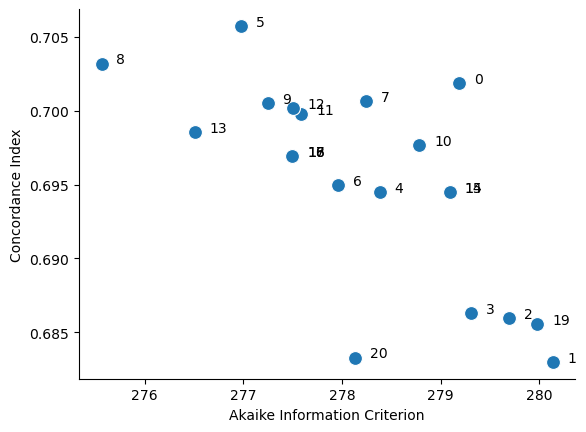

In [82]:
fig, ax = plt.subplots()

sns.scatterplot(data=df_AIC_binarized,
            x='AIC',
            y='CI',
            # hue='Thresh',
              s=100,
              ax=ax
           )

for i, row in df_AIC_binarized.iterrows():
    ax.text(row['AIC'] + 0.15, row['CI'], row['Thresh'])
    
plt.xlabel('Akaike Information Criterion')
plt.ylabel('Concordance Index')
    
sns.despine()
plt.savefig(f"../results/figures/outcomes/binarized_{diversity_var}_longitudinal_AIC_CI.svg", bbox_inches='tight')
# plt.savefig(f"../results/figures/outcomes/thresholded_{diversity_var}_longitudinal_AIC_CI.svg", bbox_inches='tight')
# plt.savefig(f"../results/figures/outcomes/thresholded_{diversity_var}_baseline_AIC_CI.svg", bbox_inches='tight')

In [86]:
diversity_metric = 'NumVar1'
binarize = True
thresh = 8

df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF_baseline[['pid'] + [diversity_metric]])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])
# df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF[['pid'] + [diversity_metric]])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])

if binarize:
    df_add_metric_for_model[diversity_metric] = (df_add_metric_for_model[diversity_metric] > thresh).astype(int)
    model_variables = cols_lst + [diversity_metric]

# if not binarizing, then we're testing where the threshold is that the response is truly dose-dependent. 
# Based on stratified KM curves, it looks like the relationship is not dose-dependent at the low values. Probably because the distribution of the metric is not normal
elif diversity_metric != 'NumVarDiff':
    model_variables = cols_lst.copy()
    
    df_add_metric_for_model[f'{diversity_metric}_leq_{thresh}'] = df_add_metric_for_model[diversity_metric].clip(upper=thresh)
    df_add_metric_for_model[f'{diversity_metric}_above_{thresh}'] = (df_add_metric_for_model[diversity_metric] - thresh).clip(lower=0)
    model_variables += [f'{diversity_metric}_leq_{thresh}', f'{diversity_metric}_above_{thresh}']
    
else:
    # don't binarize because it's an integer, not a natral number
    model_variables = cols_lst + [diversity_metric]

df_test_results_diversity, df_model_processed, cph_model = fit_cox_models_all_imputations(df_add_metric_for_model,
                                                              TRUST_phenos, 
                                                                TRUST_phenos,
                                                              df_tx_outcomes,
                                                           model_variables,
                                                              event_col = 'event',
                                                              time_col = 'date',
                                                                                          MIC_type='none',
                                                           # MIC_type=MIC_type,
                                                             # include_drugs=['RIF'],
                                                             # binarize_drugs=['RIF'],
                                                              tb_deaths_only=True,
                                                              invert_OR=False,
                                                              stratify_variables=stratify_covariates,
                                                                                          non_linear_term_variables=non_linear_term_variables,
                                                                                # knots_tup=(age_spline_lb, age_spline_ub),
                                                                                number_nonlinear_knots=2,
                                                             binary_lineage=True,
                                                                                          PLI_thresh=PLI_thresh
                                                             )

df_model_processed = df_model_processed[0]
cph_model = cph_model[0]

df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_model, df_model_processed, time_transform='rank').summary

# diabetes has a p-value of like 0.0105
df_violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})
print(len(df_violating_covariates.query("p <= 0.05")))

OR_col = 'OR'

cph_model.check_assumptions(df_model_processed)
print(f"    AIC: {cph_model.AIC_partial_}")
print(f"    Concordance Index: {cph_model.concordance_index_}")
print(f"    Log Likelihood: {cph_model.log_likelihood_}")

diversity_metric_LL = cph_model.log_likelihood_

scale_factor = 5
scale_cols = ['screen_years', 'RIF_AUC']
df_test_results_diversity.loc[df_test_results_diversity['covariate'].isin(scale_cols), [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]] = df_test_results_diversity.loc[df_test_results_diversity['covariate'].isin(scale_cols), [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]]**scale_factor

scale_factor = 5
scale_cols = ['predicted_PLI', 'human_PLI']
df_test_results_diversity.loc[df_test_results_diversity['covariate'].isin(scale_cols), [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]] = df_test_results_diversity.loc[df_test_results_diversity['covariate'].isin(scale_cols), [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]]**scale_factor

# scale age
if not binarize:
    # for the unfixed variant burdens
    scale_factor = 5
    df_test_results_diversity.loc[df_test_results_diversity['covariate'].isin([f'{diversity_metric}_above_{thresh}'] + [diversity_metric]), [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]] = df_test_results_diversity.loc[df_test_results_diversity['covariate'].isin([f'{diversity_metric}_above_{thresh}'] + [diversity_metric]), [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]]**scale_factor

print(f"Final: {df_model_processed.pid.nunique()} pids")

    Censored 6 patients with non-TB deaths
    364 total pids
0
Proportional hazard assumption looks okay.
    AIC: 275.5631263250824
    Concordance Index: 0.7031833806605888
    Log Likelihood: -126.78156316254122
Final: 364 pids


In [68]:
def LRT(LL_1, LL_2):
    
    test_stat = np.abs(2 * (LL_1 - LL_2))

    # p-value from the chi-squared distribution
    return 1 - st.chi2.cdf(test_stat, 1)

In [69]:
LRT(diversity_metric_LL, base_model_LL)

0.032513041065505455

In [83]:
# Cox Snell Pseudo R^2.
# There is not a good consensus on how to compute R^2 for survival regression models, so I picked this one
1 - np.exp(2/len(df_model_processed) * (base_model_LL - diversity_metric_LL))

0.012866199306414194

In [71]:
df_test_results_diversity.query("pval <= 0.05").sort_values(['pval'])

,covariate,coef,exp(coef),se(coef),coef_transformed,se_transformed,imp_num,pval,OR,OR_lower,OR_upper
9,HIV_Low_CD4,0.470721,1.601149,0.165258,1.574634,0.552812,1,0.004394,4.828975,1.634184,14.269509
8,NumVar1,0.309825,1.363186,0.129133,1.466327,0.611154,1,0.016428,4.333289,1.307984,14.355979


In [80]:
labels_dict[f'{diversity_metric}_leq_{thresh}'] = f'Unfixed Variants ≤ {thresh}'
labels_dict[f'{diversity_metric}_above_{thresh}'] = f'Unfixed Variants > {thresh}'
labels_dict[diversity_metric] = f"Unfixed Variants > {thresh}"

if binarize:
    forest_plot(df_test_results_diversity,
                [f'{diversity_metric}_leq_{thresh}', f'{diversity_metric}_above_{thresh}', diversity_metric] + list(outcomes_covariates_lst),
                labels_dict, 
                val_col='OR', 
                alpha=0.05, 
                log=True, 
                pval_offset=1.25, 
                df_stratify_variables_results=None, 
                # x_lim=[0.01, 20],
                saveName=f"../results/figures/outcomes/forest_plot_with_diversity_binarized_{thresh}.svg"
               )
else:
    forest_plot(df_test_results_diversity,
                [f'{diversity_metric}_leq_{thresh}', f'{diversity_metric}_above_{thresh}'] + list(outcomes_covariates_lst),
                labels_dict, 
                val_col='OR', 
                alpha=0.05, 
                log=True, 
                pval_offset=1.25, 
                df_stratify_variables_results=None, 
                # x_lim=[0.01, 20],
                 saveName=f"../results/figures/outcomes/forest_plot_with_diversity.svg"
               )

In [89]:
df_Trauner = pd.read_csv("~/MtbLongitudinalDiversity/data/Trauner_et_al_vSNPs.csv", index_col=[0])
df_Trauner['UNIQUE_ID'] = df_Trauner['PATIENT_ID'] + '_' + df_Trauner['TIME'].astype(str)

df_compare = df_Trauner.query("FREQUENCY >= 0.05 & FREQUENCY <= 0.95")

len(df_Trauner), len(df_compare)

(492, 204)

<Axes: xlabel='FREQUENCY', ylabel='Count'>

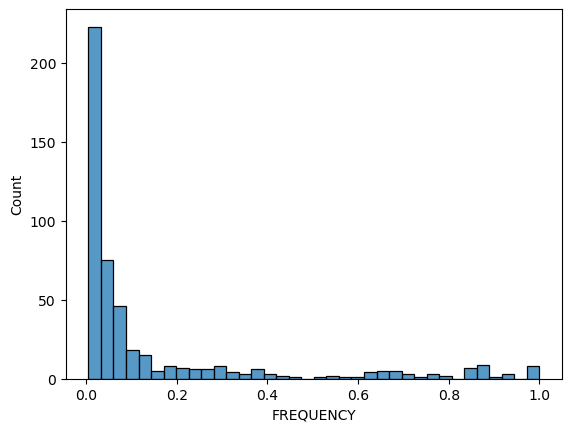

In [90]:
sns.histplot(data=df_Trauner,
             x='FREQUENCY'
            )

<Axes: xlabel='FREQUENCY', ylabel='Count'>

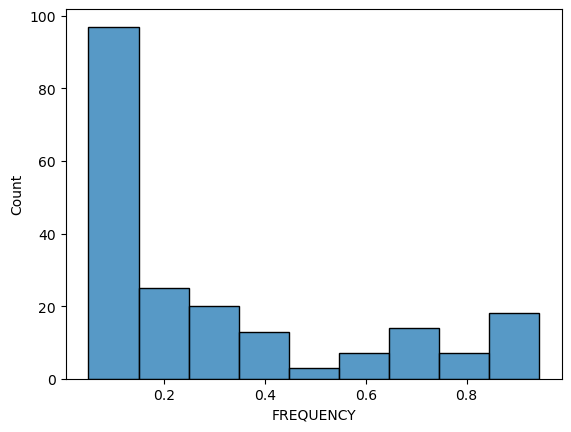

In [91]:
sns.histplot(data=df_compare,
             x='FREQUENCY'
            )

In [92]:
df_compare.PATIENT_ID.nunique()

12

In [93]:
df_compare_summary = pd.DataFrame(df_compare.groupby(['PATIENT_ID', 'TIME', 'UNIQUE_ID', 'RESISTANCE']).FREQUENCY.count()).reset_index()

df_compare_summary = pd.concat([df_compare_summary,
                                pd.DataFrame({'UNIQUE_ID': list(set(df_Trauner.UNIQUE_ID) - set(df_compare_summary.UNIQUE_ID)), 'FREQUENCY': 0})
                               ])

df_compare_summary.FREQUENCY.mean(), df_compare_summary.FREQUENCY.median(), len(df_compare_summary)

(4.25, 3.0, 48)

In [94]:
df_compare_summary.FREQUENCY.min(), df_compare_summary.FREQUENCY.max()

(0, 21)

In [95]:
df_to_compare_to_Trauner = pd.DataFrame(df_lowAF_variants.query("REF.str.len() == ALT.str.len()").groupby('SampleID')['POS'].count()).reset_index()


In [96]:
df_to_compare_to_Trauner.query("POS > 25")

,SampleID,POS


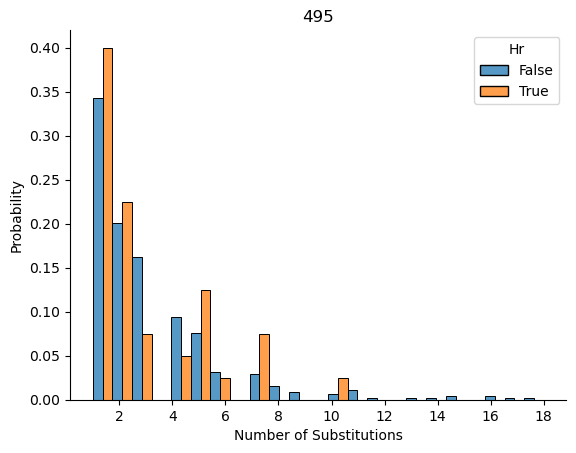

In [97]:
df_to_compare_to_Trauner = pd.DataFrame(df_lowAF_variants_full.query("REF.str.len() == ALT.str.len() & pid in @df_baseline_samples.pid").groupby('SampleID')['POS'].count()).reset_index()

df_to_compare_to_Trauner = df_to_compare_to_Trauner.merge(df_trust_patients[['pid', 'SampleID', 'bl_inh_monoresistant']]).rename(columns={'bl_inh_monoresistant': 'Hr'})

fig, ax = plt.subplots()

sns.histplot(data=df_to_compare_to_Trauner,
             hue='Hr',
             x='POS',
             common_norm=False,
             stat='probability',
             multiple='dodge',
             ax=ax
            )

plt.title(len(df_to_compare_to_Trauner))

from matplotlib.ticker import MaxNLocator
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.xlabel('Number of Substitutions')
sns.despine()
plt.show()

In [98]:
st.mannwhitneyu(df_to_compare_to_Trauner.query("Hr==True")['POS'],
                df_to_compare_to_Trauner.query("Hr==False")['POS'],
               )

MannwhitneyuResult(statistic=8281.0, pvalue=0.5560758178877374)

In [99]:
st.ttest_ind(df_to_compare_to_Trauner.query("Hr==True")['POS'],
                df_to_compare_to_Trauner.query("Hr==False")['POS'],
             equal_var=False
               )

TtestResult(statistic=-0.7103224422142964, pvalue=0.4807899480471346, df=50.21932658032302)

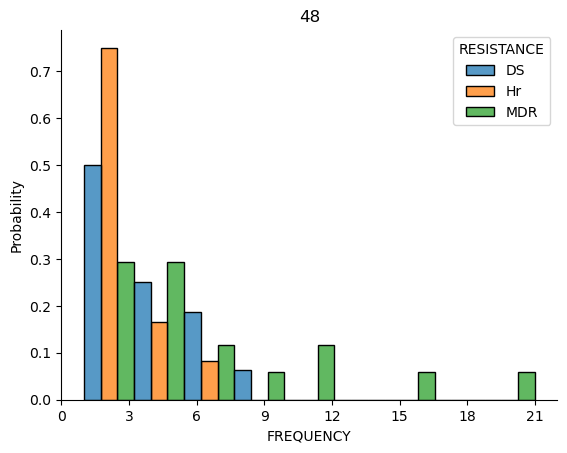

In [100]:
fig, ax = plt.subplots()

sns.histplot(data=df_compare_summary,
             x='FREQUENCY',
             hue='RESISTANCE',
             multiple='dodge',
             stat='probability',
             common_norm=False,
             ax=ax
            )

from matplotlib.ticker import MaxNLocator
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title(len(df_compare_summary))

sns.despine()
plt.show()

In [101]:
st.mannwhitneyu(df_to_compare_to_Trauner['POS'],
             df_compare_summary['FREQUENCY'],
                alternative='two-sided'
            )

MannwhitneyuResult(statistic=9049.0, pvalue=0.005186827558953068)

In [102]:
st.mannwhitneyu(df_to_compare_to_Trauner['POS'],
             df_compare_summary.query("RESISTANCE != 'MDR'")['FREQUENCY'],
            )

MannwhitneyuResult(statistic=7001.5, pvalue=0.40176168811242285)

In [103]:
st.ttest_ind(df_to_compare_to_Trauner['POS'],
             df_compare_summary.query("RESISTANCE != 'MDR'")['FREQUENCY'],
             equal_var=False
            )

TtestResult(statistic=0.06819571268053255, pvalue=0.9459982292214711, df=36.88133778562948)

In [104]:
df_compare_summary.groupby('RESISTANCE').FREQUENCY.mean()

RESISTANCE
DS     3.937500
Hr     2.583333
MDR    6.470588
Name: FREQUENCY, dtype: float64

In [105]:
df_compare_summary.RESISTANCE.value_counts()

RESISTANCE
MDR    17
DS     16
Hr     12
Name: count, dtype: int64

In [106]:
st.mannwhitneyu(df_compare_summary.query("RESISTANCE=='MDR'").FREQUENCY,
                df_compare_summary.query("RESISTANCE!='MDR'").FREQUENCY,
                alternative='greater'
               )

MannwhitneyuResult(statistic=387.5, pvalue=0.0035357701424450806)

In [107]:
st.ttest_ind(df_compare_summary['FREQUENCY'],
                df_to_compare_to_Trauner['POS'],
                alternative='greater',
             equal_var=False
               )

TtestResult(statistic=2.0829358222211245, pvalue=0.021119833962865084, df=51.50557154500347)

In [108]:
df_lowAF_variants_full.query("GENE.str.contains('Rv1830')")[['pid', 'SampleID', 'POS', 'AF']]

,pid,SampleID,POS,AF
114,T0235,MFS-144,2075037,0.095436
376,T0278,MFS-296,2075178,0.100000
665,T0341,MFS-416,2075106,0.266160
858,T0054,MFS-542,2075516,0.324910
865,T0054,MFS-543,2075516,0.755725
947,T0116,MFS-578,2075129,0.788136
1057,T0187,MFS-626,2075518,0.422111
1107,T0296,MFS-655,2075518,0.137255
1517,T0470,MFS-858,2075516,0.131034


In [109]:
st.spearmanr(df_LAF['NumVar1'], df_LAF['NumVar2'])

SignificanceResult(statistic=0.42140200462090527, pvalue=1.183450824845451e-13)

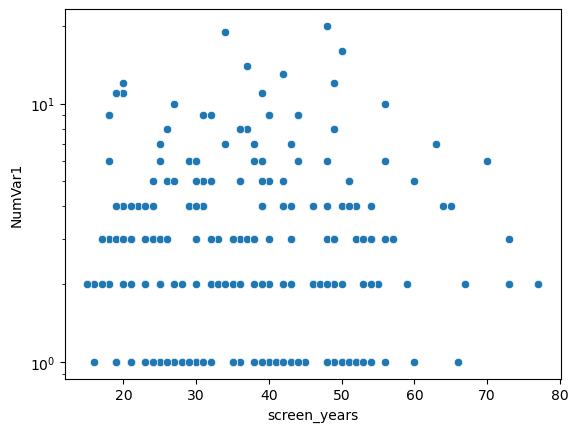

In [110]:
sns.scatterplot(data=df_pids_for_outcomes_model.merge(df_LAF_baseline[['pid', 'NumVar1']]).dropna(subset=['screen_years', 'NumVar1']),
                x='screen_years',
                y='NumVar1'
               )

plt.yscale('log')

In [111]:
df_model_processed['NumVar1'].unique()

array([-0.22133991,  4.5179381 ])

In [112]:
df_model_processed[['pid', 'NumVar1']].merge(df_pids_for_outcomes_model).groupby('NumVar1').screen_years.mean()

NumVar1
-0.221340    37.247839
 4.517938    35.647059
Name: screen_years, dtype: float64

In [113]:
st.mannwhitneyu(df_model_processed[['pid', 'NumVar1']].merge(df_pids_for_outcomes_model).query("NumVar1 < 0").screen_years,
             df_model_processed[['pid', 'NumVar1']].merge(df_pids_for_outcomes_model).query("NumVar1 > 0").screen_years,
             alternative='less'
            )

MannwhitneyuResult(statistic=3126.5, pvalue=0.6624614140574139)

In [ ]:
# scaler = StandardScaler()

# diversity_metric = 'NumVar1'
# raw_values = df_add_metric_for_model.query("pid in @df_model_processed.pid")[diversity_metric].values

# raw_mean = raw_values.mean()
# raw_sd = raw_values.std()

# scaled_values = (raw_values - raw_mean) / raw_sd

# def unscale_val(scaled_val, raw_mean, raw_sd):
#     # it should be an integer, so return it as such. If it's not, it's a float precision problem
#     return int(scaled_val * raw_sd + raw_mean)

# # percentiles_lst = [25, 50, 75, 87.5, 100]

# # if binarize:
# #     test_vals = df_model_processed[diversity_metric].unique()
# # else:
# #     test_vals = np.percentile(scaled_values, percentiles_lst)
    
# # percentile_dict = dict(zip(test_vals, percentiles_lst))

# test_vals = np.linspace(1, df_add_metric_for_model.NumVar1.max(), int(df_add_metric_for_model.NumVar1.max() / 2))
# test_vals = (test_vals - raw_mean) / raw_sd

# ax = cph_model.plot_partial_effects_on_outcome(covariates=diversity_metric, values=test_vals, plot_baseline=False, cmap='coolwarm')

# # Update legend labels
# handles, labels = ax.get_legend_handles_labels()
# # ax.legend(handles, [f"{perc}th perc. = {str(unscale_val(val, raw_mean, raw_sd))}" for val, perc in percentile_dict.items()])
# ax.legend(handles, [f"{str(unscale_val(val, raw_mean, raw_sd))}" for val in test_vals])
# ax.set_xlabel('Days since Treatment Start')

# sns.despine()
# # plt.savefig("../results/figures/outcomes/NumVar1_varying_hazard.svg", bbox_inches='tight')

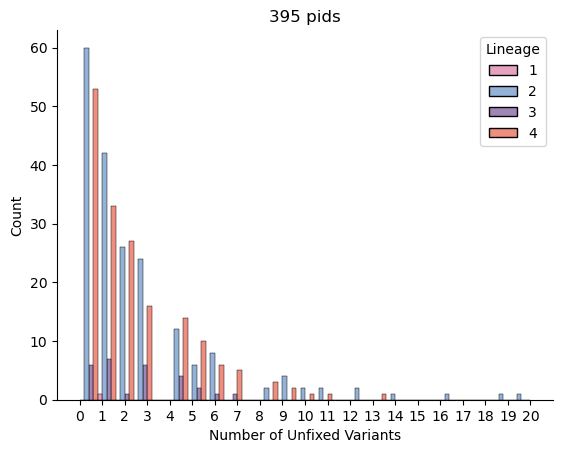

In [114]:
df_LAF_baseline['Lineage'] = df_LAF_baseline['Lineage'].astype(float).astype(int).astype(str)

fig, ax = plt.subplots()

plot_var = 'NumVar1'

LinToColor_Dict = {"1": "#DF83AC",
                   "2": "#7098CB",
                   "3": "#815D9F",
                   "4": "#E76956",
                   # "Other": "white"
                   # "5": "#B67548",
                   # "6": "#6AB79E",
                   # "8": "#E4515B",
                   # "M.bovis": "white",
                  }

    
sns.histplot(df_LAF_baseline,
             x=plot_var,
             hue='Lineage',
             multiple='dodge',
             # bins=range(int(df_add_metric_for_model[diversity_metric].min()), int(df_add_metric_for_model[diversity_metric].max()) + 2),
             hue_order=['1', '2', '3', '4'],
             palette=LinToColor_Dict,
             ax=ax
            )

# Force integer x-axis ticks
plt.xticks(
    np.arange(
        int(df_LAF_baseline[plot_var].min()),
        int(df_LAF_baseline[plot_var].max()) + 1
    )
)
plt.title(f"{df_LAF_baseline.pid.nunique()} pids")
plt.xlabel('Number of Unfixed Variants')

sns.despine()

plt.savefig(f"../results/figures/{plot_var}.svg", bbox_inches='tight')

In [118]:
# df_combined_counts = df_LAF_baseline.query("pid in @df_model_processed.pid")[['pid', 'Lineage', 'NumVar1']]
df_combined_counts = df_LAF_baseline[['pid', 'Lineage', 'NumVar1']]
df_combined_counts['Lineage'] = df_combined_counts['Lineage'].astype(int).astype(str)

lambda_params_dict = exponential_LRT(df_combined_counts, 'NumVar1', min_count=5)

print(f"Min: {df_combined_counts.NumVar1.min()}")
print(f"Median: {df_combined_counts.NumVar1.median()}")
print(f"Mean: {df_combined_counts.NumVar1.mean()}")
print(f"Max: {df_combined_counts.NumVar1.max()}")

λ for Lineage = 2: 0.40501043841336115
λ for Lineage = 3: 0.42424242424242425
λ for Lineage = 4: 0.44329896907216493
λ for full = 0.42229367631296894

Likelihood ratio test statistic: 0.743
P-value: 0.6897
Min: 0
Median: 1.0
Mean: 2.3645569620253166
Max: 20


In [119]:
df_LAF_baseline.NumVar1.sum()

934

In [130]:
df_LAF_baseline.query("NumVar1 != NumIndels + NumSNVs")

,pid,SE1,SASE1,NumVar1,Coll2014,Freschi2020,Lineage,F2,s_ttp_sputum_specimen_1,NumIndels,NumSNVs,NumPhaseVariants


In [131]:
def bin_by_min_count(values, min_count):
    """
    Group sorted values into bins with at least `min_count` elements.
    
    Parameters
    ----------
    values : array-like
        The input values.
    min_count : int
        Minimum number of elements per bin.
        
    Returns
    -------
    bins : list of arrays
        A list of arrays, each containing the values in that bin.
    edges : list of tuples
        (min, max) range for each bin.
    """
    values = np.sort(values)
    n = len(values)
    
    # Determine split indices
    splits = np.arange(min_count, n, min_count)
    bins = np.split(values, splits)
    
    # Merge last bin if it's too small
    if len(bins[-1]) < min_count and len(bins) > 1:
        bins[-2] = np.concatenate([bins[-2], bins[-1]])
        bins = bins[:-1]
    
    edges = [(b[0], b[-1]) for b in bins]
    return bins, edges

<Axes: xlabel='screen_years', ylabel='Proportion'>

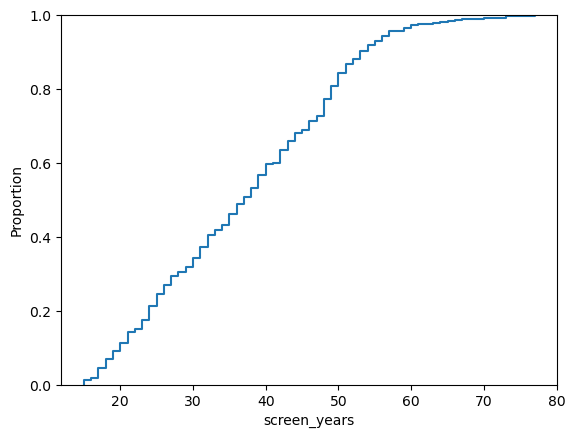

In [132]:
sns.ecdfplot(data=df_KM_plot,
             x='screen_years'
            )

98
87
96
83
Balanced: p = 0.0711
Early: p = 0.078
Late: p = 0.022


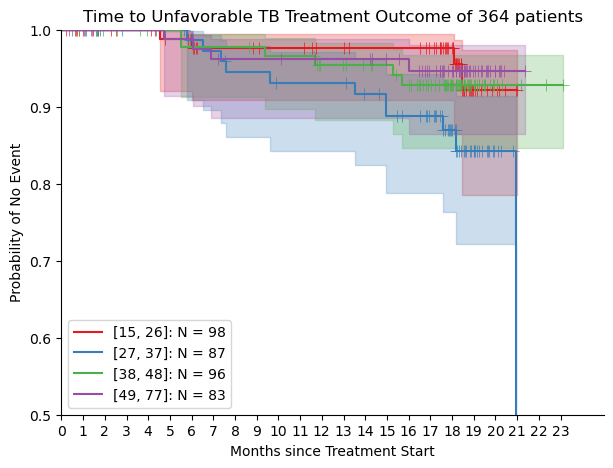

In [134]:
df_KM_plot = df_add_metric_for_model.query("pid in @df_model_processed.pid").merge(df_tx_outcomes[['pid', 'event_type', 'TB_death', 'date', 'event', 'weeks', 'months']])

df_KM_plot['screen_years'] = df_KM_plot['screen_years'].astype(int)

df_KM_plot["var_group"] = pd.qcut(
    df_KM_plot["screen_years"],
    q=[0, 0.25, 0.50, 0.75, 1.0],       # quantile cutpoints
    labels=["Q1", "Q2", "Q3", "Q4"]     # group names
)

# percentiles = [0, 25, 50, 75]

# # for i, perc in enumerate(percentiles):
#     # perc_value = np.percentile(df_KM_plot['NumVar1'], perc)
#     # print(perc, perc_value)
# for i, perc_value in enumerate([0, 1, 3, 4]):
#     df_KM_plot.loc[df_KM_plot['NumVar1'] >= perc_value, "var_group"] = f"Q{i+1}"
    
# it's the binarized one here, not raw values
del df_KM_plot[diversity_metric]

fig, ax = plt.subplots(figsize=(7, 5))

max_val = int(np.ceil(df_KM_plot.months.max()))

kmf = lifelines.KaplanMeierFitter()

# stratify_col = f'{diversity_metric}_Binary'
# df_KM_plot[stratify_col] = (df_KM_plot[diversity_metric] > thresh).astype(int)
# label_dict = {0: f'# Low-AF Sites ≤ {thresh}', 1: f'# Low-AF Sites > {thresh}'}
# color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))

stratify_col = 'var_group'

label_dict = {
    "Q1": r"$25^{\mathrm{th}}$",
    "Q2": r"$50^{\mathrm{th}}$",
    "Q3": r"$75^{\mathrm{th}}$",
    "Q4": r"$100^{\mathrm{th}}$"
}

value_dict = {var: [df_KM_plot.query(f"var_group==@var").screen_years.min(), df_KM_plot.query(f"var_group==@var").screen_years.max()] for var in label_dict.keys()}

color_dict = dict(zip(list(label_dict.keys()), sns.color_palette('Set1', n_colors=len(label_dict)).as_hex()))

kmf_tables = []

if tb_deaths_only:
    df_KM_plot.loc[df_KM_plot['TB_death']==0, 'event'] = 0

for group in np.sort(df_KM_plot[stratify_col].unique()):
    
    df_single_group = df_KM_plot.query(f"{stratify_col}==@group")
    print(len(df_single_group))
    group_name = label_dict[group]

    kmf.fit(df_single_group['months'], event_observed=df_single_group['event'],)# label=group_name)
    
    kmf.plot_survival_function(ax=ax, 
                               show_censors=True, 
                               color=color_dict[group], 
                               censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, 
                               # label=f"# Sites ≥ {int(group)} = {len(df_single_group)}",
                               # label=f"{group_name} = [{int(value_dict[group][0])}, {int(value_dict[group][1])}]: (N = {len(df_single_group)})"
                               label=f"[{int(value_dict[group][0])}, {int(value_dict[group][1])}]: N = {len(df_single_group)}"
                              )
    
    # Original event table (indexed by actual event/censor times)
    event_table = kmf.event_table

    # Define integer time points of interest
    integer_times = np.arange(0, max_val + 1)

    # Reindex to integer times
    event_table_int = (
        event_table.reindex(integer_times, method="ffill").fillna(method="bfill")
    )

    # Now you can extract at-risk and censored at integer times
    at_risk_int = event_table_int["at_risk"]
    censored_int = event_table_int["censored"]

    every_other_month = np.linspace(0, max_val, 13)
    
    # event_table_int['Group'] = group_name
    # kmf_tables.append(event_table_int[['Group', 'at_risk', 'censored']].loc[every_other_month])
    
# kmf_tables = pd.concat(kmf_tables, axis=1)

plt.title(f"Time to Unfavorable TB Treatment Outcome of {df_KM_plot.pid.nunique()} patients")
plt.ylabel("Probability of No Event") #
plt.xlabel("Months since Treatment Start")

plt.xlim(0, max_val + 1)
plt.ylim(0.5, 1)

logRank_balanced_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=0, weightings="fleming-harrington").p_value
logRank_early_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=1, q=0, weightings="fleming-harrington").p_value
logRank_late_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=1, weightings="fleming-harrington").p_value

print(f"Balanced: p = {np.round(logRank_balanced_pval, 4)}")
print(f"Early: p = {np.round(logRank_early_pval, 4)}")
print(f"Late: p = {np.round(logRank_late_pval, 4)}")

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, int(df_KM_plot['months'].max()) + 1))

# plt.legend(title='Percentiles')

sns.despine()
# plt.savefig(f"../results/figures/outcomes/KM_estimate_binarized_{thresh}.svg", bbox_inches='tight')
# plt.savefig(f"../results/figures/outcomes/KM_estimate_percentiles.svg", bbox_inches='tight')
# plt.savefig(f"../results/figures/outcomes/KM_estimate_percentiles_for_defense.svg", bbox_inches='tight')

In [ ]:
sns.histplot(data=df_model_processed[['pid', 'screen_years']].rename(columns={'screen_years': 'screen_years_scaled'}).merge(df_KM_plot),#[['pid', 'screen_years', 'screen_years_scaled']],
             x='screen_years',#_scaled',
             hue='var_group',
             multiple='dodge'
            )

In [ ]:
df_KM_plot.query("var_group=='Q4'").screen_years.min()

In [ ]:
df_model_processed[['pid', 'screen_years']].rename(columns={'screen_years': 'screen_years_scaled'}).merge(df_KM_plot).groupby('var_group')['screen_years_scaled'].agg(['min', 'max'])

In [ ]:
df_KM_plot.var_group.value_counts()

347
17
Balanced: p = 0.0046
Early: p = 0.0054
Late: p = 0.0003


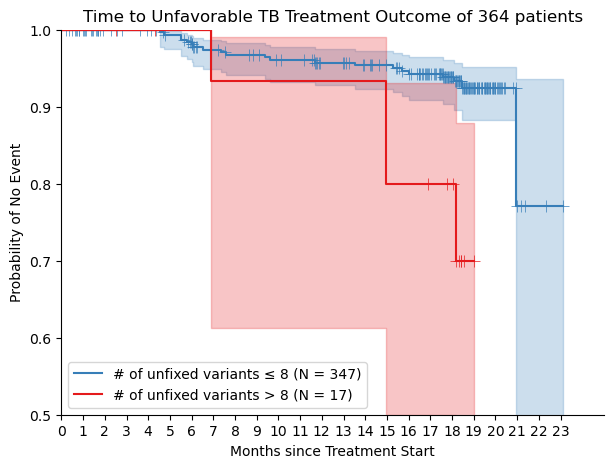

In [88]:
df_KM_plot = df_add_metric_for_model.query("pid in @df_model_processed.pid").merge(df_tx_outcomes[['pid', 'event_type', 'TB_death', 'date', 'event', 'weeks', 'months']])

thresh = 8

# get raw values
if 'NumVar1' in df_KM_plot.columns:
    del df_KM_plot['NumVar1']

df_KM_plot = df_KM_plot.merge(df_LAF_baseline[['pid', 'NumVar1']])

df_KM_plot['NumVar1'] = df_KM_plot['NumVar1'].astype(int)
df_KM_plot['var_group'] = (df_KM_plot['NumVar1'] > thresh).astype(int)

fig, ax = plt.subplots(figsize=(7, 5))

max_val = int(np.ceil(df_KM_plot.months.max()))

kmf = lifelines.KaplanMeierFitter()

# stratify_col = f'{diversity_metric}_Binary'
# df_KM_plot[stratify_col] = (df_KM_plot[diversity_metric] > thresh).astype(int)
# label_dict = {0: f'# Low-AF Sites ≤ {thresh}', 1: f'# Low-AF Sites > {thresh}'}
# color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))

stratify_col = 'var_group'

color_dict = {0: sns.color_palette('Set1').as_hex()[1], 1: sns.color_palette('Set1').as_hex()[0]}
label_dict = {0: f"≤ {thresh}", 1: f"> {thresh}"}

kmf_tables = []

if tb_deaths_only:
    df_KM_plot.loc[df_KM_plot['TB_death']==0, 'event'] = 0

for group in np.sort(df_KM_plot[stratify_col].unique()):
    
    df_single_group = df_KM_plot.query(f"{stratify_col}==@group")
    print(len(df_single_group))

    kmf.fit(df_single_group['months'], event_observed=df_single_group['event'])
    
    kmf.plot_survival_function(ax=ax, 
                               show_censors=True, 
                               color=color_dict[group], 
                               censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, 
                               label=f"# of unfixed variants {label_dict[group]} (N = {len(df_single_group)})",
                              )

plt.title(f"Time to Unfavorable TB Treatment Outcome of {df_KM_plot.pid.nunique()} patients")
plt.ylabel("Probability of No Event") #
plt.xlabel("Months since Treatment Start")

plt.xlim(0, max_val + 1)
plt.ylim(0.5, 1)

logRank_balanced_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=0, weightings="fleming-harrington").p_value
logRank_early_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=1, q=0, weightings="fleming-harrington").p_value
logRank_late_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=1, weightings="fleming-harrington").p_value

print(f"Balanced: p = {np.round(logRank_balanced_pval, 4)}")
print(f"Early: p = {np.round(logRank_early_pval, 4)}")
print(f"Late: p = {np.round(logRank_late_pval, 4)}")

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, int(df_KM_plot['months'].max()) + 1))

# plt.legend(title='Percentiles')

sns.despine()
plt.savefig(f"../results/figures/outcomes/KM_estimate_binarized_{thresh}.svg", bbox_inches='tight')

In [135]:
max_time = 12

df_KM_plot.loc[df_KM_plot['months'] > max_time, 'event'] = 0

lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=0, weightings="fleming-harrington").p_value

0.6346955663230442

In [136]:
lifelines.statistics.multivariate_logrank_test(df_KM_plot.query("months <= 12")['date'], 
                                               df_KM_plot.query("months <= 12")[stratify_col], 
                                               df_KM_plot.query("months <= 12")['event'], 
                                               p=0, q=0, weightings="fleming-harrington").p_value

0.4916983329548126

In [138]:
df_KM_plot.groupby('var_group').event.agg(['sum', 'mean'])

,sum,mean
var_group,,
Q1,2,0.020408
Q2,5,0.057471
Q3,4,0.041667
Q4,3,0.036145


In [139]:
df_KM_plot.query("var_group==1")[['event', 'event_type']].query("event_type != 'cure'")

,event,event_type


189
175
Balanced: p = 0.7951
Early: p = 0.8099
Late: p = 0.5354


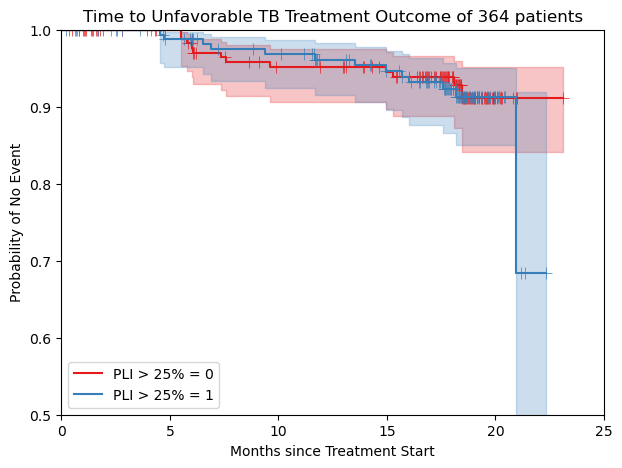

In [143]:
df_KM_plot = df_add_metric_for_model.query("pid in @df_model_processed.pid").merge(df_tx_outcomes[['pid', 'event_type', 'TB_death', 'date', 'event', 'weeks', 'months']])
df_KM_plot['human_high_lung_involvement'] = (df_KM_plot['human_PLI'] > PLI_thresh).astype(int)

fig, ax = plt.subplots(figsize=(7, 5))

max_val = int(np.ceil(df_KM_plot.months.max()))

kmf = lifelines.KaplanMeierFitter()

# stratify_col = f'{diversity_metric}_Binary'
# df_KM_plot[stratify_col] = (df_KM_plot[diversity_metric] > thresh).astype(int)
# label_dict = {0: f'# Low-AF Sites ≤ {thresh}', 1: f'# Low-AF Sites > {thresh}'}
# color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))

stratify_col = 'human_high_lung_involvement'

color_dict = dict(zip([0, 1], sns.color_palette('Set1', n_colors=2).as_hex()))

kmf_tables = []

if tb_deaths_only:
    df_KM_plot.loc[df_KM_plot['TB_death']==0, 'event'] = 0

for group in np.sort(df_KM_plot[stratify_col].unique()):
    
    df_single_group = df_KM_plot.query(f"{stratify_col}==@group")
    print(len(df_single_group))

    kmf.fit(df_single_group['months'], event_observed=df_single_group['event'],)# label=group_name)
    
    kmf.plot_survival_function(ax=ax, 
                               show_censors=True, 
                               color=color_dict[group], 
                               censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, 
                               label=f"PLI > {PLI_thresh}% = {group}"
                               # label=f"# Sites ≥ {int(group)} = {len(df_single_group)}",
                               # label=f"{group_name} = [{int(value_dict[group][0])}, {int(value_dict[group][1])}]: (N = {len(df_single_group)})"
                               # label=f"[{int(value_dict[group][0])}, {int(value_dict[group][1])}]: N = {len(df_single_group)}"
                              )
    
    # Original event table (indexed by actual event/censor times)
    event_table = kmf.event_table

    # Define integer time points of interest
    integer_times = np.arange(0, max_val + 1)

    # Reindex to integer times
    event_table_int = (
        event_table.reindex(integer_times, method="ffill").fillna(method="bfill")
    )

    # Now you can extract at-risk and censored at integer times
    at_risk_int = event_table_int["at_risk"]
    censored_int = event_table_int["censored"]

    every_other_month = np.linspace(0, max_val, 13)
    
    # event_table_int['Group'] = group_name
    # kmf_tables.append(event_table_int[['Group', 'at_risk', 'censored']].loc[every_other_month])
    
# kmf_tables = pd.concat(kmf_tables, axis=1)

plt.title(f"Time to Unfavorable TB Treatment Outcome of {df_KM_plot.pid.nunique()} patients")
plt.ylabel("Probability of No Event") #
plt.xlabel("Months since Treatment Start")

plt.xlim(0, max_val + 1)
plt.ylim(0.5, 1)

logRank_balanced_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=0, weightings="fleming-harrington").p_value
logRank_early_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=1, q=0, weightings="fleming-harrington").p_value
logRank_late_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=1, weightings="fleming-harrington").p_value

print(f"Balanced: p = {np.round(logRank_balanced_pval, 4)}")
print(f"Early: p = {np.round(logRank_early_pval, 4)}")
print(f"Late: p = {np.round(logRank_late_pval, 4)}")

# # Set x-axis ticks to show all integers
# ax.set_xticks(range(0, int(df_KM_plot['months'].max()) + 1))

# # plt.legend(title='Percentiles')

# sns.despine()
# # plt.savefig(f"../results/figures/outcomes/KM_estimate_binarized_{thresh}.svg", bbox_inches='tight')
# plt.savefig(f"../results/figures/outcomes/KM_estimate_percentiles.svg", bbox_inches='tight')
# # plt.savefig(f"../results/figures/outcomes/KM_estimate_percentiles_for_defense.svg", bbox_inches='tight')

189
31
38
33
36
37
Balanced: p = 0.0589
Early: p = 0.0561
Late: p = 0.3097


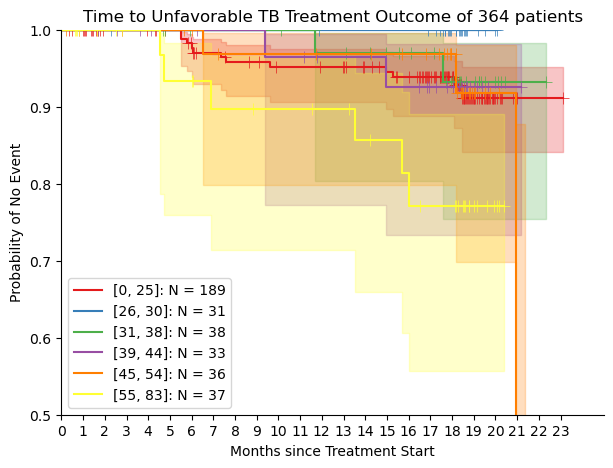

In [145]:
df_KM_plot = df_add_metric_for_model.query("pid in @df_model_processed.pid").merge(df_tx_outcomes[['pid', 'event_type', 'TB_death', 'date', 'event', 'weeks', 'months']])

df_KM_plot['human_PLI'] = df_KM_plot['human_PLI'].astype(int)

quantiles_lst = [0, 0.50, 0.6, 0.7, 0.8, 0.9, 1.0]
labels_lst = [f"Q{num}" for num in np.arange(len(quantiles_lst)-1)]

df_KM_plot["var_group"] = pd.qcut(
    df_KM_plot["human_PLI"],
    q=quantiles_lst,       # quantile cutpoints
    labels=labels_lst     # group names
)

# percentiles = [0, 25, 50, 75]

# # for i, perc in enumerate(percentiles):
#     # perc_value = np.percentile(df_KM_plot['NumVar1'], perc)
#     # print(perc, perc_value)
# for i, perc_value in enumerate([0, 1, 3, 4]):
#     df_KM_plot.loc[df_KM_plot['NumVar1'] >= perc_value, "var_group"] = f"Q{i+1}"
    
# it's the binarized one here, not raw values
del df_KM_plot[diversity_metric]

# get raw values
fig, ax = plt.subplots(figsize=(7, 5))

max_val = int(np.ceil(df_KM_plot.months.max()))

kmf = lifelines.KaplanMeierFitter()

# stratify_col = f'{diversity_metric}_Binary'
# df_KM_plot[stratify_col] = (df_KM_plot[diversity_metric] > thresh).astype(int)
# label_dict = {0: f'# Low-AF Sites ≤ {thresh}', 1: f'# Low-AF Sites > {thresh}'}
# color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))

stratify_col = 'var_group'

# label_dict = {
#     "Q1": r"$25^{\mathrm{th}}$",
#     "Q2": r"$50^{\mathrm{th}}$",
#     "Q3": r"$75^{\mathrm{th}}$",
#     "Q4": r"$100^{\mathrm{th}}$"
# }

label_dict = dict(zip(labels_lst, labels_lst))

value_dict = {var: [df_KM_plot.query(f"var_group==@var")['human_PLI'].min(), df_KM_plot.query(f"var_group==@var")['human_PLI'].max()] for var in label_dict.keys()}

color_dict = dict(zip(list(label_dict.keys()), sns.color_palette('Set1', n_colors=len(label_dict)).as_hex()))

kmf_tables = []

if tb_deaths_only:
    df_KM_plot.loc[df_KM_plot['TB_death']==0, 'event'] = 0

for group in np.sort(df_KM_plot[stratify_col].unique()):
    
    df_single_group = df_KM_plot.query(f"{stratify_col}==@group")
    print(len(df_single_group))
    group_name = label_dict[group]

    kmf.fit(df_single_group['months'], event_observed=df_single_group['event'],)# label=group_name)
    
    kmf.plot_survival_function(ax=ax, 
                               show_censors=True, 
                               color=color_dict[group], 
                               censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, 
                               # label=f"# Sites ≥ {int(group)} = {len(df_single_group)}",
                               # label=f"{group_name} = [{int(value_dict[group][0])}, {int(value_dict[group][1])}]: (N = {len(df_single_group)})"
                               label=f"[{int(value_dict[group][0])}, {int(value_dict[group][1])}]: N = {len(df_single_group)}"
                              )
    
    # Original event table (indexed by actual event/censor times)
    event_table = kmf.event_table

    # Define integer time points of interest
    integer_times = np.arange(0, max_val + 1)

    # Reindex to integer times
    event_table_int = (
        event_table.reindex(integer_times, method="ffill").fillna(method="bfill")
    )

    # Now you can extract at-risk and censored at integer times
    at_risk_int = event_table_int["at_risk"]
    censored_int = event_table_int["censored"]

    every_other_month = np.linspace(0, max_val, 13)
    
    # event_table_int['Group'] = group_name
    # kmf_tables.append(event_table_int[['Group', 'at_risk', 'censored']].loc[every_other_month])
    
# kmf_tables = pd.concat(kmf_tables, axis=1)

plt.title(f"Time to Unfavorable TB Treatment Outcome of {df_KM_plot.pid.nunique()} patients")
plt.ylabel("Probability of No Event") #
plt.xlabel("Months since Treatment Start")

plt.xlim(0, max_val + 1)
plt.ylim(0.5, 1)

logRank_balanced_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=0, weightings="fleming-harrington").p_value
logRank_early_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=1, q=0, weightings="fleming-harrington").p_value
logRank_late_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=1, weightings="fleming-harrington").p_value

print(f"Balanced: p = {np.round(logRank_balanced_pval, 4)}")
print(f"Early: p = {np.round(logRank_early_pval, 4)}")
print(f"Late: p = {np.round(logRank_late_pval, 4)}")

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, int(df_KM_plot['months'].max()) + 1))

# plt.legend(title='Percentiles')

sns.despine()
# plt.savefig(f"../results/figures/outcomes/KM_estimate_binarized_{thresh}.svg", bbox_inches='tight')
# plt.savefig(f"../results/figures/outcomes/KM_estimate_percentiles.svg", bbox_inches='tight')
# plt.savefig(f"../results/figures/outcomes/KM_estimate_percentiles_for_defense.svg", bbox_inches='tight')